# RUNTIME RESTORATION

In [ ]:
# ============================================================
# ROBUST DEEP FEATURE EXTRACTION
# ORIGINAL vs. SEGMENTED
#
# MobileNetV2 final feature dimension: 1280
#
# Splits processed:
#   train       = 1180
#   hpo         = 168
#   locked test = 168
#
# The locked test is ONLY transformed and saved.
# It is NOT used for model selection or HPO.
#
# Changes vs. previous version:
# - GPU memory growth enabled before model loading
# - No tf.py_function / AUTOTUNE / tf.data prefetch
# - PIL + NumPy batched loading
# - Small inference batches
# - Automatic CPU fallback for CUDA runtime errors
# - Existing valid branch feature matrices are reused
# ============================================================

from google.colab import drive
drive.mount(
    "/content/drive"
)

# ============================================================
# IMPORTS
# ============================================================

import os
import gc
import json
import random

import numpy as np
import pandas as pd
import tensorflow as tf

from PIL import Image, ImageOps
from IPython.display import display

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input
)


# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

RANDOM_STATE = 42

IMG_SIZE = (
    224,
    224
)

# More conservative than 32 for Colab inference.
BATCH_SIZE = 16

FEATURE_DIMENSION = 1280

random.seed(
    RANDOM_STATE
)

np.random.seed(
    RANDOM_STATE
)

tf.random.set_seed(
    RANDOM_STATE
)

# ------------------------------------------------------------
# GPU configuration
#
# IMPORTANT:
# This must run BEFORE loading the Keras extractors.
# ------------------------------------------------------------

gpus = tf.config.list_physical_devices(
    "GPU"
)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(
            gpu,
            True
        )
    except RuntimeError as exc:
        # This can happen if the GPU has already been initialized.
        print(
            "[WARN] Could not enable memory growth:",
            exc
        )

# Disable XLA/JIT for this extraction stage.
# It is unnecessary for 1516 images and removes another
# possible source of CUDA-kernel instability.
try:
    tf.config.optimizer.set_jit(
        False
    )
except Exception:
    pass

print("=" * 80)
print("ROBUST DEEP FEATURE EXTRACTION")
print("=" * 80)

print(
    "TensorFlow version :",
    tf.__version__
)

print(
    "GPU available      :",
    bool(
        gpus
    )
)

if gpus:
    print(
        "GPU device         :",
        gpus[0]
    )


# ============================================================
# PROJECT PATHS
# ============================================================

dataset = (
    "/content/drive/MyDrive/"
    "Articulo_DiegoR/Dataset Cacao"
)

ejecucion = (
    "/content/drive/MyDrive/"
    "Articulo_DiegoR/articulo"
)

splits_directory = os.path.join(
    ejecucion,
    "dataset_splits"
)

segmentation_manifest_path = os.path.join(
    splits_directory,
    "segmentation_manifest.csv"
)

models_directory = os.path.join(
    ejecucion,
    "models",
    "feature_extractors"
)

features_directory = os.path.join(
    ejecucion,
    "features"
)

os.makedirs(
    features_directory,
    exist_ok=True
)


# ============================================================
# FINAL EXTRACTOR PATHS
# ============================================================

original_extractor_path = os.path.join(
    models_directory,
    "mobilenetv2_original_final_extractor.keras"
)

segmented_extractor_path = os.path.join(
    models_directory,
    "mobilenetv2_segmented_final_extractor.keras"
)

assert os.path.isfile(
    original_extractor_path
), (
    "Original final extractor was not found."
)

assert os.path.isfile(
    segmented_extractor_path
), (
    "Segmented final extractor was not found."
)

assert os.path.isfile(
    segmentation_manifest_path
), (
    "Segmentation manifest was not found."
)

print(
    "\n[OK] Final extractors found."
)


# ============================================================
# LOAD EXPERIMENT MANIFEST
# ============================================================

experiment_df = pd.read_csv(
    segmentation_manifest_path
)

assert len(
    experiment_df
) == 1684


# ============================================================
# SELECT ONLY TRAIN + HPO + LOCKED TEST
#
# Fine-tuning images are deliberately excluded.
# ============================================================

feature_df = experiment_df[
    (
        experiment_df[
            "split"
        ].isin(
            [
                "train",
                "hpo",
                "test",
            ]
        )
    )
    &
    (
        experiment_df[
            "status"
        ]
        ==
        "success"
    )
].copy()

assert len(
    feature_df
) == 1516, (
    f"Expected 1516 images, "
    f"found {len(feature_df)}."
)


# ============================================================
# CREATE DETERMINISTIC SAMPLE ORDER
# ============================================================

split_order = pd.CategoricalDtype(
    categories=[
        "train",
        "hpo",
        "test",
    ],
    ordered=True
)

feature_df[
    "split"
] = (
    feature_df[
        "split"
    ]
    .astype(
        split_order
    )
)

feature_df = (
    feature_df
    .sort_values(
        by=[
            "split",
            "label",
            "filename",
        ],
        kind="mergesort"
    )
    .reset_index(
        drop=True
    )
)

feature_df[
    "feature_row"
] = np.arange(
    len(
        feature_df
    )
)


# ============================================================
# VERIFY SPLITS
# ============================================================

split_summary = (
    feature_df
    .groupby(
        [
            "split",
            "class_name",
        ],
        observed=False
    )
    .size()
    .unstack(
        fill_value=0
    )
)

split_summary[
    "Total"
] = split_summary.sum(
    axis=1
)

print(
    "\nDataset used for feature extraction:"
)

display(
    split_summary
)

assert (
    feature_df[
        feature_df[
            "split"
        ]
        ==
        "train"
    ].shape[0]
    ==
    1180
)

assert (
    feature_df[
        feature_df[
            "split"
        ]
        ==
        "hpo"
    ].shape[0]
    ==
    168
)

assert (
    feature_df[
        feature_df[
            "split"
        ]
        ==
        "test"
    ].shape[0]
    ==
    168
)

print(
    "\n[OK] Feature extraction cohort verified."
)


# ============================================================
# SAVE FEATURE MANIFEST
# ============================================================

feature_manifest_path = os.path.join(
    features_directory,
    "feature_manifest.csv"
)

feature_df.to_csv(
    feature_manifest_path,
    index=False
)

print(
    "\n[OK] Feature manifest saved:"
)

print(
    feature_manifest_path
)


# ============================================================
# IMAGE LOADING
#
# Pure PIL/NumPy loading.
# No tf.py_function is used.
# ============================================================

def load_rgb_numpy(
    path
):
    with Image.open(
        path
    ) as img:
        img = (
            ImageOps
            .exif_transpose(
                img
            )
        )

        img = img.convert(
            "RGB"
        )

        img = img.resize(
            IMG_SIZE,
            Image.Resampling.LANCZOS
        )

        image_array = np.asarray(
            img,
            dtype=np.float32
        )

    return image_array


def load_preprocessed_batch(
    batch_paths
):
    batch = np.stack(
        [
            load_rgb_numpy(
                path
            )
            for path in batch_paths
        ],
        axis=0
    ).astype(
        np.float32,
        copy=False
    )

    # MobileNetV2 preprocessing on NumPy input.
    batch = preprocess_input(
        batch
    )

    return np.asarray(
        batch,
        dtype=np.float32
    )


# ============================================================
# CHECK WHETHER A COMPLETE FEATURE FILE ALREADY EXISTS
# ============================================================

def valid_saved_feature_matrix(
    output_path
):
    if not os.path.isfile(
        output_path
    ):
        return False

    try:
        array = np.load(
            output_path,
            mmap_mode="r"
        )

        valid = (
            array.shape
            ==
            (
                len(
                    feature_df
                ),
                FEATURE_DIMENSION
            )
            and
            np.issubdtype(
                array.dtype,
                np.floating
            )
        )

        del array

        return bool(
            valid
        )

    except Exception:
        return False


# ============================================================
# CUDA ERROR DETECTION
# ============================================================

def is_cuda_runtime_error(
    exc
):
    message = str(
        exc
    ).upper()

    cuda_markers = [
        "CUDA_ERROR_INVALID_HANDLE",
        "CULAUNCHKERNEL",
        "CUDA ERROR",
        "CUDA_ERROR",
        "GPU:0",
    ]

    return any(
        marker in message
        for marker in cuda_markers
    )


# ============================================================
# LOW-LEVEL EXTRACTION ON ONE DEVICE
# ============================================================

def extract_on_device(
    extractor_path,
    image_paths,
    device_name,
    batch_size
):
    tf.keras.backend.clear_session()
    gc.collect()

    print(
        f"\nLoading extractor on {device_name}..."
    )

    with tf.device(
        device_name
    ):
        extractor = (
            tf.keras.models.load_model(
                extractor_path,
                compile=False
            )
        )

    print(
        "Extractor output shape:",
        extractor.output_shape
    )

    assert int(
        extractor.output_shape[
            -1
        ]
    ) == FEATURE_DIMENSION

    n_samples = len(
        image_paths
    )

    features = np.empty(
        (
            n_samples,
            FEATURE_DIMENSION
        ),
        dtype=np.float32
    )

    n_batches = int(
        np.ceil(
            n_samples
            /
            batch_size
        )
    )

    for batch_number, start in enumerate(
        range(
            0,
            n_samples,
            batch_size
        ),
        start=1
    ):
        end = min(
            start + batch_size,
            n_samples
        )

        current_paths = image_paths[
            start:end
        ]

        batch_numpy = (
            load_preprocessed_batch(
                current_paths
            )
        )

        # Convert and infer explicitly on the selected device.
        with tf.device(
            device_name
        ):
            batch_tensor = tf.convert_to_tensor(
                batch_numpy,
                dtype=tf.float32
            )

            batch_features = extractor(
                batch_tensor,
                training=False
            )

            batch_features = np.asarray(
                batch_features.numpy(),
                dtype=np.float32
            )

        assert batch_features.shape == (
            end - start,
            FEATURE_DIMENSION
        )

        features[
            start:end
        ] = batch_features

        if (
            batch_number == 1
            or
            batch_number % 10 == 0
            or
            batch_number == n_batches
        ):
            print(
                f"  Batch "
                f"{batch_number:>3}/"
                f"{n_batches} | "
                f"samples "
                f"{start:>4}-"
                f"{end - 1:>4}"
            )

        del batch_tensor
        del batch_features
        del batch_numpy

    del extractor

    tf.keras.backend.clear_session()
    gc.collect()

    return features


# ============================================================
# FEATURE EXTRACTION FUNCTION
#
# 1. Reuse valid completed output, if present.
# 2. Try GPU.
# 3. On CUDA runtime failure, reload model and retry on CPU.
# ============================================================

def extract_branch_features(
    branch_name,
    extractor_path,
    path_column,
    output_path
):
    print(
        "\n"
        + "=" * 80
    )

    print(
        f"EXTRACTING FEATURES: "
        f"{branch_name.upper()}"
    )

    print(
        "=" * 80
    )

    # --------------------------------------------------------
    # Resume support
    # --------------------------------------------------------

    if valid_saved_feature_matrix(
        output_path
    ):
        print(
            "[SKIP] A complete feature matrix "
            "already exists:"
        )

        print(
            output_path
        )

        return

    image_paths = (
        feature_df[
            path_column
        ]
        .astype(str)
        .to_numpy()
    )

    missing_files = sum(
        not os.path.isfile(
            path
        )
        for path in image_paths
    )

    assert missing_files == 0, (
        f"{missing_files} image files "
        f"are missing."
    )

    use_gpu = bool(
        tf.config.list_physical_devices(
            "GPU"
        )
    )

    try:
        if use_gpu:
            features = extract_on_device(
                extractor_path=
                    extractor_path,

                image_paths=
                    image_paths,

                device_name=
                    "/GPU:0",

                batch_size=
                    BATCH_SIZE,
            )

        else:
            features = extract_on_device(
                extractor_path=
                    extractor_path,

                image_paths=
                    image_paths,

                device_name=
                    "/CPU:0",

                batch_size=
                    BATCH_SIZE,
            )

    except (
        tf.errors.InternalError,
        tf.errors.UnknownError,
        RuntimeError,
    ) as exc:
        if (
            use_gpu
            and
            is_cuda_runtime_error(
                exc
            )
        ):
            print(
                "\n[WARN] CUDA runtime failure detected:"
            )

            print(
                str(
                    exc
                )[
                    :1000
                ]
            )

            print(
                "\n[RECOVERY] Retrying this branch "
                "entirely on CPU..."
            )

            tf.keras.backend.clear_session()
            gc.collect()

            features = extract_on_device(
                extractor_path=
                    extractor_path,

                image_paths=
                    image_paths,

                device_name=
                    "/CPU:0",

                batch_size=
                    BATCH_SIZE,
            )

        else:
            raise

    features = np.asarray(
        features,
        dtype=np.float32
    )

    assert features.shape == (
        len(
            feature_df
        ),
        FEATURE_DIMENSION
    )

    assert np.isfinite(
        features
    ).all(), (
        "NaN or infinite values "
        "were detected."
    )

    print(
        "\nFeature matrix:",
        features.shape
    )

    print(
        "Data type:",
        features.dtype
    )

    np.save(
        output_path,
        features
    )

    print(
        "\n[OK] Features saved:"
    )

    print(
        output_path
    )

    del features

    tf.keras.backend.clear_session()
    gc.collect()

    print(
        "[OK] Memory released."
    )


# ============================================================
# OUTPUT FEATURE MATRICES
# ============================================================

original_features_path = os.path.join(
    features_directory,
    "X_original_all.npy"
)

segmented_features_path = os.path.join(
    features_directory,
    "X_segmented_all.npy"
)


# ============================================================
# EXTRACT ORIGINAL FEATURES
# ============================================================

extract_branch_features(
    branch_name=
        "original",

    extractor_path=
        original_extractor_path,

    path_column=
        "original_path",

    output_path=
        original_features_path
)


# ============================================================
# EXTRACT SEGMENTED FEATURES
# ============================================================

extract_branch_features(
    branch_name=
        "segmented",

    extractor_path=
        segmented_extractor_path,

    path_column=
        "segmented_path",

    output_path=
        segmented_features_path
)


# ============================================================
# VERIFY SAVED MATRICES
# ============================================================

X_original = np.load(
    original_features_path,
    mmap_mode="r"
)

X_segmented = np.load(
    segmented_features_path,
    mmap_mode="r"
)

assert X_original.shape == (
    1516,
    1280
)

assert X_segmented.shape == (
    1516,
    1280
)

assert np.isfinite(
    np.asarray(
        X_original
    )
).all()

assert np.isfinite(
    np.asarray(
        X_segmented
    )
).all()

print(
    "\n"
    + "=" * 80
)

print(
    "FEATURE MATRICES VERIFIED"
)

print(
    "=" * 80
)

print(
    "Original  :",
    X_original.shape
)

print(
    "Segmented :",
    X_segmented.shape
)


# ============================================================
# CREATE SPLIT INDEXES
# ============================================================

split_values = (
    feature_df[
        "split"
    ]
    .astype(
        "string"
    )
    .to_numpy()
)

labels = (
    feature_df[
        "label"
    ]
    .astype(
        np.int32
    )
    .to_numpy()
)

split_indexes = {
    "train":
        np.flatnonzero(
            split_values
            ==
            "train"
        ),

    "hpo":
        np.flatnonzero(
            split_values
            ==
            "hpo"
        ),

    "test_locked":
        np.flatnonzero(
            split_values
            ==
            "test"
        ),
}


# ============================================================
# SAVE SPLIT-SPECIFIC MATRICES
# ============================================================

for split_name, indexes in (
    split_indexes.items()
):
    X_original_split = np.asarray(
        X_original[
            indexes
        ],
        dtype=np.float32
    )

    np.save(
        os.path.join(
            features_directory,
            f"X_original_{split_name}.npy"
        ),
        X_original_split
    )

    X_segmented_split = np.asarray(
        X_segmented[
            indexes
        ],
        dtype=np.float32
    )

    np.save(
        os.path.join(
            features_directory,
            f"X_segmented_{split_name}.npy"
        ),
        X_segmented_split
    )

    y_split = labels[
        indexes
    ]

    np.save(
        os.path.join(
            features_directory,
            f"y_{split_name}.npy"
        ),
        y_split
    )

    print(
        f"\n{split_name.upper()}"
    )

    print(
        "Original :",
        X_original_split.shape
    )

    print(
        "Segmented:",
        X_segmented_split.shape
    )

    print(
        "Labels   :",
        y_split.shape
    )

    del X_original_split
    del X_segmented_split
    del y_split


# ============================================================
# SAVE FEATURE EXTRACTION METADATA
# ============================================================

feature_metadata = {
    "feature_extractor":
        "MobileNetV2",

    "feature_dimension":
        FEATURE_DIMENSION,

    "image_size":
        [
            IMG_SIZE[
                0
            ],
            IMG_SIZE[
                1
            ],
        ],

    "preprocessing":
        "MobileNetV2 preprocess_input",

    "fine_tuning_images":
        168,

    "feature_extraction_images":
        1516,

    "train_images":
        1180,

    "hpo_images":
        168,

    "locked_test_images":
        168,

    "original_extractor":
        original_extractor_path,

    "segmented_extractor":
        segmented_extractor_path,

    "original_feature_matrix":
        original_features_path,

    "segmented_feature_matrix":
        segmented_features_path,

    "batch_size":
        BATCH_SIZE,

    "gpu_detected":
        bool(
            gpus
        ),

    "automatic_cpu_fallback":
        True,

    "random_state":
        RANDOM_STATE,
}

feature_metadata_path = os.path.join(
    features_directory,
    "feature_extraction_metadata.json"
)

with open(
    feature_metadata_path,
    "w"
) as f:
    json.dump(
        feature_metadata,
        f,
        indent=4
    )


# ============================================================
# FINAL VERIFICATION
# ============================================================

expected_files = [
    "X_original_train.npy",
    "X_original_hpo.npy",
    "X_original_test_locked.npy",

    "X_segmented_train.npy",
    "X_segmented_hpo.npy",
    "X_segmented_test_locked.npy",

    "y_train.npy",
    "y_hpo.npy",
    "y_test_locked.npy",

    "feature_manifest.csv",
    "feature_extraction_metadata.json",
]

print(
    "\n"
    + "=" * 80
)

print(
    "FINAL FEATURE EXTRACTION CHECK"
)

print(
    "=" * 80
)

for filename in expected_files:
    path = os.path.join(
        features_directory,
        filename
    )

    assert os.path.isfile(
        path
    ), (
        f"Missing file: {filename}"
    )

    print(
        f"[OK] {filename}"
    )

print(
    "\n[OK] Deep feature extraction completed successfully."
)

print(
    "\nLocked test features were generated and saved, "
    "but no test performance has been calculated."
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROBUST DEEP FEATURE EXTRACTION
TensorFlow version : 2.20.0
GPU available      : True
GPU device         : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

[OK] Final extractors found.

Dataset used for feature extraction:


class_name,Healthy,Monilia,Total
split,,,
train,590,590,1180
hpo,84,84,168
test,84,84,168



[OK] Feature extraction cohort verified.

[OK] Feature manifest saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/features/feature_manifest.csv

EXTRACTING FEATURES: ORIGINAL
[SKIP] A complete feature matrix already exists:
/content/drive/MyDrive/Articulo_DiegoR/articulo/features/X_original_all.npy

EXTRACTING FEATURES: SEGMENTED
[SKIP] A complete feature matrix already exists:
/content/drive/MyDrive/Articulo_DiegoR/articulo/features/X_segmented_all.npy

FEATURE MATRICES VERIFIED
Original  : (1516, 1280)
Segmented : (1516, 1280)

TRAIN
Original : (1180, 1280)
Segmented: (1180, 1280)
Labels   : (1180,)

HPO
Original : (168, 1280)
Segmented: (168, 1280)
Labels   : (168,)

TEST_LOCKED
Original : (168, 1280)
Segmented: (168, 1280)
Labels   : (168,)

FINAL FEATURE EXTRACTION CHECK
[OK] X_original_train.npy
[OK] X_original_hpo.npy
[OK] X_original_test_locked.npy
[OK] X_segmented_train.npy
[OK] X_segmented_hpo.npy
[OK] X_segmented_test_locked.npy
[OK] y_train.npy
[OK] y_hpo.npy
[OK] y_t

In [ ]:
# ============================================================
# INSTALL REQUIRED PACKAGES
# ============================================================

!pip install -q ultralytics

In [ ]:
# ============================================================
# REPAIR FAILED SEGMENTATION WITH DETERMINISTIC FALLBACK
# ============================================================

import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from ultralytics import YOLO


# ============================================================
# PATHS
# ============================================================

segmentador = (
    "/content/drive/MyDrive/Articulo_DiegoR/articulo/"
    "Segmentador_Cacao_YOLO26n_best.pt"
)

segmentation_manifest_path = (
    "/content/drive/MyDrive/Articulo_DiegoR/articulo/"
    "dataset_splits/segmentation_manifest.csv"
)

assert os.path.isfile(segmentador)
assert os.path.isfile(segmentation_manifest_path)


# ============================================================
# LOAD MANIFEST
# ============================================================

experiment_df = pd.read_csv(
    segmentation_manifest_path
)


# ============================================================
# LOAD YOLO SEGMENTER
# ============================================================

YOLO_DEVICE = (
    0
    if torch.cuda.is_available()
    else "cpu"
)

cacao_segmenter = YOLO(
    segmentador
)

assert cacao_segmenter.task == "segment"

print(
    "[OK] YOLO segmentation model loaded."
)

print(
    "Device:",
    YOLO_DEVICE
)


# ============================================================
# ADD AUDIT COLUMNS
# ============================================================

if (
    "segmentation_confidence_used"
    not in experiment_df.columns
):

    experiment_df[
        "segmentation_confidence_used"
    ] = np.nan


if (
    "segmentation_fallback_used"
    not in experiment_df.columns
):

    experiment_df[
        "segmentation_fallback_used"
    ] = False


# Existing successful images used the original threshold.
success_mask = (
    experiment_df["status"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
    == "success"
)


experiment_df.loc[
    success_mask
    &
    experiment_df[
        "segmentation_confidence_used"
    ].isna(),

    "segmentation_confidence_used"
] = 0.25


# ============================================================
# FIND FAILED TARGET RECORDS
# ============================================================

status_norm = (
    experiment_df["status"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

split_norm = (
    experiment_df["split"]
    .astype(str)
    .str.strip()
    .str.lower()
)


failed_indices = experiment_df.index[
    split_norm.isin(
        [
            "train",
            "hpo",
            "test"
        ]
    )
    &
    (
        status_norm != "success"
    )
].tolist()


print(
    f"\nFailed records found: "
    f"{len(failed_indices)}"
)

if len(failed_indices) == 0:

    print(
        "\n[OK] No failed segmentations were found."
    )

    print(
        "[OK] Repair stage will be skipped."
    )

else:

    print(
        f"\n[INFO] {len(failed_indices)} "
        f"failed segmentation(s) will be repaired."
    )


# ============================================================
# FALLBACK THRESHOLDS
# ============================================================

CONFIDENCE_SEQUENCE = [
    0.25,
    0.15,
    0.10,
    0.05
]

IMGSZ = 640
TARGET_SIZE = (224, 224)


# ============================================================
# SEGMENTATION FUNCTION
# ============================================================

def segment_with_confidence(
    image_path,
    confidence
):

    with Image.open(
        image_path
    ) as image_pil:

        image_pil = ImageOps.exif_transpose(
            image_pil
        )

        image_pil = image_pil.convert(
            "RGB"
        )

        original_rgb = np.asarray(
            image_pil
        )


    height, width = (
        original_rgb.shape[:2]
    )


    results = cacao_segmenter.predict(
        source=original_rgb,
        conf=confidence,
        imgsz=IMGSZ,
        device=YOLO_DEVICE,
        verbose=False
    )


    result = results[0]


    if (
        result.masks is None
        or len(result.masks.data) == 0
    ):

        return (
            original_rgb,
            None,
            None,
            0
        )


    predicted_masks = (
        result.masks.data
        .detach()
        .cpu()
        .numpy()
    )


    combined_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )


    for predicted_mask in predicted_masks:

        if predicted_mask.shape != (
            height,
            width
        ):

            predicted_mask = cv2.resize(
                predicted_mask,
                (width, height),
                interpolation=cv2.INTER_NEAREST
            )


        binary_mask = (
            predicted_mask > 0.5
        ).astype(
            np.uint8
        )


        combined_mask = np.maximum(
            combined_mask,
            binary_mask
        )


    segmented_rgb = np.full_like(
        original_rgb,
        255
    )


    segmented_rgb[
        combined_mask == 1
    ] = original_rgb[
        combined_mask == 1
    ]


    segmented_rgb = np.asarray(
        Image.fromarray(
            segmented_rgb
        ).resize(
            TARGET_SIZE,
            Image.Resampling.LANCZOS
        )
    )


    return (
        original_rgb,
        combined_mask,
        segmented_rgb,
        len(predicted_masks)
    )


# ============================================================
# REPAIR FAILED IMAGE
# ============================================================

for idx in failed_indices:

    row = experiment_df.loc[
        idx
    ]


    original_path = str(
        row["original_path"]
    )


    segmented_path = str(
        row["segmented_path"]
    )


    print("\n" + "=" * 70)

    print(
        "Repairing:",
        row["filename"]
    )

    print(
        "Class:",
        row["class_name"]
    )

    print(
        "Split:",
        row["split"]
    )

    print("=" * 70)


    assert os.path.isfile(
        original_path
    )


    repaired = False


    for confidence in (
        CONFIDENCE_SEQUENCE
    ):

        print(
            f"Trying confidence = "
            f"{confidence:.2f}"
        )


        (
            original_rgb,
            combined_mask,
            segmented_rgb,
            detections
        ) = segment_with_confidence(
            original_path,
            confidence
        )


        if detections == 0:

            print(
                "    No cacao mask detected."
            )

            continue


        print(
            f"    SUCCESS: "
            f"{detections} mask(s) detected."
        )


        # ----------------------------------------------------
        # Rebuild output path if necessary
        # ----------------------------------------------------

        if (
            segmented_path.lower()
            == "nan"
            or
            segmented_path.strip()
            == ""
        ):

            filename_stem = os.path.splitext(
                str(
                    row["filename"]
                )
            )[0]


            output_directory = os.path.join(
                "/content/drive/MyDrive/"
                "Articulo_DiegoR/articulo/"
                "segmented_images",

                str(
                    row["split"]
                ),

                str(
                    row["class_name"]
                )
            )


            os.makedirs(
                output_directory,
                exist_ok=True
            )


            segmented_path = os.path.join(
                output_directory,
                f"{filename_stem}.png"
            )


        else:

            os.makedirs(
                os.path.dirname(
                    segmented_path
                ),
                exist_ok=True
            )


        # ----------------------------------------------------
        # Save repaired segmented image
        # ----------------------------------------------------

        Image.fromarray(
            segmented_rgb
        ).save(
            segmented_path
        )


        # ----------------------------------------------------
        # Update manifest
        # ----------------------------------------------------

        experiment_df.at[
            idx,
            "segmented_path"
        ] = segmented_path


        experiment_df.at[
            idx,
            "detections"
        ] = detections


        experiment_df.at[
            idx,
            "status"
        ] = "success"


        experiment_df.at[
            idx,
            "segmentation_confidence_used"
        ] = confidence


        experiment_df.at[
            idx,
            "segmentation_fallback_used"
        ] = (
            confidence != 0.25
        )


        repaired = True


        # ----------------------------------------------------
        # VISUAL CHECK
        # ----------------------------------------------------

        plt.figure(
            figsize=(15, 5)
        )


        plt.subplot(
            1,
            3,
            1
        )

        plt.imshow(
            original_rgb
        )

        plt.title(
            "Original"
        )

        plt.axis(
            "off"
        )


        plt.subplot(
            1,
            3,
            2
        )

        plt.imshow(
            combined_mask,
            cmap="gray"
        )

        plt.title(
            f"YOLO mask\n"
            f"confidence={confidence:.2f}"
        )

        plt.axis(
            "off"
        )


        plt.subplot(
            1,
            3,
            3
        )

        plt.imshow(
            segmented_rgb
        )

        plt.title(
            "Segmented"
        )

        plt.axis(
            "off"
        )


        plt.tight_layout()

        plt.show()


        break


    assert repaired, (
        "The image could not be segmented "
        "even with the fallback thresholds."
    )


# ============================================================
# SAVE UPDATED MANIFEST
# ============================================================

experiment_df.to_csv(
    segmentation_manifest_path,
    index=False
)


print(
    "\n[OK] Updated segmentation manifest saved."
)


# ============================================================
# FINAL VALIDATION
# ============================================================

status_norm = (
    experiment_df["status"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

split_norm = (
    experiment_df["split"]
    .astype(str)
    .str.strip()
    .str.lower()
)


feature_df_check = experiment_df[
    split_norm.isin(
        [
            "train",
            "hpo",
            "test"
        ]
    )
    &
    (
        status_norm
        == "success"
    )
].copy()


missing_original = (
    ~feature_df_check[
        "original_path"
    ]
    .astype(str)
    .apply(os.path.isfile)
).sum()


missing_segmented = (
    ~feature_df_check[
        "segmented_path"
    ]
    .astype(str)
    .apply(os.path.isfile)
).sum()


print("\n" + "=" * 80)

print(
    "FINAL SEGMENTATION VERIFICATION"
)

print("=" * 80)

print(
    f"Successful target records : "
    f"{len(feature_df_check)}"
)

print(
    f"Missing original files    : "
    f"{missing_original}"
)

print(
    f"Missing segmented files   : "
    f"{missing_segmented}"
)


print(
    "\nFallback usage:"
)

display(
    experiment_df[
        experiment_df[
            "segmentation_fallback_used"
        ] == True
    ][
        [
            "filename",
            "class_name",
            "split",
            "detections",
            "segmentation_confidence_used",
            "segmentation_fallback_used"
        ]
    ]
)


assert len(
    feature_df_check
) == 1516

assert (
    missing_original == 0
)

assert (
    missing_segmented == 0
)


print(
    "\n[OK] All 1516 images are ready "
    "for deep feature extraction."
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
[OK] YOLO segmentation model loaded.
Device: 0

Failed records found: 0

[OK] No failed segmentations were found.
[OK] Repair stage will be skipped.

[OK] Updated segmentation manifest saved.

FINAL SEGMENTATION VERIFICATION
Successful target records : 1516
Missing original files    : 0
Missing segmented files   : 0

Fallback usage:


,filename,class_name,split,detections,segmentation_confidence_used,segmentation_fallback_used
421,20250125_103923.jpg,Healthy,train,1,0.1,True



[OK] All 1516 images are ready for deep feature extraction.


## **Importar Librerías**

In [ ]:
# ============================================================
# ENVIRONMENT, LIBRARIES, AND REPRODUCIBILITY
# ============================================================

import sys
import os
import json
import random
import importlib.metadata as metadata


# ------------------------------------------------------------
# Helper function for package versions
# ------------------------------------------------------------

def get_package_version(package_name):
    """
    Return the installed version of a package without importing it.
    """
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return "Not installed"


# ============================================================
# ENVIRONMENT INFORMATION
# ============================================================

print("=" * 70)
print("ENVIRONMENT INFORMATION")
print("=" * 70)

packages = {
    "Python": sys.version.split()[0],
    "NumPy": get_package_version("numpy"),
    "SciPy": get_package_version("scipy"),
    "Pandas": get_package_version("pandas"),
    "Matplotlib": get_package_version("matplotlib"),
    "Seaborn": get_package_version("seaborn"),
    "OpenCV": get_package_version("opencv-python"),
    "Pillow": get_package_version("Pillow"),
    "tqdm": get_package_version("tqdm"),
    "TensorFlow": get_package_version("tensorflow"),
    "Keras": get_package_version("keras"),
    "PyTorch": get_package_version("torch"),
    "Ultralytics": get_package_version("ultralytics"),
    "Scikit-learn": get_package_version("scikit-learn"),
    "XGBoost": get_package_version("xgboost"),
    "Statsmodels": get_package_version("statsmodels")
}

for name, version in packages.items():
    print(f"{name:<18}: {version}")

print("=" * 70)


# ============================================================
# STANDARD LIBRARIES AND UTILITIES
# ============================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from IPython.display import display
from PIL import Image, ImageOps


# ============================================================
# PYTORCH AND ULTRALYTICS
# ============================================================

import torch
from ultralytics import YOLO


# ============================================================
# TENSORFLOW AND KERAS
# ============================================================

import tensorflow as tf

from tensorflow.keras import (
    layers,
    models,
    Input,
    regularizers
)

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input
)

from tensorflow.keras.preprocessing.image import (
    img_to_array,
    load_img
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# ============================================================
# SCIKIT-LEARN: DATA SPLITTING AND HYPERPARAMETER OPTIMIZATION
# ============================================================

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.pipeline import Pipeline


# ============================================================
# CLASSIFICATION MODELS
# ============================================================

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


# ============================================================
# MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)


# ============================================================
# STATISTICAL ANALYSIS
# ============================================================

from scipy.stats import (
    randint,
    uniform,
    friedmanchisquare,
    wilcoxon
)


# ============================================================
# REPRODUCIBILITY
# ============================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)


# ============================================================
# HARDWARE AND ACCELERATION CHECK
# ============================================================

print("\n" + "=" * 70)
print("HARDWARE AND ACCELERATION")
print("=" * 70)


# ------------------------------------------------------------
# PyTorch / YOLO device
# ------------------------------------------------------------

if torch.cuda.is_available():

    YOLO_DEVICE = 0

    print("PyTorch CUDA      : Available")
    print(
        "GPU device        :",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA version      :",
        torch.version.cuda
    )

else:

    YOLO_DEVICE = "cpu"

    print("PyTorch CUDA      : Not available")
    print("YOLO device       : CPU")


# ------------------------------------------------------------
# TensorFlow device
# ------------------------------------------------------------

tf_gpus = tf.config.list_physical_devices("GPU")

if tf_gpus:

    print(
        f"TensorFlow GPU    : Available "
        f"({len(tf_gpus)} device(s))"
    )

    for gpu in tf_gpus:
        print(f"                    {gpu}")

else:

    print("TensorFlow GPU    : Not available")


# ============================================================
# FINAL ENVIRONMENT STATUS
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT STATUS")
print("=" * 70)

print(f"Random seed       : {RANDOM_STATE}")
print(f"YOLO device       : {YOLO_DEVICE}")
print(f"TensorFlow        : {tf.__version__}")
print(f"PyTorch           : {torch.__version__}")
print(f"NumPy             : {np.__version__}")
print(f"Pandas            : {pd.__version__}")
print(f"OpenCV            : {cv2.__version__}")

print("=" * 70)
print("[OK] Environment initialized successfully.")
print("=" * 70)

ENVIRONMENT INFORMATION
Python            : 3.13.15
NumPy             : 2.1.3
SciPy             : 1.16.3
Pandas            : 2.2.3
Matplotlib        : 3.10.0
Seaborn           : 0.13.2
OpenCV            : 5.0.0.93
Pillow            : 11.3.0
tqdm              : 4.67.3
TensorFlow        : 2.20.0
Keras             : 3.13.2
PyTorch           : 2.11.0+cu130
Ultralytics       : 8.4.172
Scikit-learn      : 1.6.1
XGBoost           : 3.4.1
Statsmodels       : 0.15.0

HARDWARE AND ACCELERATION
PyTorch CUDA      : Available
GPU device        : NVIDIA RTX PRO 6000 Blackwell Server Edition
CUDA version      : 13.0
TensorFlow GPU    : Available (1 device(s))
                    PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

EXPERIMENT STATUS
Random seed       : 42
YOLO device       : 0
TensorFlow        : 2.20.0
PyTorch           : 2.11.0+cu130
NumPy             : 2.1.3
Pandas            : 2.2.3
OpenCV            : 4.14.0
[OK] Environment initialized successfully.


# **OBJETIVO 1: Crear un dataset de imágenes de cacao afectados por moniliasis etiquetadas por profesionales especialistas para entrenar y validar modelos híbridos.**

##**Dataset**

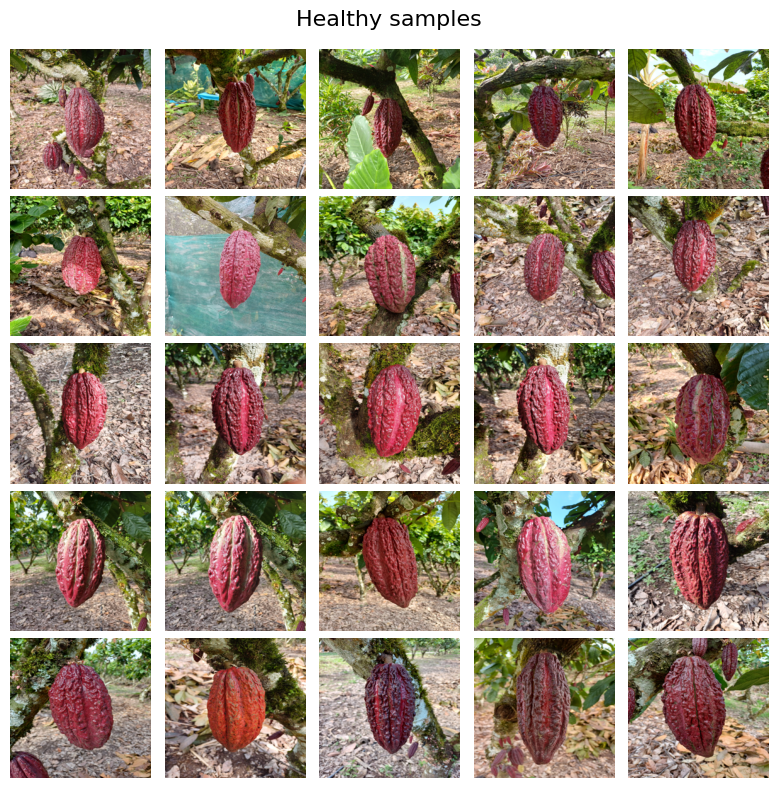

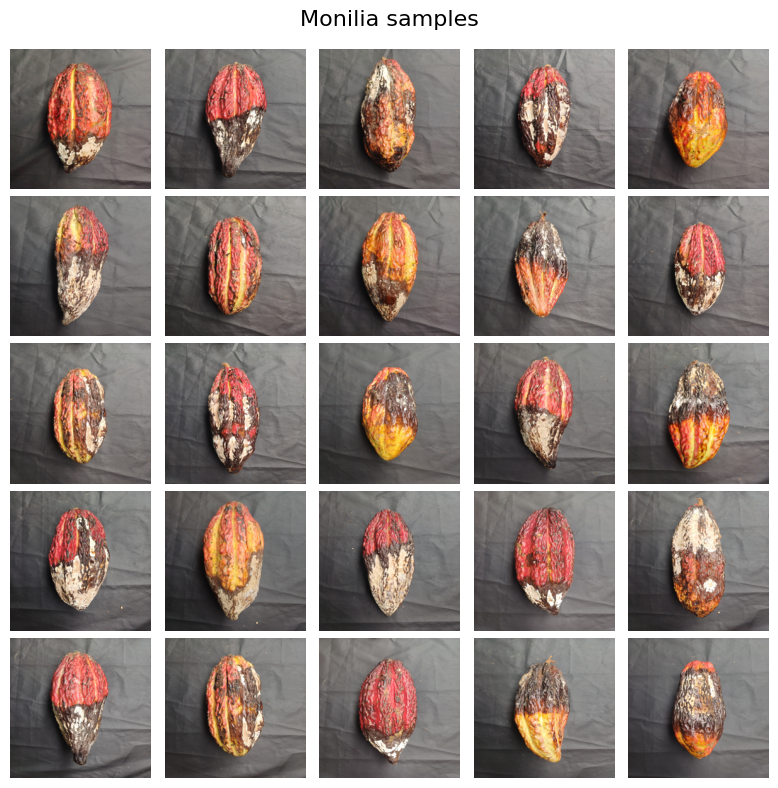

In [ ]:
# ------------------------------------------------------------
# Display representative image samples from each class
# ------------------------------------------------------------

import os
import matplotlib.pyplot as plt
from PIL import Image, ImageOps


def display_image_samples(class_path, class_name, n_samples=25):
    """
    Display a grid of image samples from a given class directory.

    Parameters
    ----------
    class_path : str
        Path to the directory containing the images.
    class_name : str
        Class name displayed as the figure title.
    n_samples : int, optional
        Maximum number of images to display. Default is 25.
    """

    # Supported image extensions
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp')

    # Retrieve and sort image filenames for reproducibility
    image_files = sorted([
        filename for filename in os.listdir(class_path)
        if filename.lower().endswith(valid_extensions)
    ])

    # Limit the number of displayed images
    image_files = image_files[:n_samples]

    if len(image_files) == 0:
        print(f"No valid images were found in: {class_path}")
        return

    # Define grid dimensions
    n_cols = 5
    n_rows = 5

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(8, 8)
    )

    fig.suptitle(
        f"{class_name} samples",
        fontsize=16,
        y=0.98
    )

    axes = axes.flatten()

    for i, filename in enumerate(image_files):

        image_path = os.path.join(class_path, filename)

        try:
            with Image.open(image_path) as img:

                # Correct orientation using EXIF metadata when available
                img = ImageOps.exif_transpose(img)

                # Convert to RGB for consistent visualization
                img = img.convert("RGB")

                # Resize only for visualization
                img = img.resize((224, 224))

                axes[i].imshow(img)
                axes[i].axis("off")

        except Exception as e:
            axes[i].axis("off")
            print(f"Could not open {filename}: {e}")

    # Hide unused subplots
    for j in range(len(image_files), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.subplots_adjust(
        wspace=0.02,
        hspace=0.05,
        top=0.93
    )

    plt.show()


# ------------------------------------------------------------
# Class directories
# ------------------------------------------------------------

healthy_path = os.path.join(dataset, "Sanos")
monilia_path = os.path.join(dataset, "Monilia")


# ------------------------------------------------------------
# Display image samples
# ------------------------------------------------------------

display_image_samples(
    healthy_path,
    "Healthy"
)

display_image_samples(
    monilia_path,
    "Monilia"
)

#**OBJETIVO 2: Implementar modelos híbridos basados en extracción de características mediante enfoques de clasificación directa y regresión con umbralización para la clasificación de moniliasis en imágenes de cacao.**

##**1. Balanceo de datos**

Total number of original images: 2184


,Class,Number of images,Percentage (%)
0,Monilia,1342,61.45
1,Healthy,842,38.55


Class imbalance ratio (majority/minority): 1.59:1


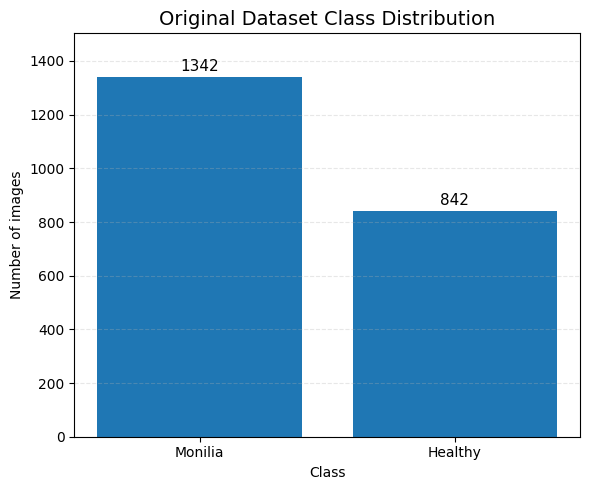

In [ ]:
# ------------------------------------------------------------
# Dataset class distribution
# ------------------------------------------------------------

def count_images_per_class(base_path):
    """
    Count the number of valid images in each class directory
    and display the original class distribution.

    Parameters
    ----------
    base_path : str
        Path to the root directory containing the class folders.
    """

    class_folders = {
        "Monilia": "Monilia",
        "Healthy": "Sanos"
    }

    valid_extensions = (
        ".jpg", ".jpeg", ".png",
        ".bmp", ".tif", ".tiff", ".webp"
    )

    counts = {}

    for class_name, folder_name in class_folders.items():

        class_path = os.path.join(base_path, folder_name)

        if not os.path.isdir(class_path):
            raise FileNotFoundError(
                f"Class directory not found: {class_path}"
            )

        image_files = [
            filename
            for filename in os.listdir(class_path)
            if filename.lower().endswith(valid_extensions)
        ]

        counts[class_name] = len(image_files)

    # --------------------------------------------------------
    # Summary table
    # --------------------------------------------------------

    distribution_df = pd.DataFrame({
        "Class": list(counts.keys()),
        "Number of images": list(counts.values())
    })

    total_images = distribution_df["Number of images"].sum()

    distribution_df["Percentage (%)"] = (
        distribution_df["Number of images"] / total_images * 100
    ).round(2)

    print(f"Total number of original images: {total_images}")
    display(distribution_df)

    # --------------------------------------------------------
    # Class imbalance ratio
    # --------------------------------------------------------

    min_count = distribution_df["Number of images"].min()
    max_count = distribution_df["Number of images"].max()

    imbalance_ratio = max_count / min_count

    print(
        f"Class imbalance ratio (majority/minority): "
        f"{imbalance_ratio:.2f}:1"
    )

    # --------------------------------------------------------
    # Visualization
    # --------------------------------------------------------

    plt.figure(figsize=(6, 5))

    bars = plt.bar(
        distribution_df["Class"],
        distribution_df["Number of images"]
    )

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(total_images * 0.005, 5),
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.title(
        "Original Dataset Class Distribution",
        fontsize=14
    )

    plt.xlabel("Class")
    plt.ylabel("Number of images")

    plt.ylim(
        0,
        max(distribution_df["Number of images"]) * 1.12
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

    return distribution_df


# ------------------------------------------------------------
# Analyze the original dataset
# ------------------------------------------------------------

class_distribution = count_images_per_class(dataset)

##**2. Split**

Original dataset distribution:


,Class,Number of images
0,Monilia,1342
1,Healthy,842



Images selected per class: 842
Balanced working cohort: 1684 images

Images per class:
Fine-tuning : 84
HPO         : 84
Training    : 590
Final test  : 84

Final balanced split:


class_name,Healthy,Monilia,Total
split,,,
fine_tuning,84,84,168
hpo,84,84,168
train,590,590,1180
test,84,84,168


No image-level overlap detected (0 duplicated paths).

Split manifest saved to:
/content/drive/MyDrive/Articulo_DiegoR/articulo/dataset_splits/balanced_split_manifest.csv

Unused images manifest saved to:
/content/drive/MyDrive/Articulo_DiegoR/articulo/dataset_splits/unused_images_manifest.csv

Unused original images: 500


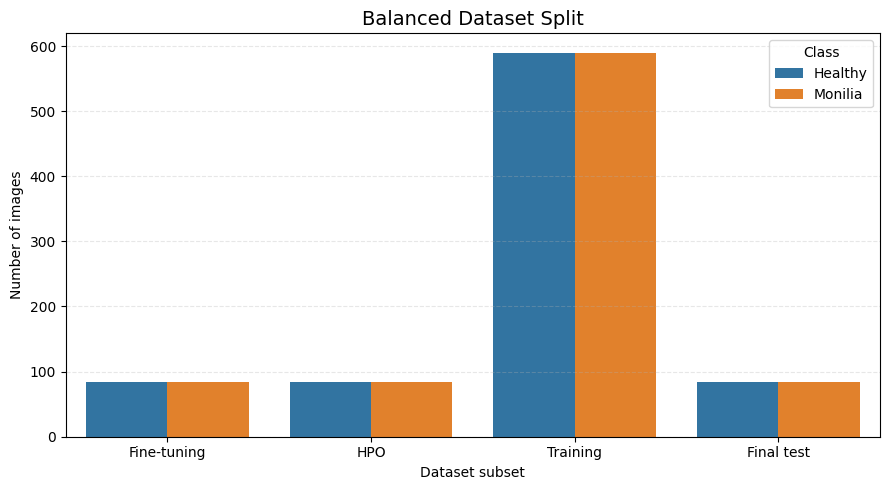

In [ ]:
# ------------------------------------------------------------
# Create a balanced and reproducible dataset split
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd

# Reproducibility seed
RANDOM_STATE = 42

# Supported image formats
VALID_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
)

# Original dataset folders
class_folders = {
    "Healthy": "Sanos",
    "Monilia": "Monilia"
}

# Numerical labels
class_labels = {
    "Healthy": 0,
    "Monilia": 1
}


# ------------------------------------------------------------
# Retrieve all original image paths
# ------------------------------------------------------------

dataset_records = []

for class_name, folder_name in class_folders.items():

    class_path = os.path.join(dataset, folder_name)

    image_files = sorted([
        filename
        for filename in os.listdir(class_path)
        if filename.lower().endswith(VALID_EXTENSIONS)
    ])

    for filename in image_files:

        dataset_records.append({
            "filepath": os.path.join(class_path, filename),
            "filename": filename,
            "class_name": class_name,
            "label": class_labels[class_name]
        })


dataset_df = pd.DataFrame(dataset_records)


# ------------------------------------------------------------
# Inspect original class distribution
# ------------------------------------------------------------

print("Original dataset distribution:")
display(
    dataset_df["class_name"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Number of images")
)


# ------------------------------------------------------------
# Determine the balanced cohort size
# ------------------------------------------------------------

class_counts = dataset_df["class_name"].value_counts()

n_per_class = class_counts.min()

print(f"\nImages selected per class: {n_per_class}")
print(f"Balanced working cohort: {n_per_class * 2} images")


# ------------------------------------------------------------
# Randomly select an equal number of images from each class
# ------------------------------------------------------------

selected_parts = []
unused_parts = []

for class_name in class_folders.keys():

    class_df = dataset_df[
        dataset_df["class_name"] == class_name
    ].copy()

    # Reproducible random shuffle
    class_df = class_df.sample(
        frac=1,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    # Images used in the balanced cohort
    selected_class = class_df.iloc[:n_per_class].copy()

    # Remaining images are kept on disk but not used
    unused_class = class_df.iloc[n_per_class:].copy()

    selected_parts.append(selected_class)

    if len(unused_class) > 0:
        unused_parts.append(unused_class)


balanced_df = pd.concat(
    selected_parts,
    ignore_index=True
)

if unused_parts:
    unused_df = pd.concat(
        unused_parts,
        ignore_index=True
    )
else:
    unused_df = pd.DataFrame(
        columns=dataset_df.columns
    )


# ------------------------------------------------------------
# Define exact split sizes per class
# ------------------------------------------------------------

n_finetune = int(round(n_per_class * 0.10))
n_hpo = int(round(n_per_class * 0.10))
n_test = int(round(n_per_class * 0.10))

# Assign the remainder to training
n_train = (
    n_per_class
    - n_finetune
    - n_hpo
    - n_test
)

print("\nImages per class:")
print(f"Fine-tuning : {n_finetune}")
print(f"HPO         : {n_hpo}")
print(f"Training    : {n_train}")
print(f"Final test  : {n_test}")


# ------------------------------------------------------------
# Split each class independently
# ------------------------------------------------------------

split_parts = []

for class_name in class_folders.keys():

    class_df = balanced_df[
        balanced_df["class_name"] == class_name
    ].copy()

    # Reproducible shuffle
    class_df = class_df.sample(
        frac=1,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    start = 0

    # Fine-tuning subset
    finetune_df = class_df.iloc[
        start:start + n_finetune
    ].copy()

    finetune_df["split"] = "fine_tuning"

    start += n_finetune


    # Hyperparameter optimization subset
    hpo_df = class_df.iloc[
        start:start + n_hpo
    ].copy()

    hpo_df["split"] = "hpo"

    start += n_hpo


    # Training subset
    train_df = class_df.iloc[
        start:start + n_train
    ].copy()

    train_df["split"] = "train"

    start += n_train


    # Locked final test subset
    test_df = class_df.iloc[
        start:start + n_test
    ].copy()

    test_df["split"] = "test"


    split_parts.extend([
        finetune_df,
        hpo_df,
        train_df,
        test_df
    ])


split_df = pd.concat(
    split_parts,
    ignore_index=True
)


# ------------------------------------------------------------
# Verify split distribution
# ------------------------------------------------------------

split_summary = (
    split_df
    .groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
)

split_summary["Total"] = split_summary.sum(axis=1)

# Desired order
split_order = [
    "fine_tuning",
    "hpo",
    "train",
    "test"
]

split_summary = split_summary.reindex(split_order)

print("\nFinal balanced split:")
display(split_summary)


# ------------------------------------------------------------
# Verify that no image appears in more than one subset
# ------------------------------------------------------------

duplicated_paths = split_df["filepath"].duplicated().sum()

assert duplicated_paths == 0, (
    "Error: the same image appears in more than one subset."
)

print(
    f"No image-level overlap detected "
    f"({duplicated_paths} duplicated paths)."
)


# ------------------------------------------------------------
# Save split manifests for reproducibility
# ------------------------------------------------------------

splits_directory = os.path.join(
    ejecucion,
    "dataset_splits"
)

os.makedirs(
    splits_directory,
    exist_ok=True
)


split_manifest_path = os.path.join(
    splits_directory,
    "balanced_split_manifest.csv"
)

unused_manifest_path = os.path.join(
    splits_directory,
    "unused_images_manifest.csv"
)


split_df.to_csv(
    split_manifest_path,
    index=False
)

unused_df.to_csv(
    unused_manifest_path,
    index=False
)


print("\nSplit manifest saved to:")
print(split_manifest_path)

print("\nUnused images manifest saved to:")
print(unused_manifest_path)

print(
    f"\nUnused original images: {len(unused_df)}"
)

# ------------------------------------------------------------
# Visualize the final dataset split
# ------------------------------------------------------------

plot_df = (
    split_df
    .groupby(["split", "class_name"])
    .size()
    .reset_index(name="Number of images")
)

split_labels = {
    "fine_tuning": "Fine-tuning",
    "hpo": "HPO",
    "train": "Training",
    "test": "Final test"
}

plot_df["Subset"] = (
    plot_df["split"]
    .map(split_labels)
)

subset_order = [
    "Fine-tuning",
    "HPO",
    "Training",
    "Final test"
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=plot_df,
    x="Subset",
    y="Number of images",
    hue="class_name",
    order=subset_order
)

plt.title(
    "Balanced Dataset Split",
    fontsize=14
)

plt.xlabel("Dataset subset")
plt.ylabel("Number of images")

plt.legend(
    title="Class"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

##**3. Segmentación de imágenes (quitar fondo)**

In [ ]:
# ============================================================
# YOLO CACAO SEGMENTATION - VISUAL TEST
# ============================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from ultralytics import YOLO


# ------------------------------------------------------------
# Verify segmentation model
# ------------------------------------------------------------

assert os.path.isfile(segmentador), (
    f"Segmentation model not found: {segmentador}"
)

print("[OK] Segmentation model found:")
print(segmentador)


# ------------------------------------------------------------
# Select processing device
# ------------------------------------------------------------

if torch.cuda.is_available():
    DEVICE = 0
    print("\nCUDA available : Yes")
    print("GPU             :", torch.cuda.get_device_name(0))
else:
    DEVICE = "cpu"
    print("\nCUDA available : No")
    print("Device          : CPU")


# ------------------------------------------------------------
# Load YOLO segmentation model only once
# ------------------------------------------------------------

cacao_segmenter = YOLO(segmentador)

print("\n[OK] YOLO segmentation model loaded.")

print("Model task      :", cacao_segmenter.task)
print("Model classes   :", cacao_segmenter.names)


# ------------------------------------------------------------
# Verify that this is a segmentation model
# ------------------------------------------------------------

if cacao_segmenter.task != "segment":
    raise ValueError(
        f"The loaded model task is '{cacao_segmenter.task}', "
        "but a segmentation model is required."
    )

print("[OK] Segmentation task confirmed.")

[OK] Segmentation model found:
/content/drive/MyDrive/Articulo_DiegoR/articulo/Segmentador_Cacao_YOLO26n_best.pt

CUDA available : Yes
GPU             : NVIDIA RTX PRO 6000 Blackwell Server Edition

[OK] YOLO segmentation model loaded.
Model task      : segment
Model classes   : {0: 'cacao'}
[OK] Segmentation task confirmed.


In [ ]:
# ============================================================
# CACAO SEGMENTATION FUNCTION
# ============================================================

def segment_cacao_yolo(
    image_path,
    confidence=0.25,
    imgsz=640,
    target_size=(224, 224)
):
    """
    Segment cacao pods using the pretrained YOLO segmentation model.

    All detected cacao masks are combined into a single foreground mask.
    The background is replaced with white.

    Returns
    -------
    original_rgb : np.ndarray
        Original RGB image.

    binary_mask : np.ndarray
        Combined binary cacao mask.

    segmented_rgb : np.ndarray
        Segmented RGB image with white background.

    detection_count : int
        Number of cacao instances detected.
    """

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    image_pil = Image.open(image_path)
    image_pil = ImageOps.exif_transpose(image_pil)
    image_pil = image_pil.convert("RGB")

    original_rgb = np.array(image_pil)

    height, width = original_rgb.shape[:2]

    # --------------------------------------------------------
    # YOLO inference
    # --------------------------------------------------------

    results = cacao_segmenter.predict(
        source=original_rgb,
        conf=confidence,
        imgsz=imgsz,
        device=YOLO_DEVICE,
        verbose=False
    )

    result = results[0]

    # --------------------------------------------------------
    # Verify masks
    # --------------------------------------------------------

    if result.masks is None or len(result.masks.data) == 0:
        raise RuntimeError(
            f"No cacao mask detected: {image_path}"
        )

    predicted_masks = (
        result.masks.data
        .detach()
        .cpu()
        .numpy()
    )

    # --------------------------------------------------------
    # Combine all detected masks
    # --------------------------------------------------------

    combined_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    for predicted_mask in predicted_masks:

        if predicted_mask.shape != (height, width):

            predicted_mask = cv2.resize(
                predicted_mask,
                (width, height),
                interpolation=cv2.INTER_NEAREST
            )

        binary_mask = (
            predicted_mask > 0.5
        ).astype(np.uint8)

        combined_mask = np.maximum(
            combined_mask,
            binary_mask
        )

    # --------------------------------------------------------
    # Create white-background image
    # --------------------------------------------------------

    segmented_rgb = np.full_like(
        original_rgb,
        255
    )

    segmented_rgb[
        combined_mask == 1
    ] = original_rgb[
        combined_mask == 1
    ]

    # --------------------------------------------------------
    # Resize final segmented image
    # --------------------------------------------------------

    segmented_rgb = np.array(
        Image.fromarray(segmented_rgb).resize(
            target_size,
            Image.Resampling.LANCZOS
        )
    )

    detection_count = len(predicted_masks)

    return (
        original_rgb,
        combined_mask,
        segmented_rgb,
        detection_count
    )

# ============================================================
# VISUAL SEGMENTATION TEST
# FINE-TUNING SUBSET ONLY
# ============================================================

def display_yolo_segmentation_examples(
    split_dataframe,
    class_name,
    n_samples=6,
    confidence=0.25,
    imgsz=640,
    random_state=42
):
    """
    Display original images, YOLO masks, and segmented outputs
    using only the fine-tuning subset.
    """

    samples = (
        split_dataframe[
            (split_dataframe["split"] == "fine_tuning")
            &
            (split_dataframe["class_name"] == class_name)
        ]
        .sample(
            n=n_samples,
            random_state=random_state
        )
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(
        nrows=3,
        ncols=n_samples,
        figsize=(3 * n_samples, 9)
    )

    success = 0
    failures = 0

    for i, row in samples.iterrows():

        try:

            original, mask, segmented, detection_count = (
                segment_cacao_yolo(
                    image_path=row["filepath"],
                    confidence=confidence,
                    imgsz=imgsz
                )
            )

            # Original
            axes[0, i].imshow(original)
            axes[0, i].axis("off")

            # Mask
            axes[1, i].imshow(
                mask,
                cmap="gray"
            )
            axes[1, i].axis("off")

            # Segmented
            axes[2, i].imshow(segmented)
            axes[2, i].axis("off")

            axes[2, i].set_title(
                f"{detection_count} detection(s)",
                fontsize=9
            )

            success += 1

        except Exception as e:

            failures += 1

            for r in range(3):
                axes[r, i].axis("off")
                axes[r, i].text(
                    0.5,
                    0.5,
                    "No mask",
                    ha="center",
                    va="center"
                )

            print(
                f"[WARNING] {row['filename']}: {e}"
            )

    axes[0, 0].set_ylabel(
        "Original",
        fontsize=12
    )

    axes[1, 0].set_ylabel(
        "YOLO mask",
        fontsize=12
    )

    axes[2, 0].set_ylabel(
        "Segmented",
        fontsize=12
    )

    fig.suptitle(
        f"{class_name}: YOLO cacao segmentation",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

    print(
        f"Successful segmentations: {success}/{n_samples}"
    )

    print(
        f"Failed segmentations     : {failures}/{n_samples}"
    )


# Ejecucion

display_yolo_segmentation_examples(
    split_df,
    class_name="Healthy",
    n_samples=6
)

display_yolo_segmentation_examples(
    split_df,
    class_name="Monilia",
    n_samples=6
)

In [ ]:
# ============================================================
# SEGMENT THE COMPLETE BALANCED DATASET
# ============================================================

import os
import pandas as pd

from tqdm.auto import tqdm
from PIL import Image


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

segmented_root = os.path.join(
    ejecucion,
    "segmented_images"
)

os.makedirs(
    segmented_root,
    exist_ok=True
)


# ------------------------------------------------------------
# Process all images defined in split_df
# ------------------------------------------------------------

segmentation_records = []


for _, row in tqdm(
    split_df.iterrows(),
    total=len(split_df),
    desc="Segmenting cacao images"
):

    original_path = row["filepath"]
    filename = row["filename"]
    class_name = row["class_name"]
    label = int(row["label"])
    split_name = row["split"]


    # --------------------------------------------------------
    # Create destination directory
    # --------------------------------------------------------

    output_directory = os.path.join(
        segmented_root,
        split_name,
        class_name
    )

    os.makedirs(
        output_directory,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Preserve original filename stem
    # --------------------------------------------------------

    filename_stem = os.path.splitext(
        filename
    )[0]

    segmented_filename = (
        f"{filename_stem}.png"
    )

    segmented_path = os.path.join(
        output_directory,
        segmented_filename
    )


    # --------------------------------------------------------
    # Segment image
    # --------------------------------------------------------

    try:

        (
            original_rgb,
            binary_mask,
            segmented_rgb,
            detection_count
        ) = segment_cacao_yolo(
            image_path=original_path,
            confidence=0.25,
            imgsz=640,
            target_size=(224, 224)
        )


        # ----------------------------------------------------
        # Save segmented image
        # ----------------------------------------------------

        Image.fromarray(
            segmented_rgb
        ).save(
            segmented_path,
            format="PNG"
        )


        status = "success"


    except Exception as e:

        segmented_path = None
        detection_count = 0
        status = f"error: {type(e).__name__}: {e}"


    # --------------------------------------------------------
    # Record processing metadata
    # --------------------------------------------------------

    segmentation_records.append({

        "filename": filename,
        "class_name": class_name,
        "label": label,
        "split": split_name,

        "original_path": original_path,
        "segmented_path": segmented_path,

        "detections": detection_count,
        "status": status
    })


# ------------------------------------------------------------
# Create segmentation manifest
# ------------------------------------------------------------

segmentation_df = pd.DataFrame(
    segmentation_records
)


# ------------------------------------------------------------
# Save segmentation manifest
# ------------------------------------------------------------

os.makedirs(
    splits_directory,
    exist_ok=True
)

segmentation_df.to_csv(
    segmentation_manifest_path,
    index=False
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

success_count = (
    segmentation_df["status"] == "success"
).sum()

failure_count = (
    segmentation_df["status"] != "success"
).sum()


print("\n" + "=" * 70)
print("SEGMENTATION SUMMARY")
print("=" * 70)

print(f"Total images              : {len(segmentation_df)}")
print(f"Successful segmentations  : {success_count}")
print(f"Failed segmentations      : {failure_count}")

print(
    f"\nSegmentation manifest:\n"
    f"{segmentation_manifest_path}"
)

print("=" * 70)

# ============================================================
# VERIFY SEGMENTED DATASET
# ============================================================

successful_df = segmentation_df[
    segmentation_df["status"] == "success"
].copy()


segmentation_summary = (
    successful_df
    .groupby(
        ["split", "class_name"]
    )
    .size()
    .unstack(fill_value=0)
)


split_order = [
    "fine_tuning",
    "hpo",
    "train",
    "test"
]

segmentation_summary = (
    segmentation_summary
    .reindex(split_order)
)

segmentation_summary["Total"] = (
    segmentation_summary.sum(axis=1)
)


display(segmentation_summary)


# ------------------------------------------------------------
# Path verification
# ------------------------------------------------------------

missing_original = (
    ~successful_df["original_path"]
    .apply(os.path.isfile)
).sum()

missing_segmented = (
    ~successful_df["segmented_path"]
    .apply(os.path.isfile)
).sum()


print(
    f"Missing original images  : {missing_original}"
)

print(
    f"Missing segmented images : {missing_segmented}"
)


# ------------------------------------------------------------
# Dataset integrity checks
# ------------------------------------------------------------

assert len(segmentation_df) == len(split_df), (
    "Mismatch between split manifest and segmentation manifest."
)

assert missing_original == 0, (
    "Some original images cannot be found."
)

assert missing_segmented == 0, (
    "Some segmented images cannot be found."
)

assert (
    successful_df["original_path"]
    .duplicated()
    .sum()
    == 0
), "Duplicated original image paths detected."

assert (
    successful_df["segmented_path"]
    .duplicated()
    .sum()
    == 0
), "Duplicated segmented image paths detected."


print("\n[OK] Segmented dataset integrity verified.")

## **4. Carga de imágenes y almacenamiento de datos en array**

In [ ]:
#Carga de imagenes y almacen de datos en array
ruta_base = '/content/drive/MyDrive/Dataset Cacao Segmentado'
clases = {'Sanos': 0, 'Monilia': 1}
tamaño_img = (224, 224)

X, y = [], []

for clase, etiqueta in clases.items():
    carpeta = os.path.join(ruta_base, clase)
    imagenes = [f for f in os.listdir(carpeta) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for nombre in tqdm(imagenes, desc=f'Procesando {clase}'):
        ruta_img = os.path.join(carpeta, nombre)
        img = Image.open(ruta_img).convert("RGB").resize(tamaño_img)
        img_array = np.array(img)
        img_array = preprocess_input(img_array)
        X.append(img_array)
        y.append(etiqueta)

X = np.array(X)
y = np.array(y).astype(np.float32)

print("X:", X.shape)
print("y:", y[0], "o", y[2001])


##**5. Fine-tuning**

In [ ]:
# ============================================================
# SEGMENTED MOBILENETV2 FINE-TUNING
# RESUMABLE AND CHECKPOINTED VERSION
# ============================================================

import os
import gc
import json
import random
import shutil

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from IPython.display import display

from tensorflow.keras import (
    layers,
    models,
    Input,
    regularizers
)

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.model_selection import train_test_split


# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

RANDOM_STATE = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


print("=" * 75)
print("SEGMENTED MOBILENETV2 FINE-TUNING")
print("=" * 75)


# ============================================================
# 2. LOAD EXPERIMENT MANIFEST IF NECESSARY
# ============================================================

if "experiment_df" not in globals():

    assert os.path.isfile(
        segmentation_manifest_path
    ), (
        "Segmentation manifest was not found."
    )

    experiment_df = pd.read_csv(
        segmentation_manifest_path
    )

    print(
        "[OK] Experiment manifest loaded."
    )


assert len(experiment_df) == 1684, (
    f"Expected 1684 records, "
    f"found {len(experiment_df)}."
)


# ============================================================
# 3. PREPARE FINE-TUNING SUBSET
# ============================================================

finetune_df = experiment_df[
    (experiment_df["split"] == "fine_tuning")
    &
    (experiment_df["status"] == "success")
].copy()


assert len(finetune_df) == 168, (
    f"Expected 168 fine-tuning images, "
    f"found {len(finetune_df)}."
)


print("\nFine-tuning subset:")
display(
    finetune_df[
        "class_name"
    ]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Images")
)


# ============================================================
# 4. LOAD OR CREATE INTERNAL TRAIN / VALIDATION SPLIT
# ============================================================

fine_tuning_split_path = os.path.join(
    splits_directory,
    "fine_tuning_internal_split.csv"
)


if os.path.isfile(
    fine_tuning_split_path
):

    fine_tuning_split_df = pd.read_csv(
        fine_tuning_split_path
    )

    print(
        "[OK] Existing internal split loaded."
    )

else:

    ft_train_df, ft_val_df = train_test_split(
        finetune_df,
        test_size=0.20,
        stratify=finetune_df["label"],
        random_state=RANDOM_STATE
    )

    ft_train_df = ft_train_df.copy()
    ft_val_df = ft_val_df.copy()

    ft_train_df[
        "internal_split"
    ] = "train"

    ft_val_df[
        "internal_split"
    ] = "validation"

    fine_tuning_split_df = pd.concat(
        [
            ft_train_df,
            ft_val_df
        ],
        ignore_index=True
    )

    fine_tuning_split_df.to_csv(
        fine_tuning_split_path,
        index=False
    )

    print(
        "[OK] Internal split created and saved."
    )


ft_train_df = (
    fine_tuning_split_df[
        fine_tuning_split_df[
            "internal_split"
        ] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)


ft_val_df = (
    fine_tuning_split_df[
        fine_tuning_split_df[
            "internal_split"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)


assert len(ft_train_df) == 134
assert len(ft_val_df) == 34

assert set(
    ft_train_df["filename"]
).isdisjoint(
    set(ft_val_df["filename"])
)


print(
    f"\nFine-tuning training   : "
    f"{len(ft_train_df)}"
)

print(
    f"Fine-tuning validation : "
    f"{len(ft_val_df)}"
)

print("\nTraining distribution:")
display(
    ft_train_df[
        "class_name"
    ].value_counts()
)

print("\nValidation distribution:")
display(
    ft_val_df[
        "class_name"
    ].value_counts()
)

print(
    "\n[OK] Fine-tuning split verified."
)


# ============================================================
# 5. IMAGE LOADING PIPELINE
# ============================================================

def _load_image_with_pil(path):

    path = path.numpy().decode(
        "utf-8"
    )

    with Image.open(path) as img:

        img = ImageOps.exif_transpose(
            img
        )

        img = img.convert(
            "RGB"
        )

        img = img.resize(
            IMG_SIZE,
            Image.Resampling.LANCZOS
        )

        image_array = np.asarray(
            img,
            dtype=np.float32
        )

    return image_array


def load_and_preprocess_image(
    path,
    label
):

    image = tf.py_function(
        func=_load_image_with_pil,
        inp=[path],
        Tout=tf.float32
    )

    image.set_shape(
        [
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        ]
    )

    image = preprocess_input(
        image
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label


def create_tf_dataset(
    dataframe,
    path_column,
    training=False,
    batch_size=BATCH_SIZE
):

    paths = (
        dataframe[path_column]
        .astype(str)
        .to_numpy()
    )

    labels = (
        dataframe["label"]
        .astype(np.float32)
        .to_numpy()
    )

    ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (paths, labels)
        )
    )

    ds = ds.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Only 168 fine-tuning images,
    # therefore caching is safe.
    ds = ds.cache()

    if training:

        ds = ds.shuffle(
            buffer_size=len(
                dataframe
            ),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(
        batch_size
    )

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds


print(
    "[OK] Image pipeline ready."
)


# ============================================================
# 6. BUILD MOBILENETV2 MODEL
# ============================================================

def build_mobilenet_model(
    dropout_rate
):

    backbone = MobileNetV2(
        input_shape=(
            224,
            224,
            3
        ),
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )

    backbone.trainable = False


    inputs = Input(
        shape=(
            224,
            224,
            3
        ),
        name="image"
    )


    backbone_features = backbone(
        inputs,
        training=False
    )


    # 1280-dimensional MobileNetV2 vector
    deep_features = layers.Activation(
        "linear",
        name="deep_features"
    )(
        backbone_features
    )


    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=
            regularizers.l2(
                0.001
            ),
        name="classification_dense"
    )(
        deep_features
    )


    x = layers.Dropout(
        dropout_rate,
        name="classification_dropout"
    )(
        x
    )


    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="classification_output"
    )(
        x
    )


    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name=(
            "MobileNetV2_"
            "binary_classifier"
        )
    )


    return model, backbone


# ============================================================
# 7. COMPILE MODEL
# ============================================================

def compile_binary_model(
    model,
    learning_rate
):

    model.compile(

        optimizer=Adam(
            learning_rate=
                learning_rate
        ),

        loss=tf.keras.losses.BinaryCrossentropy(),

        metrics=[

            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),

            tf.keras.metrics.AUC(
                name="auc"
            ),

            tf.keras.metrics.Precision(
                name="precision"
            ),

            tf.keras.metrics.Recall(
                name="recall"
            )
        ]
    )


# ============================================================
# 8. PARTIALLY UNFREEZE MOBILENETV2
# ============================================================

def unfreeze_backbone_tail(
    backbone,
    n_layers
):

    backbone.trainable = True

    # Freeze all first
    for layer in backbone.layers:

        layer.trainable = False


    # Unfreeze final N layers
    for layer in backbone.layers[
        -n_layers:
    ]:

        # Keep BatchNormalization frozen
        if not isinstance(
            layer,
            layers.BatchNormalization
        ):

            layer.trainable = True


    trainable_layers = sum(
        layer.trainable
        for layer in backbone.layers
    )


    return trainable_layers


# ============================================================
# 9. SEARCH SPACE
# ============================================================

UNFREEZE_OPTIONS = [
    20,
    30,
    40
]

LEARNING_RATES = [
    1e-4,
    1e-5
]

DROPOUT_RATES = [
    0.3,
    0.5
]

WARMUP_EPOCHS = 5
FINE_TUNING_EPOCHS = 30


TOTAL_CONFIGURATIONS = (
    len(UNFREEZE_OPTIONS)
    *
    len(LEARNING_RATES)
    *
    len(DROPOUT_RATES)
)


print(
    "\nTotal segmented configurations:",
    TOTAL_CONFIGURATIONS
)


# ============================================================
# 10. OUTPUT DIRECTORIES
# ============================================================

models_directory = os.path.join(
    ejecucion,
    "models",
    "feature_extractors"
)

results_directory = os.path.join(
    ejecucion,
    "results",
    "fine_tuning"
)

checkpoint_directory = os.path.join(
    results_directory,
    "checkpoints"
)


os.makedirs(
    models_directory,
    exist_ok=True
)

os.makedirs(
    results_directory,
    exist_ok=True
)

os.makedirs(
    checkpoint_directory,
    exist_ok=True
)


# ============================================================
# 11. PROTECT PREVIOUS PARTIAL SEGMENTED MODEL
# ============================================================

old_segmented_model = os.path.join(
    models_directory,
    "mobilenetv2_segmented_finetuned.keras"
)

old_segmented_backup = os.path.join(
    models_directory,
    "mobilenetv2_segmented_previous_partial_backup.keras"
)


if (
    os.path.isfile(
        old_segmented_model
    )
    and
    not os.path.isfile(
        old_segmented_backup
    )
):

    shutil.copy2(
        old_segmented_model,
        old_segmented_backup
    )

    print(
        "\n[OK] Previous partial segmented "
        "model backed up."
    )


# ============================================================
# 12. NEW RESUMABLE CHECKPOINT PATHS
#
# IMPORTANT:
# These filenames are different from the old search.
# Therefore the previous incomplete run cannot interfere.
# ============================================================

checkpoint_csv = os.path.join(
    checkpoint_directory,
    "segmented_resumable_search.csv"
)

checkpoint_best_model = os.path.join(
    checkpoint_directory,
    "segmented_resumable_best.keras"
)

checkpoint_best_config = os.path.join(
    checkpoint_directory,
    "segmented_resumable_best_config.json"
)

checkpoint_best_history = os.path.join(
    checkpoint_directory,
    "segmented_resumable_best_history.json"
)


# ============================================================
# 13. LOAD EXISTING CHECKPOINT IF AVAILABLE
# ============================================================

if os.path.isfile(
    checkpoint_csv
):

    search_df = pd.read_csv(
        checkpoint_csv
    )

    print(
        f"\n[RESUME] "
        f"{len(search_df)} configuration(s) "
        f"already completed."
    )

else:

    search_df = pd.DataFrame()

    print(
        "\n[NEW SEARCH] No resumable "
        "checkpoint found."
    )


# ------------------------------------------------------------
# Determine configurations already finished
# ------------------------------------------------------------

completed_configs = set()


if len(search_df) > 0:

    for _, row in search_df.iterrows():

        completed_configs.add(
            (
                int(
                    row[
                        "unfrozen_layers"
                    ]
                ),

                float(
                    row[
                        "learning_rate"
                    ]
                ),

                float(
                    row[
                        "dropout"
                    ]
                )
            )
        )


# ------------------------------------------------------------
# Determine current best result
# ------------------------------------------------------------

if len(search_df) > 0:

    best_index = (
        search_df[
            "val_loss"
        ]
        .astype(float)
        .idxmin()
    )

    best_val_loss = float(
        search_df.loc[
            best_index,
            "val_loss"
        ]
    )

else:

    best_val_loss = np.inf


print(
    f"Configurations already completed: "
    f"{len(completed_configs)}/"
    f"{TOTAL_CONFIGURATIONS}"
)


# ============================================================
# 14. RESUMABLE SEGMENTED FINE-TUNING SEARCH
# ============================================================

configuration_number = 0


for n_layers in UNFREEZE_OPTIONS:

    for learning_rate in LEARNING_RATES:

        for dropout_rate in DROPOUT_RATES:

            configuration_number += 1


            config_key = (
                int(n_layers),
                float(learning_rate),
                float(dropout_rate)
            )


            # ------------------------------------------------
            # Skip finished configuration
            # ------------------------------------------------

            if config_key in completed_configs:

                print(
                    f"\n[{configuration_number}/"
                    f"{TOTAL_CONFIGURATIONS}] "
                    f"layers={n_layers}, "
                    f"lr={learning_rate}, "
                    f"dropout={dropout_rate} "
                    f"→ ALREADY COMPLETED"
                )

                continue


            print(
                f"\n[{configuration_number}/"
                f"{TOTAL_CONFIGURATIONS}] "
                f"layers={n_layers}, "
                f"lr={learning_rate}, "
                f"dropout={dropout_rate}"
            )


            # =================================================
            # DETERMINISTIC SEED FOR THIS CONFIGURATION
            # =================================================

            config_seed = (
                RANDOM_STATE
                +
                configuration_number
            )


            tf.keras.utils.set_random_seed(
                config_seed
            )


            # =================================================
            # CLEAN PREVIOUS MODEL
            # =================================================

            tf.keras.backend.clear_session()

            gc.collect()


            # =================================================
            # CREATE DATASETS
            # =================================================

            train_ds = create_tf_dataset(
                ft_train_df,
                path_column="segmented_path",
                training=True
            )


            val_ds = create_tf_dataset(
                ft_val_df,
                path_column="segmented_path",
                training=False
            )


            # =================================================
            # CREATE MODEL
            # =================================================

            model, backbone = (
                build_mobilenet_model(
                    dropout_rate=
                        dropout_rate
                )
            )


            # =================================================
            # STAGE 1:
            # CLASSIFICATION HEAD WARM-UP
            # =================================================

            compile_binary_model(
                model,
                learning_rate=1e-3
            )


            model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=WARMUP_EPOCHS,
                verbose=0
            )


            # =================================================
            # STAGE 2:
            # PARTIAL MOBILENETV2 FINE-TUNING
            # =================================================

            trainable_backbone_layers = (
                unfreeze_backbone_tail(
                    backbone,
                    n_layers=n_layers
                )
            )


            compile_binary_model(
                model,
                learning_rate=
                    learning_rate
            )


            early_stopping = EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True,
                mode="min"
            )


            reduce_lr = ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=2,
                min_lr=1e-7,
                mode="min",
                verbose=0
            )


            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=FINE_TUNING_EPOCHS,
                callbacks=[
                    early_stopping,
                    reduce_lr
                ],
                verbose=0
            )


            # =================================================
            # BEST EPOCH
            # =================================================

            config_best_epoch = (
                int(
                    np.argmin(
                        history.history[
                            "val_loss"
                        ]
                    )
                )
                + 1
            )


            config_best_val_loss = float(
                np.min(
                    history.history[
                        "val_loss"
                    ]
                )
            )


            # =================================================
            # VALIDATION METRICS
            # =================================================

            validation_metrics = (
                model.evaluate(
                    val_ds,
                    verbose=0,
                    return_dict=True
                )
            )


            print(
                f"    best epoch="
                f"{config_best_epoch} | "
                f"val_loss="
                f"{config_best_val_loss:.4f} | "
                f"accuracy="
                f"{validation_metrics['accuracy']:.4f} | "
                f"AUC="
                f"{validation_metrics['auc']:.4f}"
            )


            # =================================================
            # CURRENT RESULT
            # =================================================

            current_record = {

                "configuration":
                    configuration_number,

                "random_seed":
                    config_seed,

                "unfrozen_layers":
                    int(n_layers),

                "trainable_backbone_layers":
                    int(
                        trainable_backbone_layers
                    ),

                "learning_rate":
                    float(
                        learning_rate
                    ),

                "dropout":
                    float(
                        dropout_rate
                    ),

                "best_epoch":
                    int(
                        config_best_epoch
                    ),

                "val_loss":
                    float(
                        config_best_val_loss
                    ),

                "val_accuracy":
                    float(
                        validation_metrics[
                            "accuracy"
                        ]
                    ),

                "val_auc":
                    float(
                        validation_metrics[
                            "auc"
                        ]
                    ),

                "val_precision":
                    float(
                        validation_metrics[
                            "precision"
                        ]
                    ),

                "val_recall":
                    float(
                        validation_metrics[
                            "recall"
                        ]
                    )
            }


            # =================================================
            # SAVE SEARCH CHECKPOINT IMMEDIATELY
            # =================================================

            if os.path.isfile(
                checkpoint_csv
            ):

                search_df = pd.read_csv(
                    checkpoint_csv
                )

            else:

                search_df = pd.DataFrame()


            search_df = pd.concat(
                [
                    search_df,
                    pd.DataFrame(
                        [current_record]
                    )
                ],
                ignore_index=True
            )


            # Prevent duplicates if the cell
            # is executed again.
            search_df = (
                search_df
                .drop_duplicates(
                    subset=[
                        "unfrozen_layers",
                        "learning_rate",
                        "dropout"
                    ],
                    keep="last"
                )
                .sort_values(
                    "configuration"
                )
                .reset_index(
                    drop=True
                )
            )


            search_df.to_csv(
                checkpoint_csv,
                index=False
            )


            # =================================================
            # SAVE NEW BEST MODEL IMMEDIATELY
            # =================================================

            if (
                config_best_val_loss
                <
                best_val_loss
            ):

                best_val_loss = (
                    config_best_val_loss
                )


                model.save(
                    checkpoint_best_model,
                    overwrite=True
                )


                best_config = {

                    "configuration":
                        configuration_number,

                    "unfrozen_layers":
                        int(n_layers),

                    "learning_rate":
                        float(
                            learning_rate
                        ),

                    "dropout":
                        float(
                            dropout_rate
                        ),

                    "best_epoch":
                        int(
                            config_best_epoch
                        ),

                    "val_loss":
                        float(
                            config_best_val_loss
                        ),

                    "val_accuracy":
                        float(
                            validation_metrics[
                                "accuracy"
                            ]
                        ),

                    "val_auc":
                        float(
                            validation_metrics[
                                "auc"
                            ]
                        )
                }


                with open(
                    checkpoint_best_config,
                    "w"
                ) as f:

                    json.dump(
                        best_config,
                        f,
                        indent=4
                    )


                serializable_history = {

                    key: [
                        float(value)
                        for value
                        in values
                    ]

                    for key, values
                    in history.history.items()
                }


                with open(
                    checkpoint_best_history,
                    "w"
                ) as f:

                    json.dump(
                        serializable_history,
                        f,
                        indent=4
                    )


                print(
                    "    [NEW BEST MODEL SAVED]"
                )


            print(
                "    [CHECKPOINT SAVED TO DRIVE]"
            )


            # Update completed set in memory
            completed_configs.add(
                config_key
            )


# ============================================================
# 15. VERIFY SEARCH COMPLETION
# ============================================================

search_df = pd.read_csv(
    checkpoint_csv
)


print("\n" + "=" * 75)
print("SEGMENTED SEARCH STATUS")
print("=" * 75)

print(
    f"Completed configurations: "
    f"{len(search_df)}/"
    f"{TOTAL_CONFIGURATIONS}"
)


display(
    search_df.sort_values(
        "val_loss"
    ).reset_index(
        drop=True
    )
)


assert len(search_df) == TOTAL_CONFIGURATIONS, (
    "The search is not complete yet. "
    "If Colab was interrupted, run this entire cell again "
    "and it will resume automatically."
)


# ============================================================
# 16. LOAD BEST SEGMENTED MODEL
# ============================================================

assert os.path.isfile(
    checkpoint_best_model
), (
    "Best segmented model checkpoint was not found."
)


best_segmented_model = (
    models.load_model(
        checkpoint_best_model
    )
)


# ============================================================
# 17. CREATE SEGMENTED FEATURE EXTRACTOR
# ============================================================

segmented_feature_extractor = (
    models.Model(

        inputs=
            best_segmented_model.input,

        outputs=
            best_segmented_model
            .get_layer(
                "deep_features"
            )
            .output,

        name=(
            "mobilenetv2_"
            "segmented_"
            "feature_extractor"
        )
    )
)


# ============================================================
# 18. PUBLISH FINAL SEGMENTED ARTIFACTS
# ============================================================

final_segmented_model_path = os.path.join(
    models_directory,
    "mobilenetv2_segmented_finetuned.keras"
)

final_segmented_extractor_path = os.path.join(
    models_directory,
    "mobilenetv2_segmented_extractor.keras"
)

final_segmented_results_path = os.path.join(
    results_directory,
    "fine_tuning_segmented_search_results.csv"
)

final_segmented_config_path = os.path.join(
    results_directory,
    "fine_tuning_segmented_best_config.json"
)

final_segmented_history_path = os.path.join(
    results_directory,
    "fine_tuning_segmented_best_history.json"
)


# Save final model
best_segmented_model.save(
    final_segmented_model_path,
    overwrite=True
)


# Save feature extractor
segmented_feature_extractor.save(
    final_segmented_extractor_path,
    overwrite=True
)


# Save search table
search_df.to_csv(
    final_segmented_results_path,
    index=False
)


# Copy best configuration
shutil.copy2(
    checkpoint_best_config,
    final_segmented_config_path
)


# Copy best history
shutil.copy2(
    checkpoint_best_history,
    final_segmented_history_path
)


# ============================================================
# 19. LOAD AND DISPLAY BEST CONFIGURATION
# ============================================================

with open(
    final_segmented_config_path,
    "r"
) as f:

    segmented_best_config = (
        json.load(f)
    )


print("\n" + "=" * 75)
print("BEST SEGMENTED CONFIGURATION")
print("=" * 75)


for key, value in (
    segmented_best_config.items()
):

    print(
        f"{key:<20}: {value}"
    )


print(
    "\n[OK] Segmented fine-tuning completed."
)


print(
    "\nFinal fine-tuned model:"
)

print(
    final_segmented_model_path
)


print(
    "\nFinal feature extractor:"
)

print(
    final_segmented_extractor_path
)


print(
    "\nSearch results:"
)

print(
    final_segmented_results_path
)


# ============================================================
# 20. PLOT BEST SEGMENTED LEARNING CURVE
# ============================================================

with open(
    final_segmented_history_path,
    "r"
) as f:

    best_history = json.load(
        f
    )


plt.figure(
    figsize=(8, 5)
)


plt.plot(
    best_history["loss"],
    label="Training loss"
)


plt.plot(
    best_history["val_loss"],
    label="Validation loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Binary cross-entropy loss"
)

plt.title(
    "MobileNetV2 Fine-Tuning - Segmented Images"
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# FINAL CONTROLLED REFIT OF MOBILENETV2 FEATURE EXTRACTORS
# ORIGINAL vs. SEGMENTED
# ============================================================

import os
import gc
import json
import random

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from IPython.display import display

from tensorflow.keras import (
    layers,
    models,
    Input,
    regularizers
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

WARMUP_EPOCHS = 5
CONFIRMATION_MAX_EPOCHS = 30

FINAL_REFIT_SEED = 2026


random.seed(FINAL_REFIT_SEED)
np.random.seed(FINAL_REFIT_SEED)
tf.random.set_seed(FINAL_REFIT_SEED)


print("=" * 80)
print("FINAL CONTROLLED MOBILENETV2 REFIT")
print("=" * 80)


# ============================================================
# 2. OUTPUT DIRECTORIES
# ============================================================

models_directory = os.path.join(
    ejecucion,
    "models",
    "feature_extractors"
)

results_directory = os.path.join(
    ejecucion,
    "results",
    "fine_tuning"
)

final_results_directory = os.path.join(
    results_directory,
    "final_refit"
)


os.makedirs(
    models_directory,
    exist_ok=True
)

os.makedirs(
    final_results_directory,
    exist_ok=True
)


# ============================================================
# 3. LOAD BEST CONFIGURATIONS
# ============================================================

original_config_path = os.path.join(
    results_directory,
    "fine_tuning_original_best_config.json"
)

segmented_config_path = os.path.join(
    results_directory,
    "fine_tuning_segmented_best_config.json"
)


assert os.path.isfile(
    original_config_path
), (
    f"Original best configuration not found:\n"
    f"{original_config_path}"
)

assert os.path.isfile(
    segmented_config_path
), (
    f"Segmented best configuration not found:\n"
    f"{segmented_config_path}"
)


with open(
    original_config_path,
    "r"
) as f:

    original_best_config = json.load(f)


with open(
    segmented_config_path,
    "r"
) as f:

    segmented_best_config = json.load(f)


print("\nORIGINAL best configuration:")
print(original_best_config)

print("\nSEGMENTED best configuration:")
print(segmented_best_config)


# ============================================================
# 4. LOAD EXPERIMENT MANIFEST IF NECESSARY
# ============================================================

if "experiment_df" not in globals():

    assert os.path.isfile(
        segmentation_manifest_path
    )

    experiment_df = pd.read_csv(
        segmentation_manifest_path
    )


assert len(experiment_df) == 1684


# ============================================================
# 5. FINE-TUNING SUBSET
# ============================================================

finetune_df = experiment_df[
    (experiment_df["split"] == "fine_tuning")
    &
    (experiment_df["status"] == "success")
].copy()


assert len(finetune_df) == 168


print("\nFine-tuning subset:")
display(
    finetune_df[
        "class_name"
    ]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Images")
)


# ============================================================
# 6. RESTORE INTERNAL TRAIN / VALIDATION SPLIT
# ============================================================

fine_tuning_split_path = os.path.join(
    splits_directory,
    "fine_tuning_internal_split.csv"
)


assert os.path.isfile(
    fine_tuning_split_path
), (
    "Internal fine-tuning split was not found."
)


fine_tuning_split_df = pd.read_csv(
    fine_tuning_split_path
)


ft_train_df = (
    fine_tuning_split_df[
        fine_tuning_split_df[
            "internal_split"
        ] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)


ft_val_df = (
    fine_tuning_split_df[
        fine_tuning_split_df[
            "internal_split"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)


assert len(ft_train_df) == 134
assert len(ft_val_df) == 34

assert set(
    ft_train_df["filename"]
).isdisjoint(
    set(ft_val_df["filename"])
)


print(
    f"\nInternal training   : {len(ft_train_df)}"
)

print(
    f"Internal validation : {len(ft_val_df)}"
)

print("[OK] Internal split restored.")


# ============================================================
# 7. IMAGE PIPELINE
# ============================================================

def _load_image_with_pil(path):

    path = path.numpy().decode(
        "utf-8"
    )

    with Image.open(path) as img:

        img = ImageOps.exif_transpose(
            img
        )

        img = img.convert(
            "RGB"
        )

        img = img.resize(
            IMG_SIZE,
            Image.Resampling.LANCZOS
        )

        image_array = np.asarray(
            img,
            dtype=np.float32
        )

    return image_array


def load_and_preprocess_image(
    path,
    label
):

    image = tf.py_function(
        func=_load_image_with_pil,
        inp=[path],
        Tout=tf.float32
    )

    image.set_shape(
        [
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        ]
    )

    image = preprocess_input(
        image
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label


def create_tf_dataset(
    dataframe,
    path_column,
    training=False,
    batch_size=BATCH_SIZE,
    shuffle_seed=FINAL_REFIT_SEED
):

    paths = (
        dataframe[path_column]
        .astype(str)
        .to_numpy()
    )

    labels = (
        dataframe["label"]
        .astype(np.float32)
        .to_numpy()
    )


    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )


    ds = ds.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    # Fine-tuning subset is small enough to cache in memory.
    ds = ds.cache()


    if training:

        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=shuffle_seed,
            reshuffle_each_iteration=True
        )


    ds = ds.batch(
        batch_size
    )


    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )


    return ds


print("[OK] Image pipeline ready.")


# ============================================================
# 8. MOBILENETV2 MODEL
# ============================================================

def build_mobilenet_model(
    dropout_rate
):

    backbone = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )


    backbone.trainable = False


    inputs = Input(
        shape=(224, 224, 3),
        name="image"
    )


    backbone_features = backbone(
        inputs,
        training=False
    )


    # 1280-dimensional MobileNetV2 representation
    deep_features = layers.Activation(
        "linear",
        name="deep_features"
    )(
        backbone_features
    )


    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=
            regularizers.l2(0.001),
        name="classification_dense"
    )(
        deep_features
    )


    x = layers.Dropout(
        dropout_rate,
        name="classification_dropout"
    )(
        x
    )


    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="classification_output"
    )(
        x
    )


    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="MobileNetV2_binary_classifier"
    )


    return model, backbone


# ============================================================
# 9. COMPILATION
# ============================================================

def compile_binary_model(
    model,
    learning_rate
):

    model.compile(

        optimizer=Adam(
            learning_rate=learning_rate
        ),

        loss=tf.keras.losses.BinaryCrossentropy(),

        metrics=[

            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),

            tf.keras.metrics.AUC(
                name="auc"
            ),

            tf.keras.metrics.Precision(
                name="precision"
            ),

            tf.keras.metrics.Recall(
                name="recall"
            )
        ]
    )


# ============================================================
# 10. PARTIAL UNFREEZING
# ============================================================

def unfreeze_backbone_tail(
    backbone,
    n_layers
):

    backbone.trainable = True


    # Freeze every layer first.
    for layer in backbone.layers:

        layer.trainable = False


    # Unfreeze only the final requested layers.
    for layer in backbone.layers[
        -n_layers:
    ]:

        # Keep BatchNormalization frozen for stability.
        if not isinstance(
            layer,
            layers.BatchNormalization
        ):

            layer.trainable = True


    return sum(
        layer.trainable
        for layer in backbone.layers
    )


# ============================================================
# 11. JSON-SERIALIZABLE HISTORY
# ============================================================

def serialize_history(
    history_dict
):

    return {
        key: [
            float(value)
            for value in values
        ]

        for key, values
        in history_dict.items()
    }


# ============================================================
# 12. CONFIRMATION RUN
#
# Uses the SAME 134 / 34 split.
# Purpose:
#   - obtain comparable learning curves
#   - confirm the selected hyperparameters
#
# This model is NOT the final feature extractor.
# ============================================================

def run_confirmation(
    branch_name,
    path_column,
    best_config
):

    print("\n" + "=" * 80)
    print(
        f"CONFIRMATION RUN: "
        f"{branch_name.upper()}"
    )
    print("=" * 80)


    tf.keras.backend.clear_session()
    gc.collect()

    tf.keras.utils.set_random_seed(
        FINAL_REFIT_SEED
    )


    dropout_rate = float(
        best_config["dropout"]
    )

    learning_rate = float(
        best_config["learning_rate"]
    )

    n_layers = int(
        best_config["unfrozen_layers"]
    )


    train_ds = create_tf_dataset(
        ft_train_df,
        path_column=path_column,
        training=True,
        shuffle_seed=FINAL_REFIT_SEED
    )


    val_ds = create_tf_dataset(
        ft_val_df,
        path_column=path_column,
        training=False
    )


    model, backbone = (
        build_mobilenet_model(
            dropout_rate
        )
    )


    # --------------------------------------------------------
    # Stage 1 - Classification head warm-up
    # --------------------------------------------------------

    compile_binary_model(
        model,
        learning_rate=1e-3
    )


    warmup_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=WARMUP_EPOCHS,
        verbose=0
    )


    # --------------------------------------------------------
    # Stage 2 - Partial fine-tuning
    # --------------------------------------------------------

    trainable_layers = (
        unfreeze_backbone_tail(
            backbone,
            n_layers
        )
    )


    compile_binary_model(
        model,
        learning_rate=
            learning_rate
    )


    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min"
    )


    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        mode="min",
        verbose=0
    )


    fine_tuning_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CONFIRMATION_MAX_EPOCHS,
        callbacks=[
            early_stopping,
            reduce_lr
        ],
        verbose=0
    )


    validation_metrics = model.evaluate(
        val_ds,
        verbose=0,
        return_dict=True
    )


    confirmation_best_epoch = (
        int(
            np.argmin(
                fine_tuning_history
                .history[
                    "val_loss"
                ]
            )
        )
        + 1
    )


    confirmation_best_val_loss = float(
        np.min(
            fine_tuning_history
            .history[
                "val_loss"
            ]
        )
    )


    print(
        f"Trainable backbone layers : "
        f"{trainable_layers}"
    )

    print(
        f"Best confirmation epoch   : "
        f"{confirmation_best_epoch}"
    )

    print(
        f"Validation loss           : "
        f"{confirmation_best_val_loss:.6f}"
    )

    print(
        f"Validation accuracy       : "
        f"{validation_metrics['accuracy']:.6f}"
    )

    print(
        f"Validation AUC            : "
        f"{validation_metrics['auc']:.6f}"
    )


    # --------------------------------------------------------
    # Save complete confirmation history
    # --------------------------------------------------------

    confirmation_history = {

        "warmup":
            serialize_history(
                warmup_history.history
            ),

        "fine_tuning":
            serialize_history(
                fine_tuning_history.history
            ),

        "confirmation_best_epoch":
            confirmation_best_epoch,

        "confirmation_best_val_loss":
            confirmation_best_val_loss
    }


    history_path = os.path.join(
        final_results_directory,
        f"{branch_name}_confirmation_history.json"
    )


    with open(
        history_path,
        "w"
    ) as f:

        json.dump(
            confirmation_history,
            f,
            indent=4
        )


    print(
        f"[OK] Confirmation history saved:\n"
        f"{history_path}"
    )


    return {

        "history":
            confirmation_history,

        "validation_metrics":
            {
                key: float(value)
                for key, value
                in validation_metrics.items()
            },

        "best_epoch":
            confirmation_best_epoch,

        "best_val_loss":
            confirmation_best_val_loss
    }


# ============================================================
# 13. FINAL REFIT ON ALL 168 FINE-TUNING IMAGES
#
# No validation is used here.
#
# The previously selected best_epoch controls the number of
# final fine-tuning epochs.
# ============================================================

def run_final_refit(
    branch_name,
    path_column,
    best_config
):

    print("\n" + "=" * 80)
    print(
        f"FINAL REFIT: "
        f"{branch_name.upper()}"
    )
    print("=" * 80)


    tf.keras.backend.clear_session()
    gc.collect()


    # Same initialization seed for both branches.
    tf.keras.utils.set_random_seed(
        FINAL_REFIT_SEED
    )


    dropout_rate = float(
        best_config["dropout"]
    )

    learning_rate = float(
        best_config["learning_rate"]
    )

    n_layers = int(
        best_config["unfrozen_layers"]
    )

    final_epochs = int(
        best_config["best_epoch"]
    )


    # --------------------------------------------------------
    # All 168 reserved fine-tuning images
    # --------------------------------------------------------

    full_ft_ds = create_tf_dataset(
        finetune_df,
        path_column=path_column,
        training=True,
        shuffle_seed=FINAL_REFIT_SEED
    )


    # --------------------------------------------------------
    # New model from ImageNet initialization
    # --------------------------------------------------------

    model, backbone = (
        build_mobilenet_model(
            dropout_rate
        )
    )


    # --------------------------------------------------------
    # Stage 1 - Warm-up
    # --------------------------------------------------------

    compile_binary_model(
        model,
        learning_rate=1e-3
    )


    warmup_history = model.fit(
        full_ft_ds,
        epochs=WARMUP_EPOCHS,
        verbose=0
    )


    # --------------------------------------------------------
    # Stage 2 - Final fine-tuning
    # --------------------------------------------------------

    trainable_layers = (
        unfreeze_backbone_tail(
            backbone,
            n_layers
        )
    )


    compile_binary_model(
        model,
        learning_rate=
            learning_rate
    )


    final_history = model.fit(
        full_ft_ds,
        epochs=final_epochs,
        verbose=0
    )


    # ========================================================
    # CREATE FINAL FEATURE EXTRACTOR
    # ========================================================

    feature_extractor = models.Model(

        inputs=
            model.input,

        outputs=
            model.get_layer(
                "deep_features"
            ).output,

        name=(
            f"mobilenetv2_"
            f"{branch_name}_"
            f"final_feature_extractor"
        )
    )


    # ========================================================
    # SAVE FINAL ARTIFACTS
    # ========================================================

    final_model_path = os.path.join(
        models_directory,
        f"mobilenetv2_{branch_name}_"
        f"final_finetuned.keras"
    )


    final_extractor_path = os.path.join(
        models_directory,
        f"mobilenetv2_{branch_name}_"
        f"final_extractor.keras"
    )


    final_history_path = os.path.join(
        final_results_directory,
        f"{branch_name}_final_refit_history.json"
    )


    final_metadata_path = os.path.join(
        final_results_directory,
        f"{branch_name}_final_refit_metadata.json"
    )


    model.save(
        final_model_path,
        overwrite=True
    )


    feature_extractor.save(
        final_extractor_path,
        overwrite=True
    )


    final_training_history = {

        "warmup":
            serialize_history(
                warmup_history.history
            ),

        "fine_tuning":
            serialize_history(
                final_history.history
            )
    }


    with open(
        final_history_path,
        "w"
    ) as f:

        json.dump(
            final_training_history,
            f,
            indent=4
        )


    metadata = {

        "branch":
            branch_name,

        "random_seed":
            FINAL_REFIT_SEED,

        "fine_tuning_images":
            int(
                len(finetune_df)
            ),

        "warmup_epochs":
            WARMUP_EPOCHS,

        "unfrozen_layers":
            n_layers,

        "trainable_backbone_layers":
            int(
                trainable_layers
            ),

        "learning_rate":
            learning_rate,

        "dropout":
            dropout_rate,

        "selected_fine_tuning_epochs":
            final_epochs,

        "feature_dimension":
            int(
                feature_extractor
                .output_shape[-1]
            )
    }


    with open(
        final_metadata_path,
        "w"
    ) as f:

        json.dump(
            metadata,
            f,
            indent=4
        )


    print(
        f"Trainable backbone layers : "
        f"{trainable_layers}"
    )

    print(
        f"Fine-tuning epochs        : "
        f"{final_epochs}"
    )

    print(
        f"Feature dimension         : "
        f"{feature_extractor.output_shape[-1]}"
    )


    print(
        "\n[OK] Final model saved:"
    )

    print(
        final_model_path
    )


    print(
        "\n[OK] Final feature extractor saved:"
    )

    print(
        final_extractor_path
    )


    return {

        "model":
            model,

        "feature_extractor":
            feature_extractor,

        "model_path":
            final_model_path,

        "extractor_path":
            final_extractor_path,

        "metadata":
            metadata
    }


# ============================================================
# 14. ORIGINAL CONFIRMATION RUN
# ============================================================

original_confirmation = run_confirmation(
    branch_name="original",
    path_column="original_path",
    best_config=original_best_config
)


# ============================================================
# 15. SEGMENTED CONFIRMATION RUN
# ============================================================

segmented_confirmation = run_confirmation(
    branch_name="segmented",
    path_column="segmented_path",
    best_config=segmented_best_config
)


# ============================================================
# 16. FINAL ORIGINAL REFIT
# ============================================================

original_final = run_final_refit(
    branch_name="original",
    path_column="original_path",
    best_config=original_best_config
)


# ============================================================
# 17. FINAL SEGMENTED REFIT
# ============================================================

segmented_final = run_final_refit(
    branch_name="segmented",
    path_column="segmented_path",
    best_config=segmented_best_config
)


# ============================================================
# 18. SAVE CONFIRMATION SUMMARY
# ============================================================

confirmation_summary = pd.DataFrame([

    {
        "branch":
            "original",

        "unfrozen_layers":
            original_best_config[
                "unfrozen_layers"
            ],

        "learning_rate":
            original_best_config[
                "learning_rate"
            ],

        "dropout":
            original_best_config[
                "dropout"
            ],

        "search_best_epoch":
            original_best_config[
                "best_epoch"
            ],

        "confirmation_best_epoch":
            original_confirmation[
                "best_epoch"
            ],

        "confirmation_val_loss":
            original_confirmation[
                "best_val_loss"
            ],

        "confirmation_accuracy":
            original_confirmation[
                "validation_metrics"
            ]["accuracy"],

        "confirmation_auc":
            original_confirmation[
                "validation_metrics"
            ]["auc"]
    },

    {
        "branch":
            "segmented",

        "unfrozen_layers":
            segmented_best_config[
                "unfrozen_layers"
            ],

        "learning_rate":
            segmented_best_config[
                "learning_rate"
            ],

        "dropout":
            segmented_best_config[
                "dropout"
            ],

        "search_best_epoch":
            segmented_best_config[
                "best_epoch"
            ],

        "confirmation_best_epoch":
            segmented_confirmation[
                "best_epoch"
            ],

        "confirmation_val_loss":
            segmented_confirmation[
                "best_val_loss"
            ],

        "confirmation_accuracy":
            segmented_confirmation[
                "validation_metrics"
            ]["accuracy"],

        "confirmation_auc":
            segmented_confirmation[
                "validation_metrics"
            ]["auc"]
    }
])


confirmation_summary_path = os.path.join(
    final_results_directory,
    "mobilenetv2_confirmation_summary.csv"
)


confirmation_summary.to_csv(
    confirmation_summary_path,
    index=False
)


print("\n" + "=" * 80)
print("CONFIRMATION SUMMARY")
print("=" * 80)

display(
    confirmation_summary
)


# ============================================================
# 19. PLOT CONFIRMATION LEARNING CURVES
# ============================================================

def plot_confirmation_history(
    confirmation_result,
    branch_name
):

    history = confirmation_result[
        "history"
    ]


    warmup = history[
        "warmup"
    ]

    fine_tuning = history[
        "fine_tuning"
    ]


    train_loss = (
        warmup["loss"]
        +
        fine_tuning["loss"]
    )


    val_loss = (
        warmup["val_loss"]
        +
        fine_tuning["val_loss"]
    )


    epochs = np.arange(
        1,
        len(train_loss) + 1
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        epochs,
        train_loss,
        label="Training loss"
    )


    plt.plot(
        epochs,
        val_loss,
        label="Validation loss"
    )


    plt.axvline(
        x=WARMUP_EPOCHS + 0.5,
        linestyle="--",
        alpha=0.5,
        label="Start fine-tuning"
    )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Binary cross-entropy loss"
    )


    plt.title(
        f"MobileNetV2 Fine-Tuning - "
        f"{branch_name.capitalize()} Images"
    )


    plt.legend()

    plt.grid(
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()


    curve_path = os.path.join(
        final_results_directory,
        f"{branch_name}_confirmation_learning_curve.png"
    )


    plt.savefig(
        curve_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    print(
        f"[OK] Curve saved:\n"
        f"{curve_path}"
    )


# Original
plot_confirmation_history(
    original_confirmation,
    "original"
)


# Segmented
plot_confirmation_history(
    segmented_confirmation,
    "segmented"
)


# ============================================================
# 20. FINAL ARTIFACT VERIFICATION
# ============================================================

final_artifacts = {

    "Original final model":
        original_final[
            "model_path"
        ],

    "Original final extractor":
        original_final[
            "extractor_path"
        ],

    "Segmented final model":
        segmented_final[
            "model_path"
        ],

    "Segmented final extractor":
        segmented_final[
            "extractor_path"
        ]
}


print("\n" + "=" * 80)
print("FINAL FEATURE EXTRACTOR ARTIFACTS")
print("=" * 80)


for name, path in (
    final_artifacts.items()
):

    exists = os.path.isfile(
        path
    )

    print(
        f"{'[OK]' if exists else '[MISSING]'} "
        f"{name}"
    )

    print(
        f"     {path}"
    )


assert all(
    os.path.isfile(path)
    for path
    in final_artifacts.values()
)


print(
    "\n[OK] Both final MobileNetV2 "
    "feature extractors are ready."
)

## **6. Extracción de Características**

In [ ]:
# ============================================================
# FINAL DEEP FEATURE EXTRACTION
# ORIGINAL vs. SEGMENTED
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import gc
import json

import numpy as np
import pandas as pd
import tensorflow as tf

from PIL import Image, ImageOps
from IPython.display import display

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input
)


# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

IMG_SIZE = (224, 224)

# Conservative batch size to reduce GPU/RAM pressure
BATCH_SIZE = 16

FEATURE_DIMENSION = 1280


print("=" * 80)
print("FINAL DEEP FEATURE EXTRACTION")
print("=" * 80)

print("TensorFlow version :", tf.__version__)
print(
    "GPU available      :",
    len(tf.config.list_physical_devices("GPU")) > 0
)


# ============================================================
# 2. PROJECT PATHS
# ============================================================

ejecucion = (
    "/content/drive/MyDrive/"
    "Articulo_DiegoR/articulo"
)

splits_directory = os.path.join(
    ejecucion,
    "dataset_splits"
)

segmentation_manifest_path = os.path.join(
    splits_directory,
    "segmentation_manifest.csv"
)

models_directory = os.path.join(
    ejecucion,
    "models",
    "feature_extractors"
)

features_directory = os.path.join(
    ejecucion,
    "features"
)

os.makedirs(
    features_directory,
    exist_ok=True
)


# ============================================================
# 3. FINAL FEATURE EXTRACTORS
# ============================================================

original_extractor_path = os.path.join(
    models_directory,
    "mobilenetv2_original_final_extractor.keras"
)

segmented_extractor_path = os.path.join(
    models_directory,
    "mobilenetv2_segmented_final_extractor.keras"
)


assert os.path.isfile(
    original_extractor_path
), "Original final extractor not found."

assert os.path.isfile(
    segmented_extractor_path
), "Segmented final extractor not found."

assert os.path.isfile(
    segmentation_manifest_path
), "Segmentation manifest not found."


print("\n[OK] Final MobileNetV2 extractors found.")


# ============================================================
# 4. LOAD EXPERIMENT MANIFEST
# ============================================================

experiment_df = pd.read_csv(
    segmentation_manifest_path
)


assert len(experiment_df) == 1684


# Normalize fields
experiment_df["split_norm"] = (
    experiment_df["split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

experiment_df["status_norm"] = (
    experiment_df["status"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)


# ============================================================
# 5. SELECT ONLY TRAIN + HPO + LOCKED TEST
#
# Fine-tuning images are excluded.
# ============================================================

feature_df = experiment_df[
    experiment_df["split_norm"].isin(
        [
            "train",
            "hpo",
            "test"
        ]
    )
    &
    (
        experiment_df["status_norm"]
        == "success"
    )
].copy()


assert len(feature_df) == 1516, (
    f"Expected 1516 images, "
    f"found {len(feature_df)}."
)


# ============================================================
# 6. FIXED SAMPLE ORDER
#
# Original and segmented representations MUST have exactly
# the same row order.
# ============================================================

split_rank = {
    "train": 0,
    "hpo": 1,
    "test": 2
}

feature_df["split_rank"] = (
    feature_df["split_norm"]
    .map(split_rank)
)


feature_df = (
    feature_df
    .sort_values(
        [
            "split_rank",
            "label",
            "filename"
        ],
        kind="mergesort"
    )
    .reset_index(drop=True)
)


feature_df[
    "feature_row"
] = np.arange(
    len(feature_df)
)


# ============================================================
# 7. VERIFY DATASET
# ============================================================

summary = (
    feature_df
    .groupby(
        [
            "split_norm",
            "class_name"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

summary["Total"] = (
    summary.sum(axis=1)
)


print("\nFEATURE EXTRACTION COHORT")
display(summary)


assert (
    len(
        feature_df[
            feature_df["split_norm"]
            == "train"
        ]
    )
    == 1180
)

assert (
    len(
        feature_df[
            feature_df["split_norm"]
            == "hpo"
        ]
    )
    == 168
)

assert (
    len(
        feature_df[
            feature_df["split_norm"]
            == "test"
        ]
    )
    == 168
)


print(
    "\n[OK] 1516-image cohort verified."
)


# ============================================================
# 8. VERIFY ALL IMAGE PATHS
# ============================================================

missing_original = (
    ~feature_df[
        "original_path"
    ]
    .astype(str)
    .apply(os.path.isfile)
).sum()


missing_segmented = (
    ~feature_df[
        "segmented_path"
    ]
    .astype(str)
    .apply(os.path.isfile)
).sum()


print(
    "Missing original images :",
    missing_original
)

print(
    "Missing segmented images:",
    missing_segmented
)


assert missing_original == 0
assert missing_segmented == 0


# ============================================================
# 9. SAVE FEATURE MANIFEST
# ============================================================

feature_manifest_path = os.path.join(
    features_directory,
    "feature_manifest.csv"
)


feature_df.to_csv(
    feature_manifest_path,
    index=False
)


print(
    "\n[OK] Feature manifest saved."
)


# ============================================================
# 10. IMAGE LOADER
# ============================================================

def _load_image_pil(path):

    path = (
        path.numpy()
        .decode("utf-8")
    )


    with Image.open(path) as img:

        img = ImageOps.exif_transpose(
            img
        )

        img = img.convert(
            "RGB"
        )

        img = img.resize(
            IMG_SIZE,
            Image.Resampling.LANCZOS
        )

        array = np.asarray(
            img,
            dtype=np.float32
        )


    return array


def preprocess_image(path):

    image = tf.py_function(
        func=_load_image_pil,
        inp=[path],
        Tout=tf.float32
    )


    image.set_shape(
        [
            224,
            224,
            3
        ]
    )


    image = preprocess_input(
        image
    )


    return image


# ============================================================
# 11. CREATE INFERENCE DATASET
#
# No cache -> lower RAM usage.
# No shuffle -> preserve exact row order.
# ============================================================

def create_inference_dataset(
    image_paths
):

    image_paths = np.asarray(
        image_paths,
        dtype=str
    )


    ds = tf.data.Dataset.from_tensor_slices(
        image_paths
    )


    ds = ds.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    ds = ds.batch(
        BATCH_SIZE
    )


    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )


    return ds


# ============================================================
# 12. EXTRACT ONE REPRESENTATION
# ============================================================

def extract_features(
    branch_name,
    extractor_path,
    path_column
):

    print("\n" + "=" * 80)
    print(
        f"EXTRACTING: "
        f"{branch_name.upper()}"
    )
    print("=" * 80)


    # --------------------------------------------------------
    # Release previous TensorFlow objects
    # --------------------------------------------------------

    tf.keras.backend.clear_session()
    gc.collect()


    # --------------------------------------------------------
    # Load final extractor
    # --------------------------------------------------------

    extractor = (
        tf.keras.models.load_model(
            extractor_path,
            compile=False
        )
    )


    print(
        "Extractor output shape:",
        extractor.output_shape
    )


    assert (
        int(
            extractor.output_shape[-1]
        )
        == FEATURE_DIMENSION
    )


    # --------------------------------------------------------
    # Exact image order from manifest
    # --------------------------------------------------------

    image_paths = (
        feature_df[
            path_column
        ]
        .astype(str)
        .to_numpy()
    )


    ds = create_inference_dataset(
        image_paths
    )


    # --------------------------------------------------------
    # Deep feature extraction
    # --------------------------------------------------------

    X_features = extractor.predict(
        ds,
        verbose=1
    )


    X_features = np.asarray(
        X_features,
        dtype=np.float32
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    assert X_features.shape == (
        1516,
        1280
    )


    assert np.isfinite(
        X_features
    ).all()


    print(
        "\nFeature matrix:",
        X_features.shape
    )

    print(
        "Data type:",
        X_features.dtype
    )


    # --------------------------------------------------------
    # Release TensorFlow model
    # --------------------------------------------------------

    del extractor
    del ds

    tf.keras.backend.clear_session()
    gc.collect()


    return X_features


# ============================================================
# 13. ORIGINAL FEATURES
# ============================================================

X_original = extract_features(
    branch_name="original",
    extractor_path=original_extractor_path,
    path_column="original_path"
)


# Save immediately
original_all_path = os.path.join(
    features_directory,
    "X_original_all.npy"
)


np.save(
    original_all_path,
    X_original
)


print(
    "\n[OK] Original features saved."
)


# ============================================================
# 14. SEGMENTED FEATURES
# ============================================================

X_segmented = extract_features(
    branch_name="segmented",
    extractor_path=segmented_extractor_path,
    path_column="segmented_path"
)


segmented_all_path = os.path.join(
    features_directory,
    "X_segmented_all.npy"
)


np.save(
    segmented_all_path,
    X_segmented
)


print(
    "\n[OK] Segmented features saved."
)


# ============================================================
# 15. LABELS AND SPLIT MASKS
# ============================================================

labels = (
    feature_df["label"]
    .astype(np.int32)
    .to_numpy()
)


split_values = (
    feature_df[
        "split_norm"
    ]
    .astype(str)
    .to_numpy()
)


train_idx = np.flatnonzero(
    split_values == "train"
)

hpo_idx = np.flatnonzero(
    split_values == "hpo"
)

test_idx = np.flatnonzero(
    split_values == "test"
)


assert len(train_idx) == 1180
assert len(hpo_idx) == 168
assert len(test_idx) == 168


# ============================================================
# 16. CREATE SPLIT MATRICES
# ============================================================

X_original_train = (
    X_original[
        train_idx
    ]
)

X_original_hpo = (
    X_original[
        hpo_idx
    ]
)

X_original_test = (
    X_original[
        test_idx
    ]
)


X_segmented_train = (
    X_segmented[
        train_idx
    ]
)

X_segmented_hpo = (
    X_segmented[
        hpo_idx
    ]
)

X_segmented_test = (
    X_segmented[
        test_idx
    ]
)


y_train = labels[
    train_idx
]

y_hpo = labels[
    hpo_idx
]

y_test = labels[
    test_idx
]


# ============================================================
# 17. VERIFY SPLIT SHAPES
# ============================================================

print("\n" + "=" * 80)
print("FEATURE SPLIT SHAPES")
print("=" * 80)


print("\nTRAIN")
print(
    "Original :",
    X_original_train.shape
)
print(
    "Segmented:",
    X_segmented_train.shape
)
print(
    "Labels   :",
    y_train.shape
)


print("\nHPO")
print(
    "Original :",
    X_original_hpo.shape
)
print(
    "Segmented:",
    X_segmented_hpo.shape
)
print(
    "Labels   :",
    y_hpo.shape
)


print("\nLOCKED TEST")
print(
    "Original :",
    X_original_test.shape
)
print(
    "Segmented:",
    X_segmented_test.shape
)
print(
    "Labels   :",
    y_test.shape
)


assert X_original_train.shape == (
    1180,
    1280
)

assert X_segmented_train.shape == (
    1180,
    1280
)


assert X_original_hpo.shape == (
    168,
    1280
)

assert X_segmented_hpo.shape == (
    168,
    1280
)


assert X_original_test.shape == (
    168,
    1280
)

assert X_segmented_test.shape == (
    168,
    1280
)


# ============================================================
# 18. SAVE SPLIT MATRICES
# ============================================================

np.save(
    os.path.join(
        features_directory,
        "X_original_train.npy"
    ),
    X_original_train
)


np.save(
    os.path.join(
        features_directory,
        "X_original_hpo.npy"
    ),
    X_original_hpo
)


np.save(
    os.path.join(
        features_directory,
        "X_original_test_locked.npy"
    ),
    X_original_test
)


np.save(
    os.path.join(
        features_directory,
        "X_segmented_train.npy"
    ),
    X_segmented_train
)


np.save(
    os.path.join(
        features_directory,
        "X_segmented_hpo.npy"
    ),
    X_segmented_hpo
)


np.save(
    os.path.join(
        features_directory,
        "X_segmented_test_locked.npy"
    ),
    X_segmented_test
)


np.save(
    os.path.join(
        features_directory,
        "y_train.npy"
    ),
    y_train
)


np.save(
    os.path.join(
        features_directory,
        "y_hpo.npy"
    ),
    y_hpo
)


np.save(
    os.path.join(
        features_directory,
        "y_test_locked.npy"
    ),
    y_test
)


# ============================================================
# 19. OPTIONAL CSV EXPORT
#
# Equivalent to the CSV files from the old notebook.
# Primary scientific files remain the .npy matrices.
# ============================================================

def save_features_csv(
    X,
    y,
    output_path
):

    columns = [
        f"feature_{i:04d}"
        for i in range(
            X.shape[1]
        )
    ]


    df = pd.DataFrame(
        X,
        columns=columns
    )


    df["label"] = y


    df.to_csv(
        output_path,
        index=False
    )


# Original
save_features_csv(
    X_original_train,
    y_train,
    os.path.join(
        features_directory,
        "features_original_train.csv"
    )
)


save_features_csv(
    X_original_hpo,
    y_hpo,
    os.path.join(
        features_directory,
        "features_original_hpo.csv"
    )
)


# Segmented
save_features_csv(
    X_segmented_train,
    y_train,
    os.path.join(
        features_directory,
        "features_segmented_train.csv"
    )
)


save_features_csv(
    X_segmented_hpo,
    y_hpo,
    os.path.join(
        features_directory,
        "features_segmented_hpo.csv"
    )
)


# ============================================================
# 20. FEATURE EXTRACTION METADATA
# ============================================================

metadata = {

    "backbone":
        "MobileNetV2",

    "feature_dimension":
        1280,

    "image_size":
        [
            224,
            224
        ],

    "preprocessing":
        "MobileNetV2 preprocess_input",

    "original_feature_extractor":
        original_extractor_path,

    "segmented_feature_extractor":
        segmented_extractor_path,

    "fine_tuning_samples":
        168,

    "train_samples":
        1180,

    "hpo_samples":
        168,

    "locked_test_samples":
        168,

    "feature_extraction_samples":
        1516
}


metadata_path = os.path.join(
    features_directory,
    "feature_extraction_metadata.json"
)


with open(
    metadata_path,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ============================================================
# 21. FINAL CHECK
# ============================================================

print("\n" + "=" * 80)
print("FEATURE EXTRACTION COMPLETED")
print("=" * 80)


print(
    "\nOriginal complete matrix :",
    X_original.shape
)

print(
    "Segmented complete matrix:",
    X_segmented.shape
)


print(
    "\nTrain       :",
    len(y_train)
)

print(
    "HPO         :",
    len(y_hpo)
)

print(
    "Locked test :",
    len(y_test)
)


print(
    "\n[OK] All feature matrices were saved "
    "successfully."
)

print(
    "[OK] Locked test features were extracted "
    "but have NOT been evaluated."
)

ValueError: Mountpoint must not already contain files

##**8. HPO de los clasificadores y regresores**

Mounted at /content/drive
HYBRID HYPERPARAMETER OPTIMIZATION
DIRECT CLASSIFICATION vs. REGRESSION + THRESHOLD

Training labels:
{np.int32(0): np.int64(590), np.int32(1): np.int64(590)}

HPO labels:
{np.int32(0): np.int64(84), np.int32(1): np.int64(84)}

[OK] Train and HPO matrices verified.
[OK] Locked test has NOT been loaded.

Search-space sizes:
  SVC                  : 20
  KNN Classifier       : 28
  XGBClassifier        : 24
  SVR                  : 24
  KNN Regressor        : 28
  XGBRegressor         : 24

HPO: ORIGINAL + SVC [classification]
[NEW SEARCH] No previous checkpoint.

[1/20] {'kernel': 'linear', 'C': 0.1}
    Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000 | Acc=1.0000
    [CHECKPOINT SAVED]

[2/20] {'kernel': 'linear', 'C': 1.0}
    Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000 | Acc=1.0000
    [CHECKPOINT SAVED]

[3/20] {'kernel': 'linear', 'C': 10.0}
    Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000 | Acc=1.0000
    [CHECKPOINT SAVED]

[4/20] {'kernel': 'linear', 'C': 100.0}
 

,branch,approach,model,threshold,f1_macro,mcc,roc_auc,accuracy,sensitivity,specificity,precision,mae,rmse
0,original,classification,svc,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,NaN,NaN
1,original,classification,knn_classifier,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,NaN,NaN
2,original,classification,xgb_classifier,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,NaN,NaN
3,original,regression_threshold,svr,0.50,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.076571,0.095010
4,original,regression_threshold,knn_regressor,0.50,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.000000,0.000000
5,original,regression_threshold,xgb_regressor,0.50,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.014562,0.044694
6,segmented,classification,svc,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,NaN,NaN
7,segmented,classification,knn_classifier,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,NaN,NaN
8,segmented,regression_threshold,svr,0.43,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.124977,0.159784
9,segmented,regression_threshold,knn_regressor,0.33,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.007937,0.062994


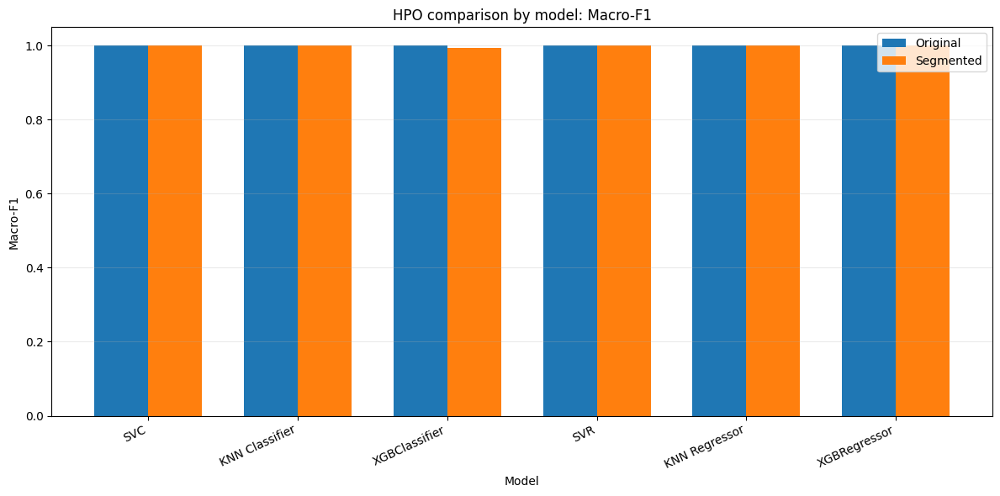

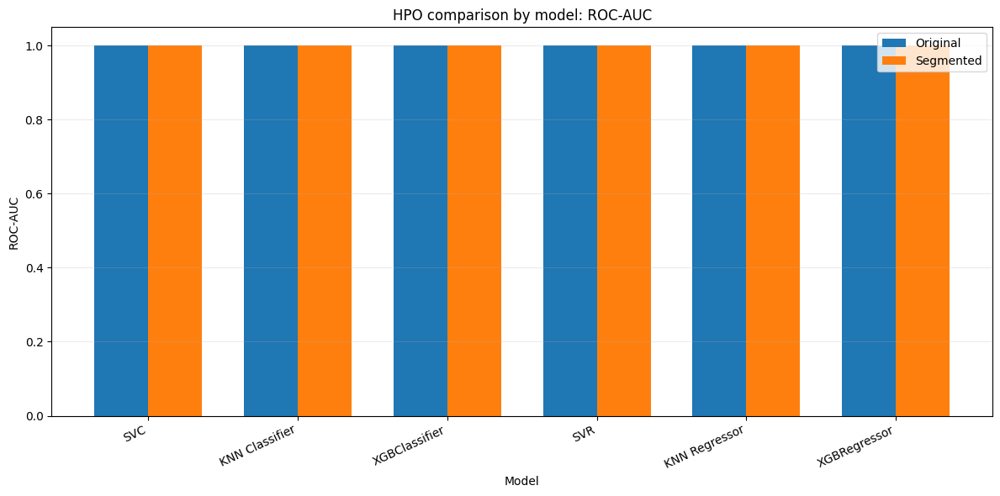

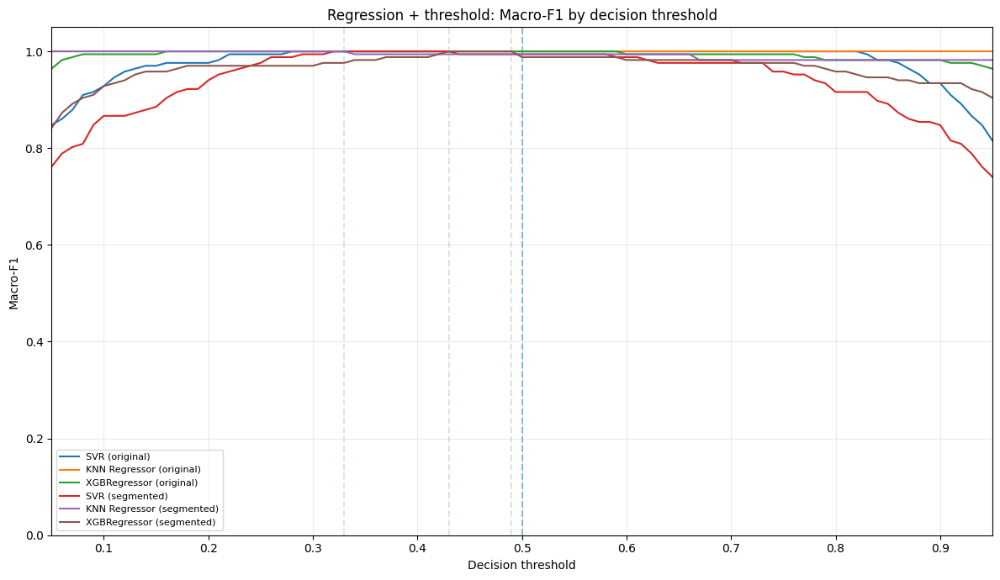

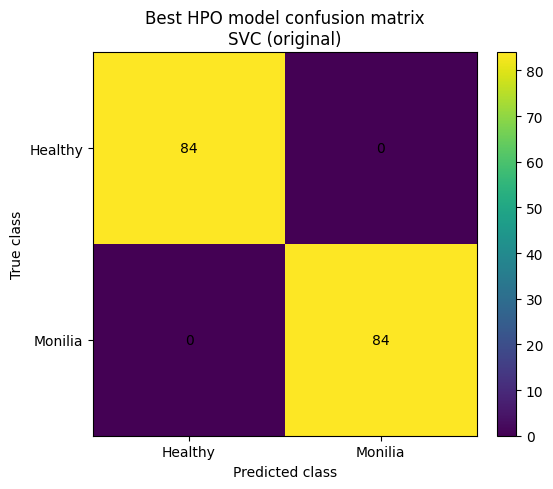


[OK] HPO completed for all 12 branch-model combinations.
[OK] Direct classifiers evaluated:
     SVC, KNN Classifier, XGBClassifier
[OK] Regression + threshold evaluated:
     SVR, KNN Regressor, XGBRegressor
[OK] Summary saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/hybrid_hpo/hybrid_hpo_summary.csv
[OK] Figures saved in:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/hybrid_hpo/figures

[OK] Locked test remains untouched.


In [ ]:
# ============================================================
# HYBRID MODEL HYPERPARAMETER OPTIMIZATION
# ORIGINAL vs. SEGMENTED
#
# Direct classification:
#   1. SVC
#   2. KNeighborsClassifier
#   3. XGBClassifier
#
# Regression + threshold:
#   4. SVR
#   5. KNeighborsRegressor
#   6. XGBRegressor
#
# Training set : 1180
# HPO set      : 168
# Locked test  : NOT LOADED
#
# Primary HPO metric:
#   Macro F1-score
#
# IMPORTANT:
# - Regression outputs are continuous scores, NOT calibrated probabilities.
# - The decision threshold for regressors is selected ONLY on the HPO set.
# - The locked test is never loaded in this stage.
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import gc
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC, SVR
from sklearn.neighbors import (
    KNeighborsClassifier,
    KNeighborsRegressor,
)

from sklearn.model_selection import ParameterSampler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)

from xgboost import XGBClassifier, XGBRegressor


# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

RANDOM_STATE = 42

# Threshold candidates used ONLY for regression -> class conversion.
# A fixed grid makes the search reproducible.
THRESHOLD_GRID = np.round(
    np.arange(0.05, 0.951, 0.01),
    2
)

print("=" * 80)
print("HYBRID HYPERPARAMETER OPTIMIZATION")
print("DIRECT CLASSIFICATION vs. REGRESSION + THRESHOLD")
print("=" * 80)


# ============================================================
# 2. PROJECT PATHS
# ============================================================

ejecucion = (
    "/content/drive/MyDrive/"
    "Articulo_DiegoR/articulo"
)

features_directory = os.path.join(
    ejecucion,
    "features"
)

# New folder so the previous classifier-only HPO results are preserved.
hpo_results_directory = os.path.join(
    ejecucion,
    "results",
    "hybrid_hpo"
)

figures_directory = os.path.join(
    hpo_results_directory,
    "figures"
)

os.makedirs(
    hpo_results_directory,
    exist_ok=True
)

os.makedirs(
    figures_directory,
    exist_ok=True
)


# ============================================================
# 3. RELEASE PREVIOUS LARGE OBJECTS FROM MEMORY
# ============================================================

variables_to_remove = [
    "X_original",
    "X_segmented",
    "X_original_train",
    "X_original_hpo",
    "X_original_test",
    "X_segmented_train",
    "X_segmented_hpo",
    "X_segmented_test",
    "original_final",
    "segmented_final",
]

for variable_name in variables_to_remove:
    if variable_name in globals():
        globals().pop(
            variable_name,
            None
        )

gc.collect()


# ============================================================
# 4. LOAD ONLY TRAIN AND HPO FEATURES
#
# IMPORTANT:
# Locked test files are deliberately NOT loaded here.
# ============================================================

X_original_train = np.load(
    os.path.join(
        features_directory,
        "X_original_train.npy"
    )
)

X_original_hpo = np.load(
    os.path.join(
        features_directory,
        "X_original_hpo.npy"
    )
)

X_segmented_train = np.load(
    os.path.join(
        features_directory,
        "X_segmented_train.npy"
    )
)

X_segmented_hpo = np.load(
    os.path.join(
        features_directory,
        "X_segmented_hpo.npy"
    )
)

y_train = np.load(
    os.path.join(
        features_directory,
        "y_train.npy"
    )
)

y_hpo = np.load(
    os.path.join(
        features_directory,
        "y_hpo.npy"
    )
)


# ============================================================
# 5. VERIFY MATRICES
# ============================================================

assert X_original_train.shape == (1180, 1280)
assert X_original_hpo.shape == (168, 1280)
assert X_segmented_train.shape == (1180, 1280)
assert X_segmented_hpo.shape == (168, 1280)

assert y_train.shape == (1180,)
assert y_hpo.shape == (168,)

assert np.isfinite(X_original_train).all()
assert np.isfinite(X_original_hpo).all()
assert np.isfinite(X_segmented_train).all()
assert np.isfinite(X_segmented_hpo).all()

assert set(np.unique(y_train)).issubset({0, 1})
assert set(np.unique(y_hpo)).issubset({0, 1})

print("\nTraining labels:")
print(
    dict(
        zip(
            *np.unique(
                y_train,
                return_counts=True
            )
        )
    )
)

print("\nHPO labels:")
print(
    dict(
        zip(
            *np.unique(
                y_hpo,
                return_counts=True
            )
        )
    )
)

print("\n[OK] Train and HPO matrices verified.")
print("[OK] Locked test has NOT been loaded.")


# ============================================================
# 6. CLASSIFICATION EVALUATION FUNCTION
#
# Label interpretation:
#   0 = Healthy
#   1 = Monilia
# ============================================================

def calculate_classification_metrics(
    y_true,
    y_pred,
    y_score
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    metrics = {
        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "recall_sensitivity":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "specificity":
            specificity,

        "f1_monilia":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "f1_macro":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        # Raw continuous scores are valid for ranking-based ROC-AUC.
        # For regressors, this does NOT imply calibrated probability.
        "roc_auc":
            roc_auc_score(
                y_true,
                y_score
            ),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    return metrics


# ============================================================
# 7. GET CONTINUOUS SCORE FOR CLASSIFIERS
# ============================================================

def get_classifier_score(
    model,
    X
):
    if hasattr(
        model,
        "predict_proba"
    ):
        probabilities = model.predict_proba(X)

        return probabilities[:, 1]

    if hasattr(
        model,
        "decision_function"
    ):
        return model.decision_function(X)

    raise ValueError(
        "Classifier does not provide "
        "predict_proba or decision_function."
    )


# ============================================================
# 8. THRESHOLD SELECTION FOR REGRESSORS
#
# Primary criterion:
#   Macro F1
#
# Tie breakers:
#   MCC
#   Balanced accuracy
#   Threshold closest to 0.50
#
# IMPORTANT:
# The threshold is selected ONLY on HPO, never on test.
# ============================================================

def evaluate_thresholds(
    y_true,
    y_score,
    threshold_grid=THRESHOLD_GRID
):
    rows = []

    for threshold in threshold_grid:
        y_pred = (
            y_score >= threshold
        ).astype(int)

        metrics = (
            calculate_classification_metrics(
                y_true,
                y_pred,
                y_score
            )
        )

        rows.append(
            {
                "threshold":
                    float(threshold),

                "distance_to_0_5":
                    float(
                        abs(
                            threshold - 0.5
                        )
                    ),

                **metrics,
            }
        )

    threshold_df = pd.DataFrame(
        rows
    )

    ranked_thresholds = (
        threshold_df
        .sort_values(
            by=[
                "f1_macro",
                "mcc",
                "balanced_accuracy",
                "distance_to_0_5",
                "threshold",
            ],
            ascending=[
                False,
                False,
                False,
                True,
                True,
            ],
            kind="mergesort"
        )
        .reset_index(
            drop=True
        )
    )

    best_threshold = float(
        ranked_thresholds.iloc[0][
            "threshold"
        ]
    )

    return (
        best_threshold,
        threshold_df
    )


# ============================================================
# 9. SEARCH SPACES - DIRECT CLASSIFIERS
# ============================================================

# ------------------------------
# 9.1 SVC
# ------------------------------

svc_candidates = []

for C in [
    0.1,
    1.0,
    10.0,
    100.0,
]:
    svc_candidates.append(
        {
            "kernel": "linear",
            "C": C,
        }
    )

for C in [
    0.1,
    1.0,
    10.0,
    100.0,
]:
    for gamma in [
        "scale",
        0.001,
        0.01,
        0.1,
    ]:
        svc_candidates.append(
            {
                "kernel": "rbf",
                "C": C,
                "gamma": gamma,
            }
        )


# ------------------------------
# 9.2 KNN CLASSIFIER
# ------------------------------

knn_classifier_candidates = []

for n_neighbors in [
    3,
    5,
    7,
    9,
    11,
    15,
    21,
]:
    for weights in [
        "uniform",
        "distance",
    ]:
        for p in [
            1,
            2,
        ]:
            knn_classifier_candidates.append(
                {
                    "n_neighbors":
                        n_neighbors,

                    "weights":
                        weights,

                    "p":
                        p,
                }
            )


# ------------------------------
# 9.3 XGBOOST CLASSIFIER
# ------------------------------

xgb_common_parameter_space = {
    "n_estimators": [
        150,
        300,
        500,
    ],

    "max_depth": [
        3,
        5,
        7,
    ],

    "learning_rate": [
        0.01,
        0.05,
        0.10,
    ],

    "subsample": [
        0.8,
        1.0,
    ],

    "colsample_bytree": [
        0.6,
        0.8,
        1.0,
    ],

    "min_child_weight": [
        1,
        3,
        5,
    ],

    "reg_lambda": [
        1.0,
        5.0,
        10.0,
    ],

    "reg_alpha": [
        0.0,
        0.1,
        0.5,
    ],
}

xgb_classifier_candidates = list(
    ParameterSampler(
        xgb_common_parameter_space,
        n_iter=24,
        random_state=RANDOM_STATE
    )
)


# ============================================================
# 10. SEARCH SPACES - REGRESSION + THRESHOLD
# ============================================================

# ------------------------------
# 10.1 SVR
#
# A reduced reproducible sample is used to keep runtime
# comparable to the other HPO searches.
# ------------------------------

all_svr_candidates = []

for C in [
    0.1,
    1.0,
    10.0,
    100.0,
]:
    for epsilon in [
        0.01,
        0.05,
        0.10,
    ]:
        all_svr_candidates.append(
            {
                "kernel": "linear",
                "C": C,
                "epsilon": epsilon,
            }
        )

for C in [
    0.1,
    1.0,
    10.0,
    100.0,
]:
    for gamma in [
        "scale",
        0.001,
        0.01,
        0.1,
    ]:
        for epsilon in [
            0.01,
            0.05,
            0.10,
        ]:
            all_svr_candidates.append(
                {
                    "kernel": "rbf",
                    "C": C,
                    "gamma": gamma,
                    "epsilon": epsilon,
                }
            )

svr_rng = np.random.default_rng(
    RANDOM_STATE
)

svr_indices = svr_rng.choice(
    len(all_svr_candidates),
    size=min(
        24,
        len(all_svr_candidates)
    ),
    replace=False
)

svr_candidates = [
    all_svr_candidates[index]
    for index in sorted(
        svr_indices.tolist()
    )
]


# ------------------------------
# 10.2 KNN REGRESSOR
# ------------------------------

knn_regressor_candidates = []

for n_neighbors in [
    3,
    5,
    7,
    9,
    11,
    15,
    21,
]:
    for weights in [
        "uniform",
        "distance",
    ]:
        for p in [
            1,
            2,
        ]:
            knn_regressor_candidates.append(
                {
                    "n_neighbors":
                        n_neighbors,

                    "weights":
                        weights,

                    "p":
                        p,
                }
            )


# ------------------------------
# 10.3 XGBOOST REGRESSOR
# ------------------------------

# Use exactly the same sampled hyperparameter combinations as
# XGBClassifier, changing only the learning objective.
xgb_regressor_candidates = [
    dict(candidate)
    for candidate in xgb_classifier_candidates
]


print("\nSearch-space sizes:")
print(
    "  SVC                  :",
    len(svc_candidates)
)
print(
    "  KNN Classifier       :",
    len(knn_classifier_candidates)
)
print(
    "  XGBClassifier        :",
    len(xgb_classifier_candidates)
)
print(
    "  SVR                  :",
    len(svr_candidates)
)
print(
    "  KNN Regressor        :",
    len(knn_regressor_candidates)
)
print(
    "  XGBRegressor         :",
    len(xgb_regressor_candidates)
)


# ============================================================
# 11. UNIFIED MODEL BUILDER
# ============================================================

def build_model(
    model_name,
    params
):
    if model_name == "svc":
        estimator = SVC(
            **params
        )

        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    estimator
                ),
            ]
        )

    if model_name == "knn_classifier":
        estimator = (
            KNeighborsClassifier(
                **params,
                n_jobs=-1
            )
        )

        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    estimator
                ),
            ]
        )

    if model_name == "xgb_classifier":
        return XGBClassifier(
            **params,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        )

    if model_name == "svr":
        estimator = SVR(
            **params
        )

        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    estimator
                ),
            ]
        )

    if model_name == "knn_regressor":
        estimator = (
            KNeighborsRegressor(
                **params,
                n_jobs=-1
            )
        )

        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    estimator
                ),
            ]
        )

    if model_name == "xgb_regressor":
        return XGBRegressor(
            **params,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        )

    raise ValueError(
        f"Unknown model: {model_name}"
    )


# ============================================================
# 12. EVALUATE ONE MODEL CONFIGURATION
# ============================================================

def evaluate_configuration(
    model,
    approach,
    X_hpo_branch
):
    if approach == "classification":
        y_pred = model.predict(
            X_hpo_branch
        )

        y_score = get_classifier_score(
            model,
            X_hpo_branch
        )

        metrics = (
            calculate_classification_metrics(
                y_hpo,
                y_pred,
                y_score
            )
        )

        return {
            "threshold":
                np.nan,

            "mae":
                np.nan,

            "rmse":
                np.nan,

            "y_pred":
                y_pred,

            "y_score":
                y_score,

            "threshold_curve":
                None,

            "metrics":
                metrics,
        }

    if approach == "regression_threshold":
        # Continuous output from the regressor.
        y_score = model.predict(
            X_hpo_branch
        )

        # Select threshold only on HPO.
        best_threshold, threshold_curve = (
            evaluate_thresholds(
                y_hpo,
                y_score
            )
        )

        y_pred = (
            y_score >= best_threshold
        ).astype(int)

        metrics = (
            calculate_classification_metrics(
                y_hpo,
                y_pred,
                y_score
            )
        )

        mae = mean_absolute_error(
            y_hpo,
            y_score
        )

        rmse = float(
            np.sqrt(
                mean_squared_error(
                    y_hpo,
                    y_score
                )
            )
        )

        return {
            "threshold":
                float(best_threshold),

            "mae":
                float(mae),

            "rmse":
                float(rmse),

            "y_pred":
                y_pred,

            "y_score":
                y_score,

            "threshold_curve":
                threshold_curve,

            "metrics":
                metrics,
        }

    raise ValueError(
        f"Unknown approach: {approach}"
    )


# ============================================================
# 13. RESUMABLE HPO FUNCTION
# ============================================================

def run_model_hpo(
    branch_name,
    model_name,
    approach,
    X_train_branch,
    X_hpo_branch,
    candidates
):
    print(
        "\n"
        + "=" * 80
    )

    print(
        f"HPO: {branch_name.upper()} "
        f"+ {model_name.upper()} "
        f"[{approach}]"
    )

    print(
        "=" * 80
    )

    checkpoint_path = os.path.join(
        hpo_results_directory,
        (
            f"hpo_"
            f"{branch_name}_"
            f"{model_name}.csv"
        )
    )

    best_config_path = os.path.join(
        hpo_results_directory,
        (
            f"best_"
            f"{branch_name}_"
            f"{model_name}.json"
        )
    )

    threshold_curve_path = os.path.join(
        hpo_results_directory,
        (
            f"threshold_curve_"
            f"{branch_name}_"
            f"{model_name}.csv"
        )
    )

    if os.path.isfile(
        checkpoint_path
    ):
        results_df = pd.read_csv(
            checkpoint_path
        )

        completed_params = set(
            results_df[
                "params_json"
            ].astype(str)
        )

        print(
            f"[RESUME] "
            f"{len(results_df)} "
            f"configuration(s) "
            f"already completed."
        )

    else:
        results_df = pd.DataFrame()

        completed_params = set()

        print(
            "[NEW SEARCH] "
            "No previous checkpoint."
        )

    total_candidates = len(
        candidates
    )

    for candidate_number, params in enumerate(
        candidates,
        start=1
    ):
        params_json = json.dumps(
            params,
            sort_keys=True
        )

        if params_json in completed_params:
            print(
                f"[{candidate_number}/"
                f"{total_candidates}] "
                f"already completed."
            )

            continue

        print(
            f"\n[{candidate_number}/"
            f"{total_candidates}] "
            f"{params}"
        )

        model = build_model(
            model_name,
            params
        )

        start_time = (
            time.perf_counter()
        )

        model.fit(
            X_train_branch,
            y_train
        )

        training_seconds = (
            time.perf_counter()
            -
            start_time
        )

        evaluation = (
            evaluate_configuration(
                model,
                approach,
                X_hpo_branch
            )
        )

        metrics = evaluation[
            "metrics"
        ]

        if approach == "regression_threshold":
            print(
                f"    Threshold="
                f"{evaluation['threshold']:.2f} | "
                f"Macro-F1="
                f"{metrics['f1_macro']:.4f} | "
                f"MCC="
                f"{metrics['mcc']:.4f} | "
                f"AUC="
                f"{metrics['roc_auc']:.4f} | "
                f"RMSE="
                f"{evaluation['rmse']:.4f}"
            )

        else:
            print(
                f"    Macro-F1="
                f"{metrics['f1_macro']:.4f} | "
                f"MCC="
                f"{metrics['mcc']:.4f} | "
                f"AUC="
                f"{metrics['roc_auc']:.4f} | "
                f"Acc="
                f"{metrics['accuracy']:.4f}"
            )

        record = {
            "branch":
                branch_name,

            "approach":
                approach,

            "model":
                model_name,

            "candidate":
                candidate_number,

            "params_json":
                params_json,

            "threshold":
                evaluation[
                    "threshold"
                ],

            "mae":
                evaluation[
                    "mae"
                ],

            "rmse":
                evaluation[
                    "rmse"
                ],

            "training_seconds":
                float(
                    training_seconds
                ),

            **metrics,
        }

        if os.path.isfile(
            checkpoint_path
        ):
            results_df = pd.read_csv(
                checkpoint_path
            )

        else:
            results_df = pd.DataFrame()

        results_df = pd.concat(
            [
                results_df,
                pd.DataFrame(
                    [record]
                ),
            ],
            ignore_index=True
        )

        results_df = (
            results_df
            .drop_duplicates(
                subset=[
                    "params_json"
                ],
                keep="last"
            )
            .sort_values(
                "candidate"
            )
            .reset_index(
                drop=True
            )
        )

        results_df.to_csv(
            checkpoint_path,
            index=False
        )

        completed_params.add(
            params_json
        )

        print(
            "    [CHECKPOINT SAVED]"
        )

        del model
        gc.collect()

    # ========================================================
    # VERIFY COMPLETE SEARCH
    # ========================================================

    results_df = pd.read_csv(
        checkpoint_path
    )

    assert len(
        results_df
    ) == total_candidates, (
        f"{branch_name} + "
        f"{model_name}: "
        f"expected "
        f"{total_candidates} results, "
        f"found {len(results_df)}."
    )

    # ========================================================
    # SELECT BEST HPO CONFIGURATION
    #
    # Primary:
    #   Macro F1
    #
    # Tie breakers:
    #   MCC
    #   ROC-AUC
    #   Balanced accuracy
    #   Accuracy
    #
    # Test is NOT involved.
    # ========================================================

    ranked_df = (
        results_df
        .sort_values(
            by=[
                "f1_macro",
                "mcc",
                "roc_auc",
                "balanced_accuracy",
                "accuracy",
                "candidate",
            ],
            ascending=[
                False,
                False,
                False,
                False,
                False,
                True,
            ],
            kind="mergesort"
        )
        .reset_index(
            drop=True
        )
    )

    best_row = ranked_df.iloc[0]

    best_params = json.loads(
        best_row[
            "params_json"
        ]
    )

    best_threshold = (
        None
        if pd.isna(
            best_row[
                "threshold"
            ]
        )
        else float(
            best_row[
                "threshold"
            ]
        )
    )

    best_result = {
        "branch":
            branch_name,

        "approach":
            approach,

        "model":
            model_name,

        "selection_metric":
            "f1_macro",

        "best_params":
            best_params,

        "decision_threshold":
            best_threshold,

        "regression_diagnostics": {
            "mae":
                (
                    None
                    if pd.isna(
                        best_row["mae"]
                    )
                    else float(
                        best_row["mae"]
                    )
                ),

            "rmse":
                (
                    None
                    if pd.isna(
                        best_row["rmse"]
                    )
                    else float(
                        best_row["rmse"]
                    )
                ),
        },

        "hpo_metrics": {
            "accuracy":
                float(
                    best_row[
                        "accuracy"
                    ]
                ),

            "balanced_accuracy":
                float(
                    best_row[
                        "balanced_accuracy"
                    ]
                ),

            "precision":
                float(
                    best_row[
                        "precision"
                    ]
                ),

            "recall_sensitivity":
                float(
                    best_row[
                        "recall_sensitivity"
                    ]
                ),

            "specificity":
                float(
                    best_row[
                        "specificity"
                    ]
                ),

            "f1_monilia":
                float(
                    best_row[
                        "f1_monilia"
                    ]
                ),

            "f1_macro":
                float(
                    best_row[
                        "f1_macro"
                    ]
                ),

            "mcc":
                float(
                    best_row[
                        "mcc"
                    ]
                ),

            "roc_auc":
                float(
                    best_row[
                        "roc_auc"
                    ]
                ),

            "tn":
                int(
                    best_row[
                        "tn"
                    ]
                ),

            "fp":
                int(
                    best_row[
                        "fp"
                    ]
                ),

            "fn":
                int(
                    best_row[
                        "fn"
                    ]
                ),

            "tp":
                int(
                    best_row[
                        "tp"
                    ]
                ),
        },
    }

    with open(
        best_config_path,
        "w"
    ) as f:
        json.dump(
            best_result,
            f,
            indent=4
        )

    # --------------------------------------------------------
    # Refit ONLY the selected configuration to create the
    # threshold curve for the selected regressor.
    # This still uses only TRAIN -> HPO.
    # --------------------------------------------------------

    if approach == "regression_threshold":
        best_model = build_model(
            model_name,
            best_params
        )

        best_model.fit(
            X_train_branch,
            y_train
        )

        best_y_score = best_model.predict(
            X_hpo_branch
        )

        _, threshold_curve = (
            evaluate_thresholds(
                y_hpo,
                best_y_score
            )
        )

        threshold_curve.to_csv(
            threshold_curve_path,
            index=False
        )

        del best_model
        gc.collect()

    print(
        "\nBEST HPO CONFIGURATION"
    )

    print(
        "Parameters:",
        best_params
    )

    if best_threshold is not None:
        print(
            f"Threshold : "
            f"{best_threshold:.2f}"
        )

    print(
        f"Macro-F1  : "
        f"{best_row['f1_macro']:.4f}"
    )

    print(
        f"MCC       : "
        f"{best_row['mcc']:.4f}"
    )

    print(
        f"ROC-AUC   : "
        f"{best_row['roc_auc']:.4f}"
    )

    print(
        f"Accuracy  : "
        f"{best_row['accuracy']:.4f}"
    )

    return (
        ranked_df,
        best_result
    )


# ============================================================
# 14. DEFINE BRANCHES AND SEARCHES
# ============================================================

branches = {
    "original": (
        X_original_train,
        X_original_hpo
    ),

    "segmented": (
        X_segmented_train,
        X_segmented_hpo
    ),
}

search_spaces = {
    "svc": {
        "approach":
            "classification",

        "candidates":
            svc_candidates,
    },

    "knn_classifier": {
        "approach":
            "classification",

        "candidates":
            knn_classifier_candidates,
    },

    "xgb_classifier": {
        "approach":
            "classification",

        "candidates":
            xgb_classifier_candidates,
    },

    "svr": {
        "approach":
            "regression_threshold",

        "candidates":
            svr_candidates,
    },

    "knn_regressor": {
        "approach":
            "regression_threshold",

        "candidates":
            knn_regressor_candidates,
    },

    "xgb_regressor": {
        "approach":
            "regression_threshold",

        "candidates":
            xgb_regressor_candidates,
    },
}


# ============================================================
# 15. RUN ALL 12 HPO EXPERIMENTS
#
# 2 feature branches x 6 models = 12 experiments
# ============================================================

all_best_results = []

for branch_name, (
    X_train_branch,
    X_hpo_branch
) in branches.items():

    for model_name, search_info in (
        search_spaces.items()
    ):
        ranked_df, best_result = (
            run_model_hpo(
                branch_name=
                    branch_name,

                model_name=
                    model_name,

                approach=
                    search_info[
                        "approach"
                    ],

                X_train_branch=
                    X_train_branch,

                X_hpo_branch=
                    X_hpo_branch,

                candidates=
                    search_info[
                        "candidates"
                    ],
            )
        )

        all_best_results.append(
            best_result
        )


# ============================================================
# 16. CREATE HPO SUMMARY
# ============================================================

summary_records = []

for result in all_best_results:
    metrics = result[
        "hpo_metrics"
    ]

    diagnostics = result[
        "regression_diagnostics"
    ]

    summary_records.append(
        {
            "branch":
                result[
                    "branch"
                ],

            "approach":
                result[
                    "approach"
                ],

            "model":
                result[
                    "model"
                ],

            "threshold":
                result[
                    "decision_threshold"
                ],

            "f1_macro":
                metrics[
                    "f1_macro"
                ],

            "f1_monilia":
                metrics[
                    "f1_monilia"
                ],

            "mcc":
                metrics[
                    "mcc"
                ],

            "roc_auc":
                metrics[
                    "roc_auc"
                ],

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "balanced_accuracy":
                metrics[
                    "balanced_accuracy"
                ],

            "sensitivity":
                metrics[
                    "recall_sensitivity"
                ],

            "specificity":
                metrics[
                    "specificity"
                ],

            "precision":
                metrics[
                    "precision"
                ],

            "mae":
                diagnostics[
                    "mae"
                ],

            "rmse":
                diagnostics[
                    "rmse"
                ],

            "best_params":
                json.dumps(
                    result[
                        "best_params"
                    ],
                    sort_keys=True
                ),
        }
    )

hpo_summary_df = pd.DataFrame(
    summary_records
)

hpo_summary_path = os.path.join(
    hpo_results_directory,
    "hybrid_hpo_summary.csv"
)

hpo_summary_df.to_csv(
    hpo_summary_path,
    index=False
)


# ============================================================
# 17. DISPLAY HPO RESULTS
# ============================================================

print("\n" + "=" * 80)
print("HYBRID HPO SUMMARY")
print("=" * 80)

display_columns = [
    "branch",
    "approach",
    "model",
    "threshold",
    "f1_macro",
    "mcc",
    "roc_auc",
    "accuracy",
    "sensitivity",
    "specificity",
    "precision",
    "mae",
    "rmse",
]

display(
    hpo_summary_df[
        display_columns
    ]
    .sort_values(
        by=[
            "f1_macro",
            "mcc",
        ],
        ascending=[
            False,
            False,
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 18. VISUALIZATION 1
# MACRO-F1: ORIGINAL vs. SEGMENTED FOR ALL MODELS
# ============================================================

model_order = [
    "svc",
    "knn_classifier",
    "xgb_classifier",
    "svr",
    "knn_regressor",
    "xgb_regressor",
]

model_labels = {
    "svc":
        "SVC",

    "knn_classifier":
        "KNN Classifier",

    "xgb_classifier":
        "XGBClassifier",

    "svr":
        "SVR",

    "knn_regressor":
        "KNN Regressor",

    "xgb_regressor":
        "XGBRegressor",
}

f1_pivot = (
    hpo_summary_df
    .pivot(
        index="model",
        columns="branch",
        values="f1_macro"
    )
    .reindex(
        model_order
    )
)

x = np.arange(
    len(model_order)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.bar(
    x - width / 2,
    f1_pivot["original"].values,
    width,
    label="Original"
)

ax.bar(
    x + width / 2,
    f1_pivot["segmented"].values,
    width,
    label="Segmented"
)

ax.set_title(
    "HPO comparison by model: Macro-F1"
)

ax.set_xlabel(
    "Model"
)

ax.set_ylabel(
    "Macro-F1"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        model_labels[
            model
        ]
        for model in model_order
    ],
    rotation=25,
    ha="right"
)

ax.set_ylim(
    0.0,
    1.05
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

f1_plot_path = os.path.join(
    figures_directory,
    "hpo_macro_f1_comparison.png"
)

fig.savefig(
    f1_plot_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. VISUALIZATION 2
# ROC-AUC: ORIGINAL vs. SEGMENTED FOR ALL MODELS
# ============================================================

auc_pivot = (
    hpo_summary_df
    .pivot(
        index="model",
        columns="branch",
        values="roc_auc"
    )
    .reindex(
        model_order
    )
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.bar(
    x - width / 2,
    auc_pivot["original"].values,
    width,
    label="Original"
)

ax.bar(
    x + width / 2,
    auc_pivot["segmented"].values,
    width,
    label="Segmented"
)

ax.set_title(
    "HPO comparison by model: ROC-AUC"
)

ax.set_xlabel(
    "Model"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        model_labels[
            model
        ]
        for model in model_order
    ],
    rotation=25,
    ha="right"
)

ax.set_ylim(
    0.0,
    1.05
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

auc_plot_path = os.path.join(
    figures_directory,
    "hpo_roc_auc_comparison.png"
)

fig.savefig(
    auc_plot_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. VISUALIZATION 3
# THRESHOLD CURVES FOR THE BEST REGRESSION CONFIGURATIONS
#
# Each line shows how Macro-F1 changes as the threshold moves.
# This makes the regression -> classification step visible.
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

regression_rows = (
    hpo_summary_df[
        hpo_summary_df[
            "approach"
        ] == "regression_threshold"
    ]
    .copy()
)

for _, row in regression_rows.iterrows():
    threshold_curve_path = os.path.join(
        hpo_results_directory,
        (
            f"threshold_curve_"
            f"{row['branch']}_"
            f"{row['model']}.csv"
        )
    )

    if not os.path.isfile(
        threshold_curve_path
    ):
        continue

    threshold_curve_df = pd.read_csv(
        threshold_curve_path
    )

    label = (
        f"{model_labels[row['model']]} "
        f"({row['branch']})"
    )

    ax.plot(
        threshold_curve_df[
            "threshold"
        ],
        threshold_curve_df[
            "f1_macro"
        ],
        label=label
    )

    if pd.notna(
        row["threshold"]
    ):
        ax.axvline(
            float(
                row["threshold"]
            ),
            linestyle="--",
            alpha=0.18
        )

ax.set_title(
    "Regression + threshold: Macro-F1 by decision threshold"
)

ax.set_xlabel(
    "Decision threshold"
)

ax.set_ylabel(
    "Macro-F1"
)

ax.set_xlim(
    THRESHOLD_GRID.min(),
    THRESHOLD_GRID.max()
)

ax.set_ylim(
    0.0,
    1.05
)

ax.grid(
    alpha=0.25
)

ax.legend(
    fontsize=8
)

fig.tight_layout()

threshold_plot_path = os.path.join(
    figures_directory,
    "regression_threshold_curves.png"
)

fig.savefig(
    threshold_plot_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. VISUALIZATION 4
# CONFUSION MATRIX OF THE OVERALL BEST HPO MODEL
#
# IMPORTANT:
# This matrix is from the HPO set, NOT the locked test.
# ============================================================

best_overall_row = (
    hpo_summary_df
    .sort_values(
        by=[
            "f1_macro",
            "mcc",
            "roc_auc",
            "balanced_accuracy",
            "accuracy",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False,
        ],
        kind="mergesort"
    )
    .iloc[0]
)

best_branch = best_overall_row[
    "branch"
]

best_model_name = best_overall_row[
    "model"
]

best_approach = best_overall_row[
    "approach"
]

best_params = json.loads(
    best_overall_row[
        "best_params"
    ]
)

best_threshold = best_overall_row[
    "threshold"
]

best_X_train, best_X_hpo = (
    branches[
        best_branch
    ]
)

best_model = build_model(
    best_model_name,
    best_params
)

best_model.fit(
    best_X_train,
    y_train
)

if best_approach == "classification":
    best_y_pred = best_model.predict(
        best_X_hpo
    )

else:
    best_y_score = best_model.predict(
        best_X_hpo
    )

    best_y_pred = (
        best_y_score
        >=
        float(
            best_threshold
        )
    ).astype(int)

best_cm = confusion_matrix(
    y_hpo,
    best_y_pred,
    labels=[0, 1]
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(
    best_cm
)

for row_index in range(
    best_cm.shape[0]
):
    for column_index in range(
        best_cm.shape[1]
    ):
        ax.text(
            column_index,
            row_index,
            str(
                best_cm[
                    row_index,
                    column_index
                ]
            ),
            ha="center",
            va="center"
        )

ax.set_title(
    (
        "Best HPO model confusion matrix\n"
        f"{model_labels[best_model_name]} "
        f"({best_branch})"
    )
)

ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)

ax.set_xticklabels(
    [
        "Healthy",
        "Monilia",
    ]
)

ax.set_yticklabels(
    [
        "Healthy",
        "Monilia",
    ]
)

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

fig.tight_layout()

cm_plot_path = os.path.join(
    figures_directory,
    "best_hpo_confusion_matrix.png"
)

fig.savefig(
    cm_plot_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

del best_model
gc.collect()


# ============================================================
# 22. FINAL STATUS
# ============================================================

print(
    "\n[OK] HPO completed for all "
    "12 branch-model combinations."
)

print(
    "[OK] Direct classifiers evaluated:"
)

print(
    "     SVC, KNN Classifier, XGBClassifier"
)

print(
    "[OK] Regression + threshold evaluated:"
)

print(
    "     SVR, KNN Regressor, XGBRegressor"
)

print(
    "[OK] Summary saved:"
)

print(
    hpo_summary_path
)

print(
    "[OK] Figures saved in:"
)

print(
    figures_directory
)

print(
    "\n[OK] Locked test remains untouched."
)


##**9. Validación Cruzada**

10-FOLD STRATIFIED CROSS-VALIDATION
CLASSIFICATION vs. REGRESSION + FIXED THRESHOLD

Original features : (1180, 1280)
Segmented features: (1180, 1280)
Labels            : (1180,)

Class distribution: {0: 590, 1: 590}

[OK] Only the 1180 training samples were loaded.

ORIGINAL + SVC:
  approach  : classification
  params    : {'C': 0.1, 'kernel': 'linear'}

ORIGINAL + KNN Classifier:
  approach  : classification
  params    : {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}

ORIGINAL + XGBClassifier:
  approach  : classification
  params    : {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 500, 'reg_alpha': 0.5, 'reg_lambda': 5.0, 'subsample': 0.8}

ORIGINAL + SVR:
  approach  : regression_threshold
  params    : {'C': 1.0, 'epsilon': 0.01, 'kernel': 'linear'}
  threshold : 0.5

ORIGINAL + KNN Regressor:
  approach  : regression_threshold
  params    : {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
  threshold : 0.5

ORIGINAL + X

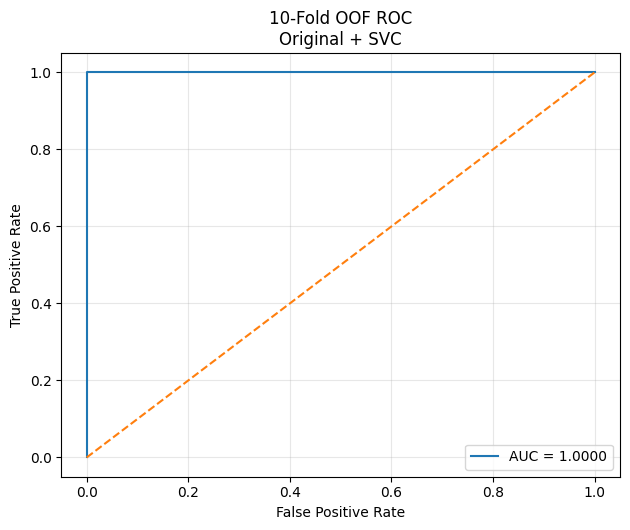

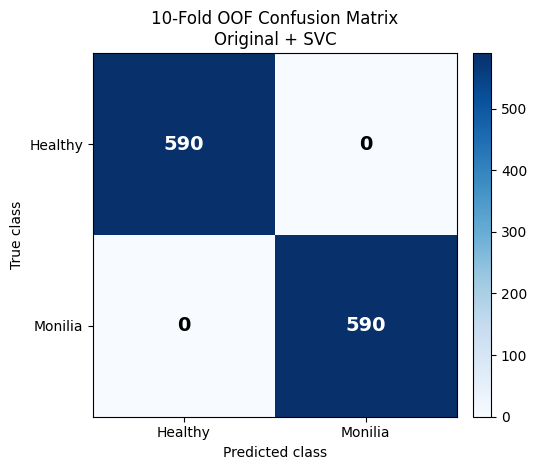


10-FOLD CV: ORIGINAL + KNN Classifier [classification]

Fold 1/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 4/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 5/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 6/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 7/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 8/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 9/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 10/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy    : 1.0000
Macro-F1    : 1.0000
P

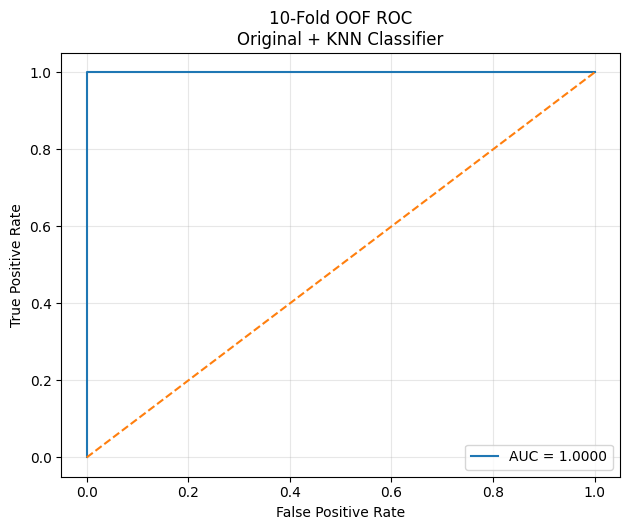

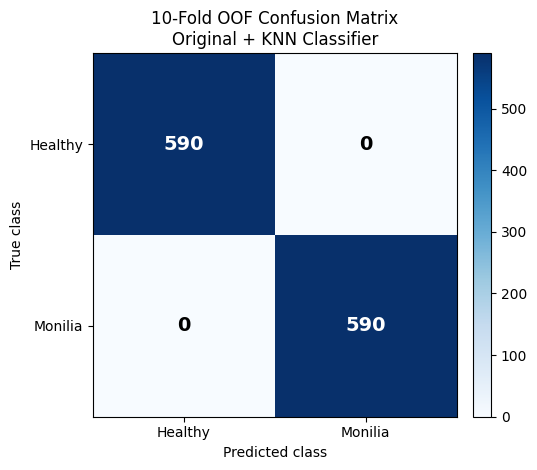


10-FOLD CV: ORIGINAL + XGBClassifier [classification]

Fold 1/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 4/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 5/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 6/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 7/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 8/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 9/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 10/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy    : 1.0000
Macro-F1    : 1.0000
Pr

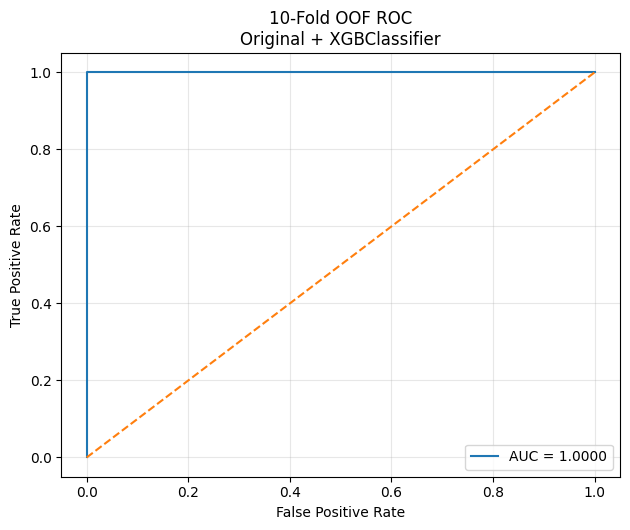

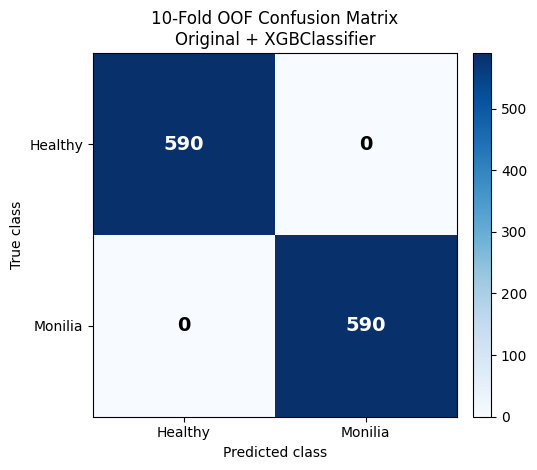


10-FOLD CV: ORIGINAL + SVR [regression_threshold]
Frozen HPO threshold: 0.5000

Fold 1/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 4/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 5/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 6/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 7/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 8/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 9/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 10/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy    : 1.000

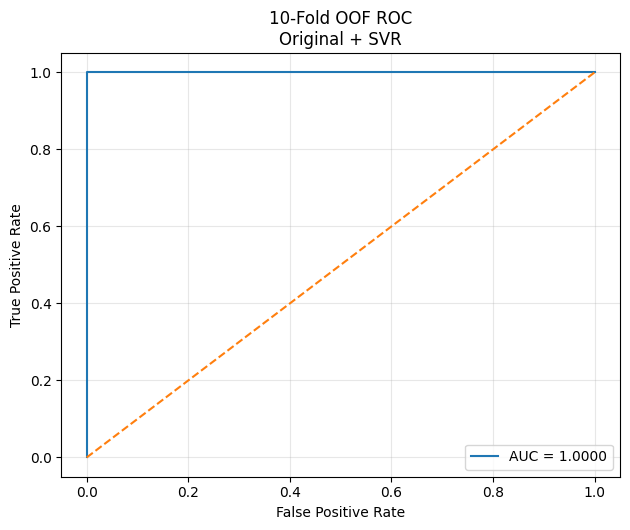

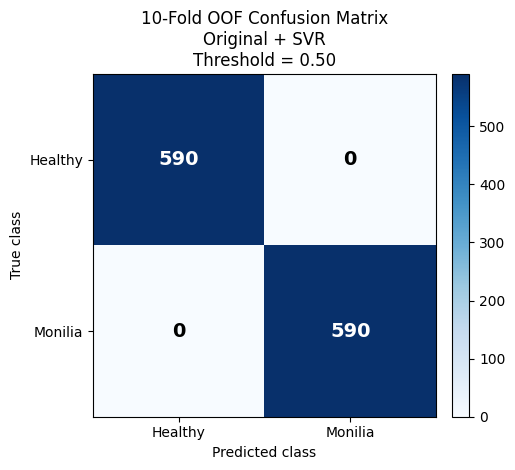


10-FOLD CV: ORIGINAL + KNN Regressor [regression_threshold]
Frozen HPO threshold: 0.5000

Fold 1/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 4/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 5/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 6/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 7/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 8/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 9/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 10/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy 

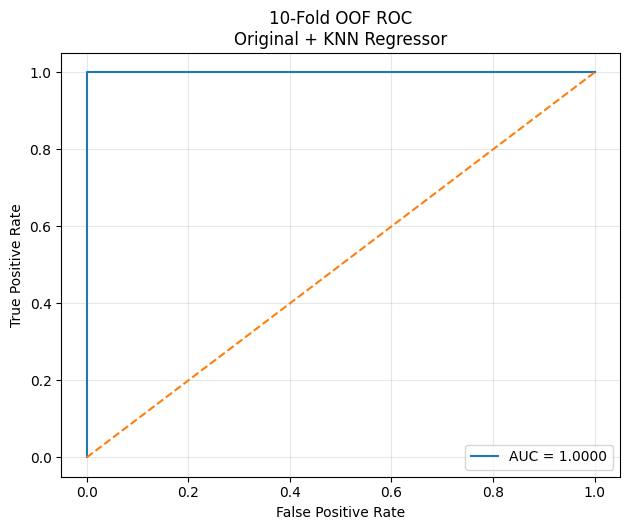

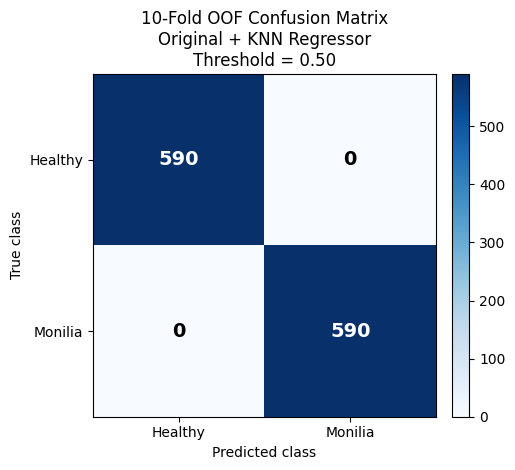


10-FOLD CV: ORIGINAL + XGBRegressor [regression_threshold]
Frozen HPO threshold: 0.5000

Fold 1/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 4/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 5/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 6/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 7/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 8/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 9/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 10/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy  

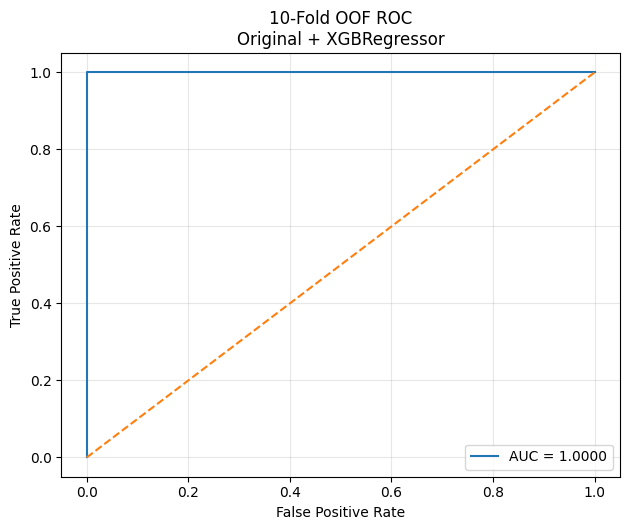

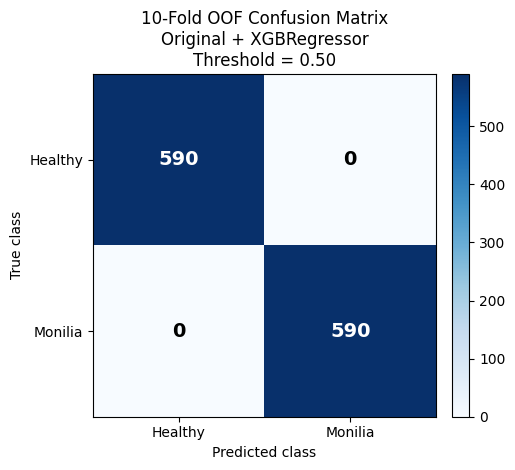


10-FOLD CV: SEGMENTED + SVC [classification]

Fold 1/10
    Accuracy=0.9831 | Macro-F1=0.9831 | MCC=0.9661 | AUC=0.9997

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 4/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 5/10
    Accuracy=0.9831 | Macro-F1=0.9831 | MCC=0.9661 | AUC=0.9994

Fold 6/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 7/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 8/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 9/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 10/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=1.0000

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy    : 0.9958
Macro-F1    : 0.9958
Precision  

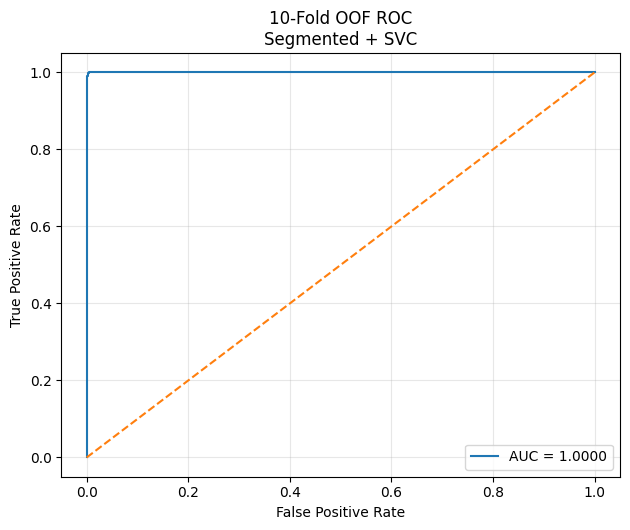

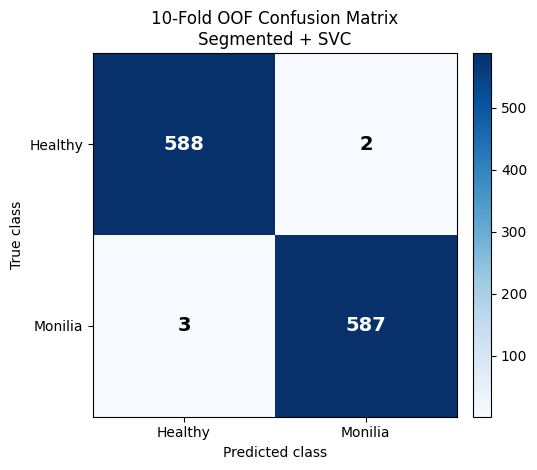


10-FOLD CV: SEGMENTED + KNN Classifier [classification]

Fold 1/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9914

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 4/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=1.0000

Fold 5/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9999

Fold 6/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 7/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 8/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 9/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 10/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=1.0000

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy    : 0.9966
Macro-F1    : 0.9966


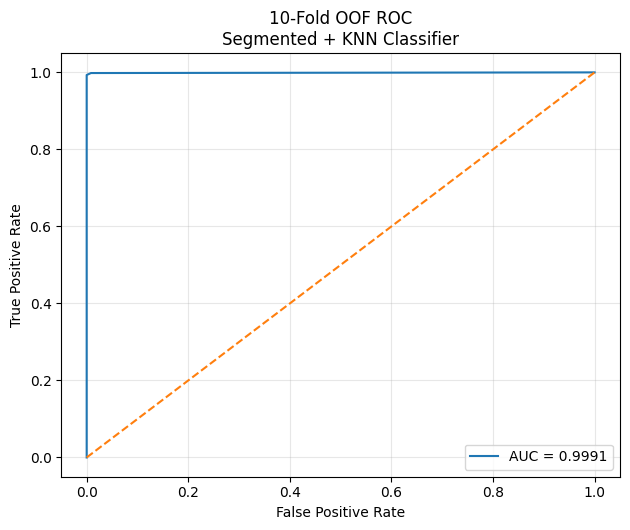

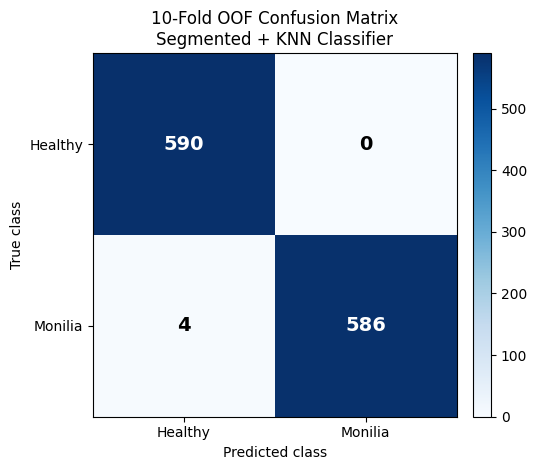


10-FOLD CV: SEGMENTED + XGBClassifier [classification]

Fold 1/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9989

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=0.9831 | Macro-F1=0.9830 | MCC=0.9667 | AUC=1.0000

Fold 4/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9989

Fold 5/10
    Accuracy=0.9831 | Macro-F1=0.9831 | MCC=0.9661 | AUC=0.9991

Fold 6/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 7/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 8/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=1.0000

Fold 9/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=1.0000

Fold 10/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy    : 0.9932
Macro-F1    : 0.9932
P

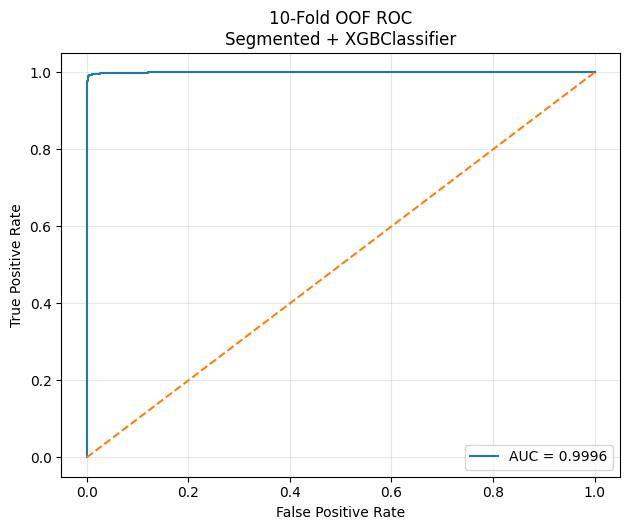

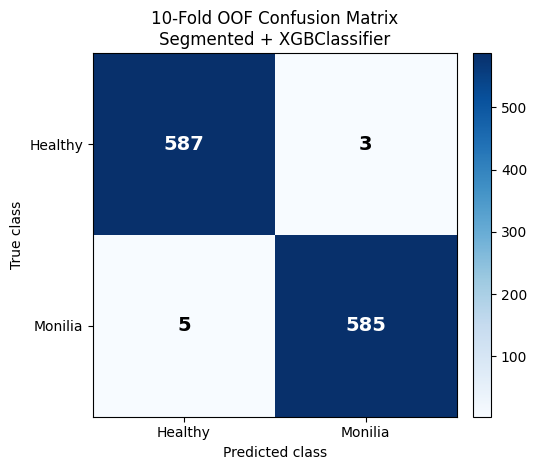


10-FOLD CV: SEGMENTED + SVR [regression_threshold]
Frozen HPO threshold: 0.4300

Fold 1/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9986

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 4/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=1.0000

Fold 5/10
    Accuracy=0.9831 | Macro-F1=0.9831 | MCC=0.9661 | AUC=0.9997

Fold 6/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=1.0000

Fold 7/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=1.0000

Fold 8/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 9/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 10/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9997

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy    : 0.99

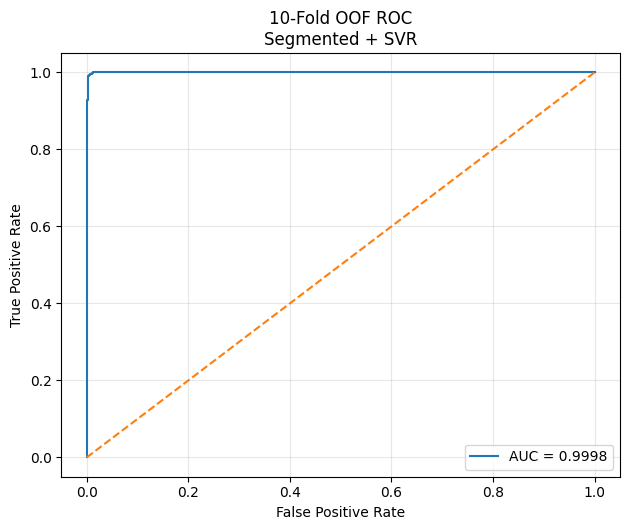

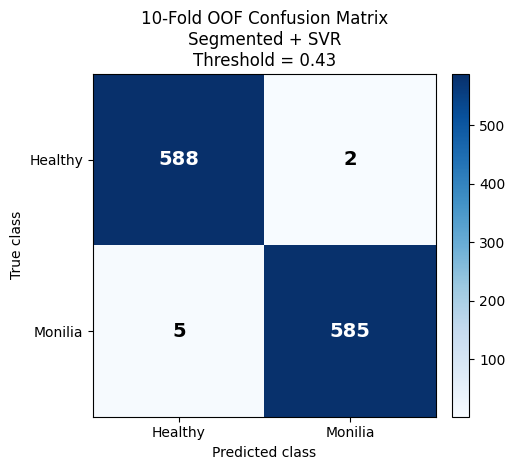


10-FOLD CV: SEGMENTED + KNN Regressor [regression_threshold]
Frozen HPO threshold: 0.3300

Fold 1/10
    Accuracy=0.9746 | Macro-F1=0.9746 | MCC=0.9493 | AUC=0.9912

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=1.0000

Fold 4/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9915

Fold 5/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9997

Fold 6/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 7/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 8/10
    Accuracy=0.9831 | Macro-F1=0.9830 | MCC=0.9667 | AUC=1.0000

Fold 9/10
    Accuracy=0.9831 | Macro-F1=0.9830 | MCC=0.9667 | AUC=1.0000

Fold 10/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy

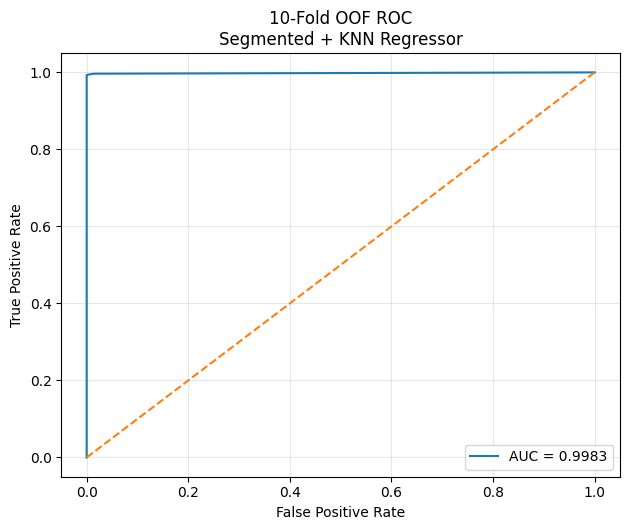

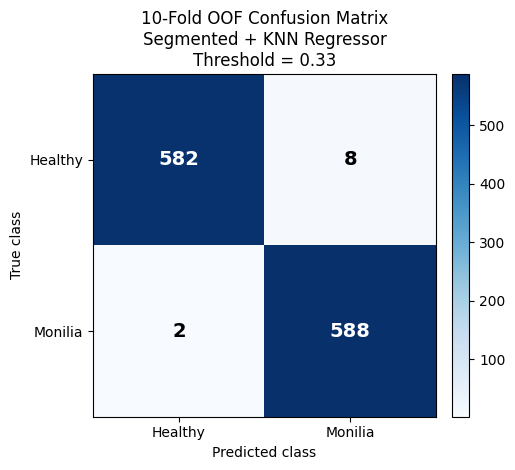


10-FOLD CV: SEGMENTED + XGBRegressor [regression_threshold]
Frozen HPO threshold: 0.4900

Fold 1/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9991

Fold 2/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 3/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9997

Fold 4/10
    Accuracy=0.9746 | Macro-F1=0.9746 | MCC=0.9504 | AUC=0.9986

Fold 5/10
    Accuracy=0.9831 | Macro-F1=0.9831 | MCC=0.9661 | AUC=0.9986

Fold 6/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 7/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

Fold 8/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=1.0000

Fold 9/10
    Accuracy=0.9915 | Macro-F1=0.9915 | MCC=0.9832 | AUC=0.9983

Fold 10/10
    Accuracy=1.0000 | Macro-F1=1.0000 | MCC=1.0000 | AUC=1.0000

------------------------------------------------------------
GLOBAL OUT-OF-FOLD RESULTS
------------------------------------------------------------
Accuracy 

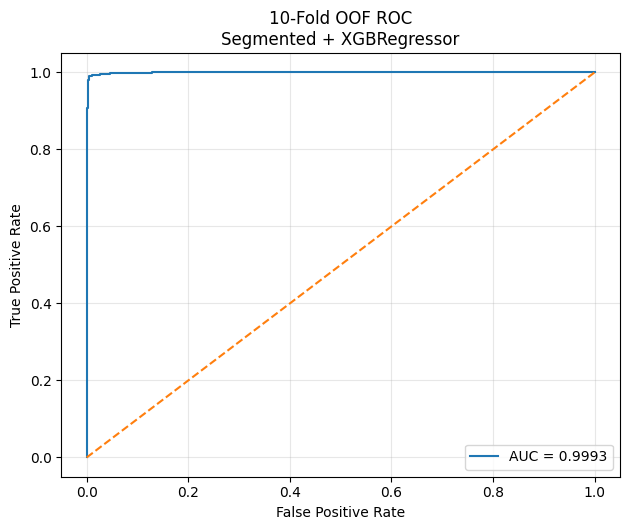

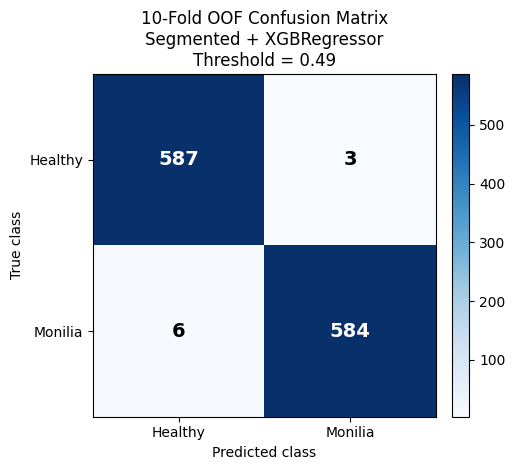


10-FOLD CROSS-VALIDATION SUMMARY


,branch,approach,model,threshold,accuracy_oof,precision_oof,sensitivity_oof,specificity_oof,f1_macro_oof,mcc_oof,roc_auc_oof,accuracy_mean,accuracy_sd,f1_macro_mean,f1_macro_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd
0,original,classification,svc,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
1,original,classification,knn_classifier,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
2,original,classification,xgb_classifier,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
3,original,regression_threshold,svr,0.50,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
4,original,regression_threshold,knn_regressor,0.50,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
5,original,regression_threshold,xgb_regressor,0.50,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
6,segmented,classification,svc,NaN,0.9958,0.9966,0.9949,0.9966,0.9958,0.9915,1.0000,0.9958,0.0072,0.9958,0.0072,0.9915,0.0144,0.9999,0.0002
7,segmented,classification,knn_classifier,NaN,0.9966,1.0000,0.9932,1.0000,0.9966,0.9932,0.9991,0.9966,0.0044,0.9966,0.0044,0.9933,0.0087,0.9991,0.0027
8,segmented,classification,xgb_classifier,NaN,0.9932,0.9949,0.9915,0.9949,0.9932,0.9864,0.9996,0.9932,0.0067,0.9932,0.0067,0.9866,0.0133,0.9997,0.0005
9,segmented,regression_threshold,svr,0.43,0.9941,0.9966,0.9915,0.9966,0.9941,0.9881,0.9998,0.9941,0.0057,0.9941,0.0057,0.9882,0.0114,0.9998,0.0005


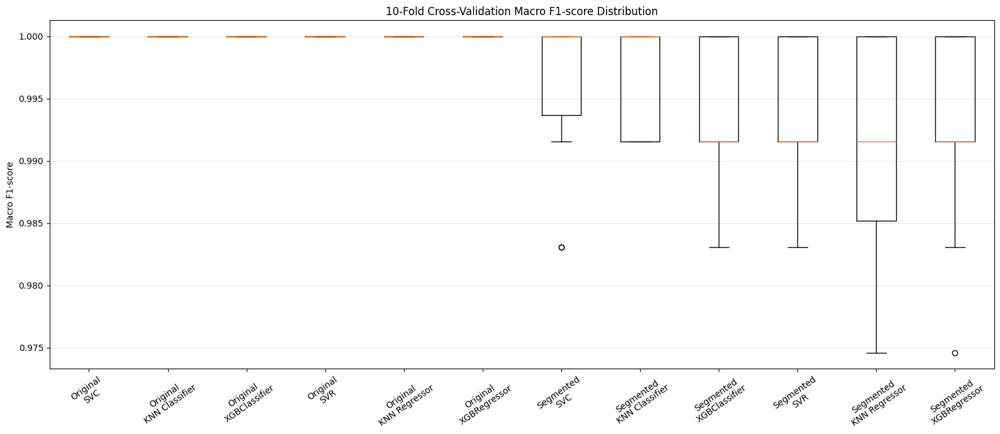

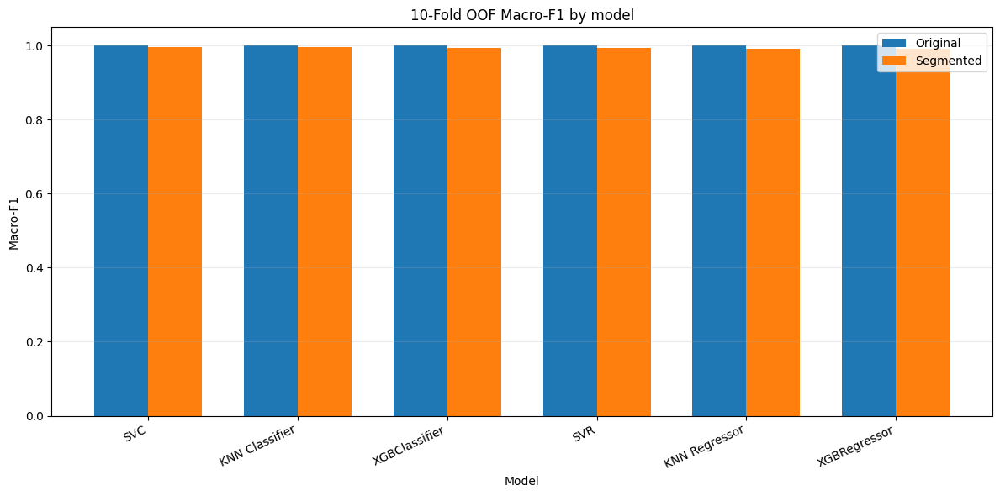

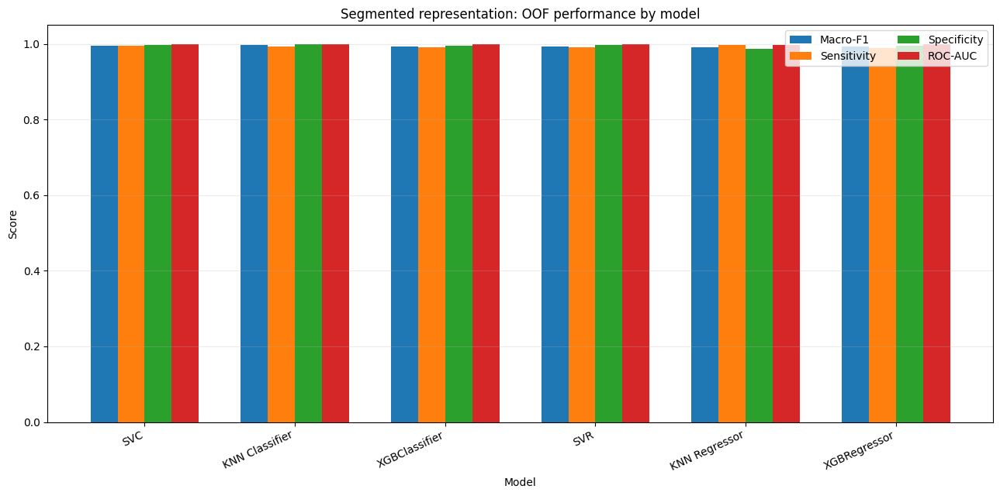

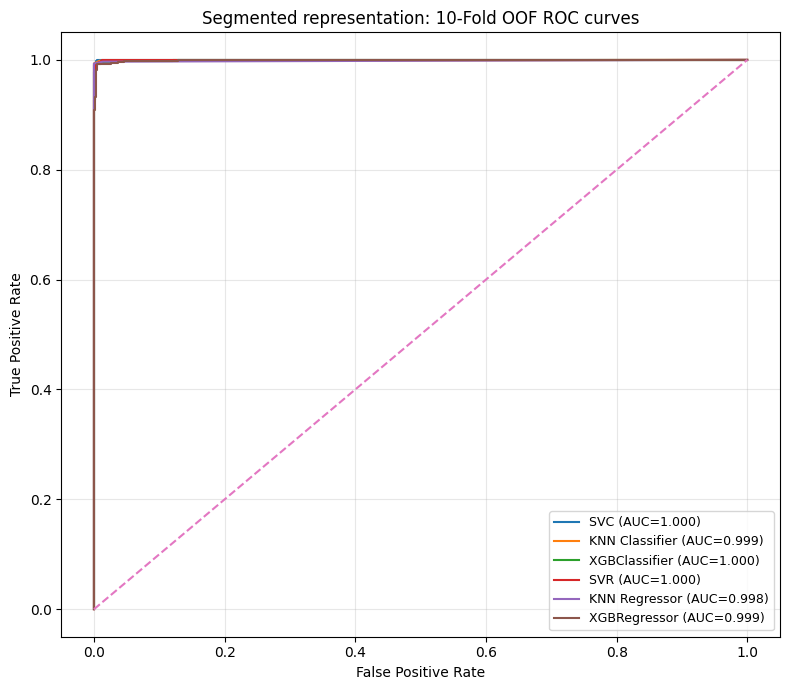

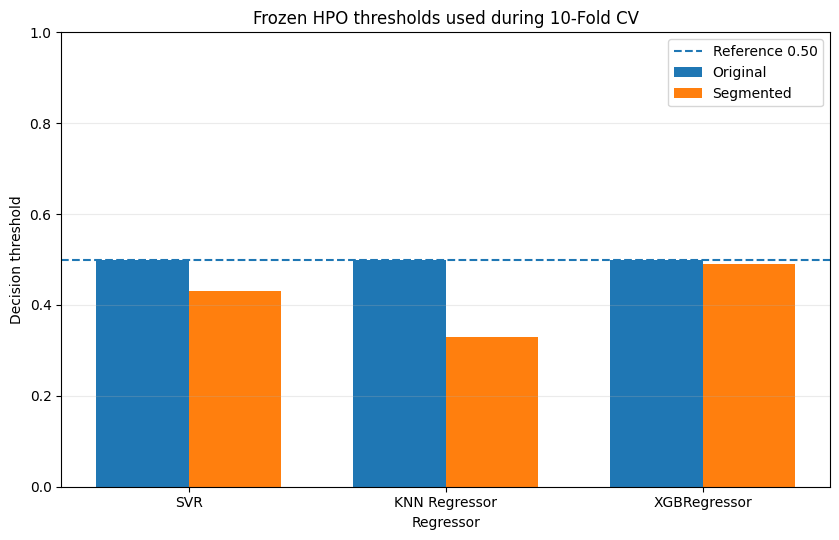


[OK] 10-fold stratified cross-validation completed.
[OK] Same folds were used for all 12 branch-model experiments.
[OK] HPO hyperparameters and regression thresholds remained fixed during CV.
[OK] HPO samples were not used as CV samples.
[OK] Locked test remains untouched.

Summary:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/cross_validation_summary.csv

Fold-level results:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/all_fold_metrics.csv

OOF predictions:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/oof_predictions

Figures:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures


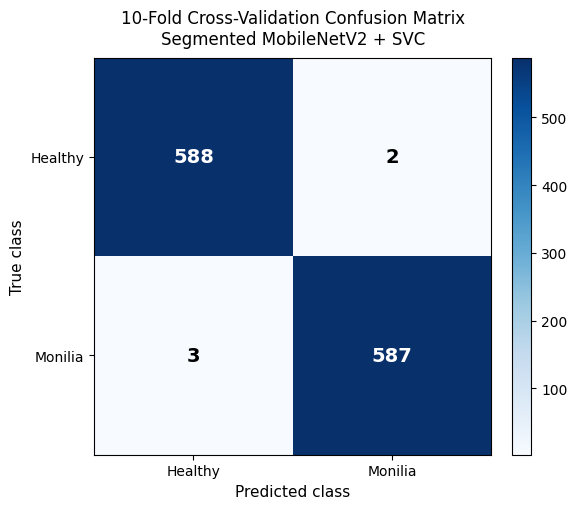

[OK] Saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures_segmented_blue/confusion_segmented_svc_blue.png


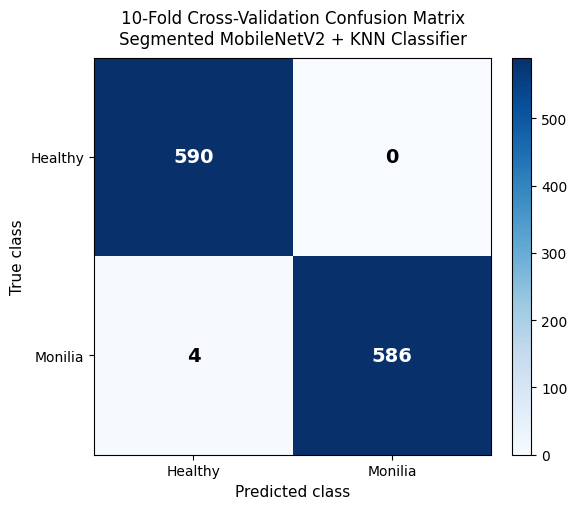

[OK] Saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures_segmented_blue/confusion_segmented_knn_classifier_blue.png


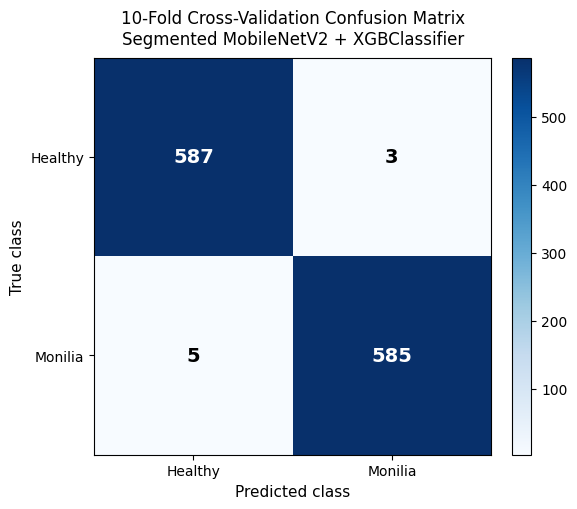

[OK] Saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures_segmented_blue/confusion_segmented_xgb_classifier_blue.png


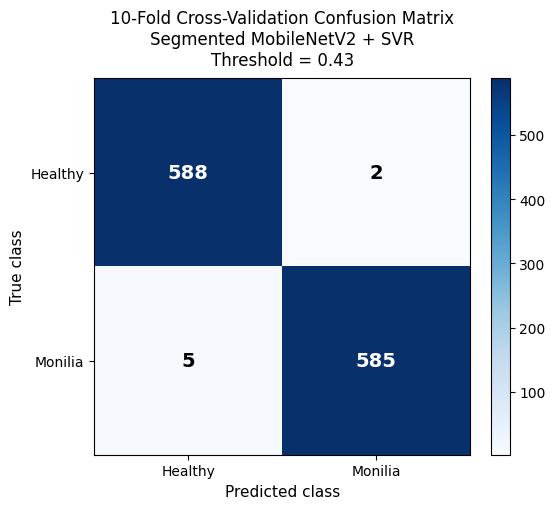

[OK] Saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures_segmented_blue/confusion_segmented_svr_blue.png


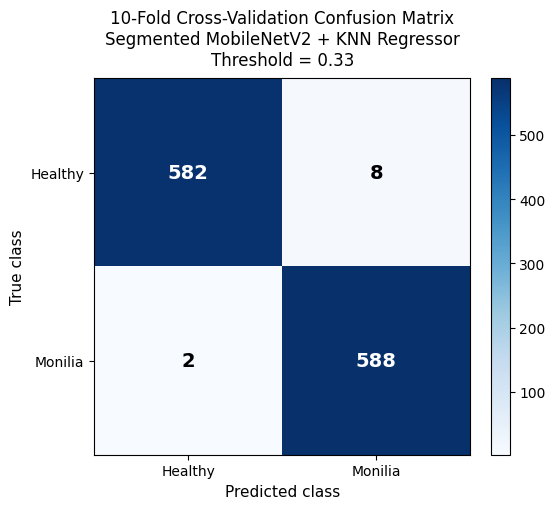

[OK] Saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures_segmented_blue/confusion_segmented_knn_regressor_blue.png


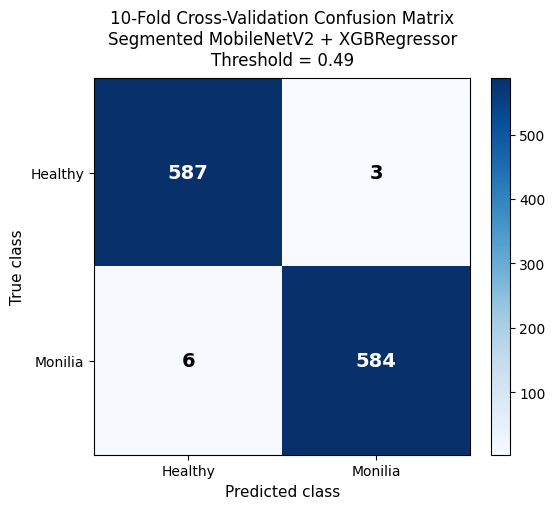

[OK] Saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures_segmented_blue/confusion_segmented_xgb_regressor_blue.png


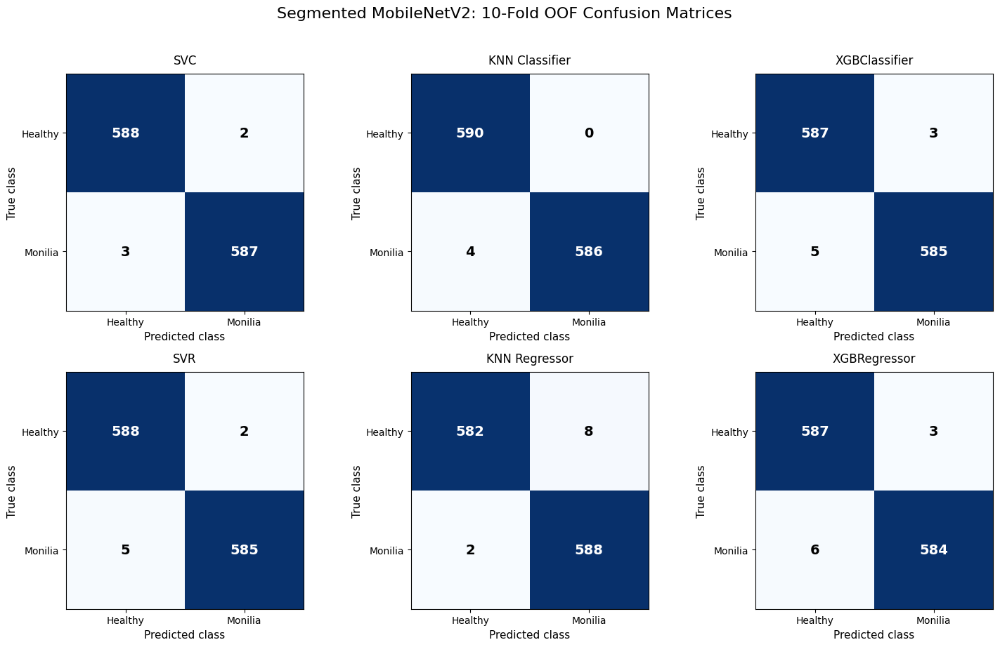

[OK] Comparative panel saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures_segmented_blue/confusion_segmented_all_models_panel.png

SEGMENTED OOF METRICS
   model_label  threshold  accuracy  precision  sensitivity  specificity  f1_macro    mcc  roc_auc
           SVC        NaN    0.9958     0.9966       0.9949       0.9966    0.9958 0.9915   1.0000
KNN Classifier        NaN    0.9966     1.0000       0.9932       1.0000    0.9966 0.9932   0.9991
 XGBClassifier        NaN    0.9932     0.9949       0.9915       0.9949    0.9932 0.9864   0.9996
           SVR       0.43    0.9941     0.9966       0.9915       0.9966    0.9941 0.9881   0.9998
 KNN Regressor       0.33    0.9915     0.9866       0.9966       0.9864    0.9915 0.9831   0.9983
  XGBRegressor       0.49    0.9924     0.9949       0.9898       0.9949    0.9924 0.9848   0.9993


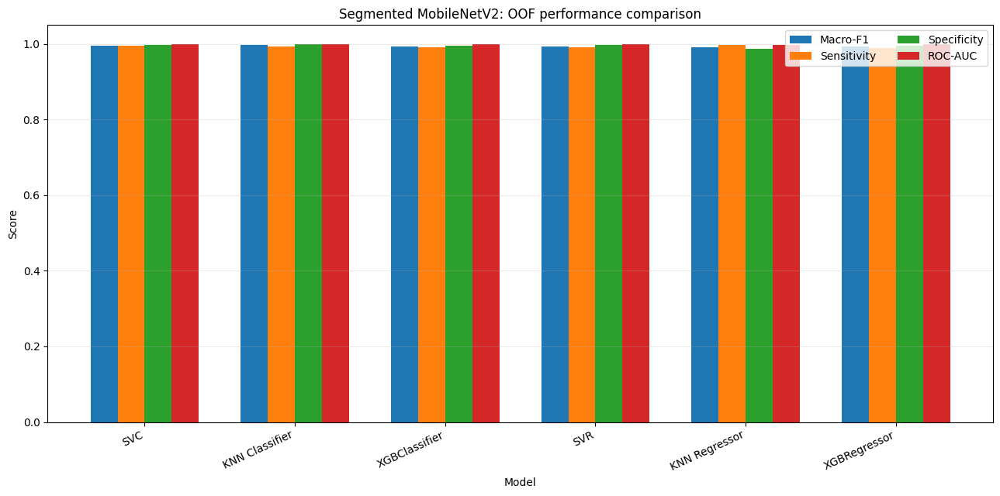

[OK] Metrics comparison saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures_segmented_blue/segmented_oof_metrics_comparison.png


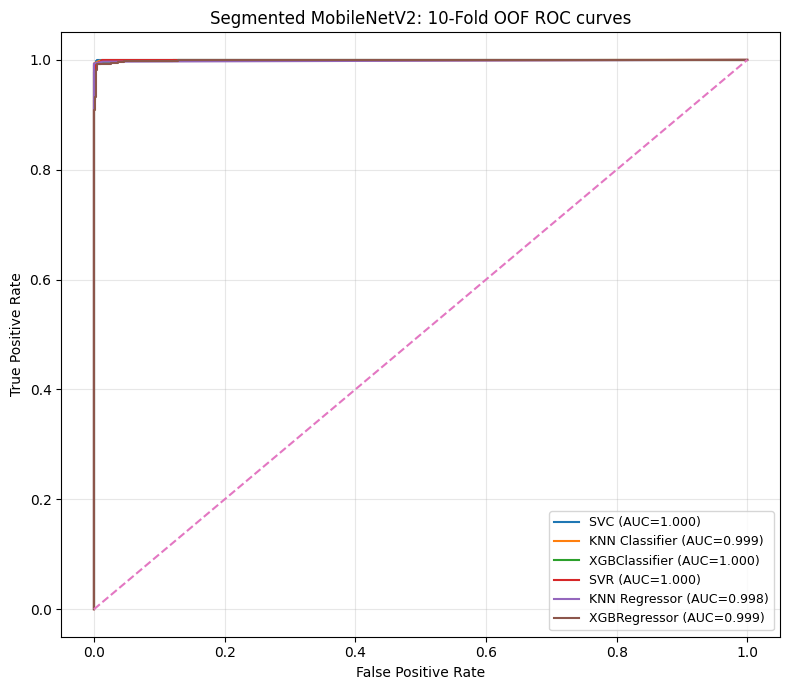

[OK] ROC comparison saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures_segmented_blue/segmented_oof_roc_all_models.png

[OK] Six segmented confusion matrices generated.
[OK] Comparative 2x3 confusion-matrix panel generated.
[OK] Segmented OOF metric comparison generated.
[OK] Segmented OOF ROC overlay generated.
[OK] No model was retrained in this plotting stage.

Outputs:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/figures_segmented_blue


In [ ]:
# ============================================================
# 10-FOLD STRATIFIED CROSS-VALIDATION
# FIXED HYPERPARAMETERS AFTER HYBRID HPO
#
# Representations:
#   1. Original
#   2. Segmented
#
# Direct classification:
#   1. SVC
#   2. KNeighborsClassifier
#   3. XGBClassifier
#
# Regression + fixed HPO threshold:
#   4. SVR
#   5. KNeighborsRegressor
#   6. XGBRegressor
#
# Data used here:
#   TRAIN ONLY = 1180 images
#
# HPO and locked test are NOT used as CV samples.
#
# IMPORTANT:
# - Hyperparameters are loaded from results/hybrid_hpo.
# - Regression thresholds were selected previously on HPO and
#   remain FIXED during all 10 CV folds.
# - No threshold is optimized inside CV.
# ============================================================

import os
import json
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC, SVR
from sklearn.neighbors import (
    KNeighborsClassifier,
    KNeighborsRegressor,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
)

from xgboost import XGBClassifier, XGBRegressor


# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

RANDOM_STATE = 42
N_SPLITS = 10

CLASS_NAMES = [
    "Healthy",
    "Monilia",
]

MODEL_ORDER = [
    "svc",
    "knn_classifier",
    "xgb_classifier",
    "svr",
    "knn_regressor",
    "xgb_regressor",
]

MODEL_LABELS = {
    "svc": "SVC",
    "knn_classifier": "KNN Classifier",
    "xgb_classifier": "XGBClassifier",
    "svr": "SVR",
    "knn_regressor": "KNN Regressor",
    "xgb_regressor": "XGBRegressor",
}

print("=" * 80)
print("10-FOLD STRATIFIED CROSS-VALIDATION")
print("CLASSIFICATION vs. REGRESSION + FIXED THRESHOLD")
print("=" * 80)


# ============================================================
# 2. PATHS
# ============================================================

ejecucion = (
    "/content/drive/MyDrive/"
    "Articulo_DiegoR/articulo"
)

features_directory = os.path.join(
    ejecucion,
    "features"
)

hpo_directory = os.path.join(
    ejecucion,
    "results",
    "hybrid_hpo"
)

cv_directory = os.path.join(
    ejecucion,
    "results",
    "cross_validation_10fold_hybrid"
)

predictions_directory = os.path.join(
    cv_directory,
    "oof_predictions"
)

figures_directory = os.path.join(
    cv_directory,
    "figures"
)

for directory in [
    cv_directory,
    predictions_directory,
    figures_directory,
]:
    os.makedirs(
        directory,
        exist_ok=True
    )


# ============================================================
# 3. LOAD TRAIN FEATURES ONLY
#
# HPO and locked test samples are intentionally not loaded.
# ============================================================

X_original = np.load(
    os.path.join(
        features_directory,
        "X_original_train.npy"
    )
)

X_segmented = np.load(
    os.path.join(
        features_directory,
        "X_segmented_train.npy"
    )
)

y = np.load(
    os.path.join(
        features_directory,
        "y_train.npy"
    )
)

assert X_original.shape == (1180, 1280)
assert X_segmented.shape == (1180, 1280)
assert y.shape == (1180,)
assert np.isfinite(X_original).all()
assert np.isfinite(X_segmented).all()
assert set(np.unique(y)).issubset({0, 1})

print(
    "\nOriginal features :",
    X_original.shape
)

print(
    "Segmented features:",
    X_segmented.shape
)

print(
    "Labels            :",
    y.shape
)

unique_labels, label_counts = np.unique(
    y,
    return_counts=True
)

print(
    "\nClass distribution:",
    dict(
        zip(
            unique_labels.tolist(),
            label_counts.tolist()
        )
    )
)

print(
    "\n[OK] Only the 1180 training samples "
    "were loaded."
)


# ============================================================
# 4. LOAD FIXED HPO CONFIGURATIONS
# ============================================================

def load_hpo_result(
    branch,
    model_name
):
    path = os.path.join(
        hpo_directory,
        f"best_{branch}_{model_name}.json"
    )

    assert os.path.isfile(
        path
    ), (
        f"Missing HPO result:\n{path}\n"
        "Run the hybrid HPO stage first."
    )

    with open(
        path,
        "r"
    ) as f:
        result = json.load(f)

    return result


hpo_results = {}

for branch in [
    "original",
    "segmented",
]:
    hpo_results[branch] = {}

    for model_name in MODEL_ORDER:
        result = load_hpo_result(
            branch,
            model_name
        )

        hpo_results[
            branch
        ][
            model_name
        ] = result

        print(
            f"\n{branch.upper()} "
            f"+ {MODEL_LABELS[model_name]}:"
        )

        print(
            "  approach  :",
            result[
                "approach"
            ]
        )

        print(
            "  params    :",
            result[
                "best_params"
            ]
        )

        if (
            result[
                "approach"
            ]
            ==
            "regression_threshold"
        ):
            print(
                "  threshold :",
                result[
                    "decision_threshold"
                ]
            )


# ============================================================
# 5. MODEL BUILDER
# ============================================================

def build_model(
    model_name,
    params
):
    if model_name == "svc":
        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    SVC(
                        **params
                    )
                ),
            ]
        )

    if model_name == "knn_classifier":
        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    KNeighborsClassifier(
                        **params,
                        n_jobs=-1
                    )
                ),
            ]
        )

    if model_name == "xgb_classifier":
        return XGBClassifier(
            **params,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        )

    if model_name == "svr":
        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    SVR(
                        **params
                    )
                ),
            ]
        )

    if model_name == "knn_regressor":
        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    KNeighborsRegressor(
                        **params,
                        n_jobs=-1
                    )
                ),
            ]
        )

    if model_name == "xgb_regressor":
        return XGBRegressor(
            **params,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        )

    raise ValueError(
        f"Unknown model: {model_name}"
    )


# ============================================================
# 6. CONTINUOUS PREDICTION SCORE
# ============================================================

def get_classifier_score(
    model,
    X
):
    if hasattr(
        model,
        "predict_proba"
    ):
        probability = (
            model.predict_proba(X)
        )

        return probability[:, 1]

    if hasattr(
        model,
        "decision_function"
    ):
        return model.decision_function(X)

    raise ValueError(
        "Classifier does not provide "
        "continuous prediction scores."
    )


# ============================================================
# 7. METRICS FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred,
    y_score
):
    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )
        .ravel()
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "sensitivity":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "specificity":
            specificity,

        "f1_monilia":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "f1_macro":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        # Ranking metric. For regressors, scores are not
        # interpreted as calibrated probabilities.
        "roc_auc":
            roc_auc_score(
                y_true,
                y_score
            ),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# ============================================================
# 8. DEFINE THE SAME 10 FOLDS FOR ALL MODELS
# ============================================================

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_indices = list(
    skf.split(
        X_original,
        y
    )
)

assert len(
    fold_indices
) == N_SPLITS

print(
    "\n[OK] Same 10 stratified folds "
    "created for all 12 experiments."
)


# ============================================================
# 9. CROSS-VALIDATION FUNCTION
# ============================================================

def run_10fold_cv(
    branch_name,
    model_name,
    X,
    hpo_result
):
    approach = hpo_result[
        "approach"
    ]

    params = hpo_result[
        "best_params"
    ]

    threshold = hpo_result[
        "decision_threshold"
    ]

    if (
        approach
        ==
        "regression_threshold"
    ):
        assert threshold is not None, (
            f"Missing frozen HPO threshold for "
            f"{branch_name} + {model_name}"
        )

        threshold = float(
            threshold
        )

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"10-FOLD CV: "
        f"{branch_name.upper()} "
        f"+ {MODEL_LABELS[model_name]} "
        f"[{approach}]"
    )

    if threshold is not None:
        print(
            f"Frozen HPO threshold: "
            f"{threshold:.4f}"
        )

    print(
        "=" * 80
    )

    y_pred_oof = np.zeros(
        len(y),
        dtype=np.int32
    )

    y_score_oof = np.zeros(
        len(y),
        dtype=np.float64
    )

    fold_records = []

    for fold_number, (
        train_index,
        validation_index
    ) in enumerate(
        fold_indices,
        start=1
    ):
        print(
            f"\nFold "
            f"{fold_number}/{N_SPLITS}"
        )

        X_train_fold = X[
            train_index
        ]

        X_val_fold = X[
            validation_index
        ]

        y_train_fold = y[
            train_index
        ]

        y_val_fold = y[
            validation_index
        ]

        model = build_model(
            model_name,
            params
        )

        model.fit(
            X_train_fold,
            y_train_fold
        )

        if approach == "classification":
            y_pred_fold = model.predict(
                X_val_fold
            ).astype(int)

            y_score_fold = (
                get_classifier_score(
                    model,
                    X_val_fold
                )
            )

        elif approach == "regression_threshold":
            y_score_fold = model.predict(
                X_val_fold
            )

            y_pred_fold = (
                y_score_fold
                >=
                threshold
            ).astype(int)

        else:
            raise ValueError(
                f"Unknown approach: {approach}"
            )

        y_pred_oof[
            validation_index
        ] = y_pred_fold

        y_score_oof[
            validation_index
        ] = y_score_fold

        fold_metrics = calculate_metrics(
            y_val_fold,
            y_pred_fold,
            y_score_fold
        )

        fold_record = {
            "branch":
                branch_name,

            "approach":
                approach,

            "model":
                model_name,

            "threshold":
                (
                    threshold
                    if threshold is not None
                    else np.nan
                ),

            "fold":
                fold_number,

            "train_n":
                len(
                    train_index
                ),

            "validation_n":
                len(
                    validation_index
                ),

            **fold_metrics,
        }

        fold_records.append(
            fold_record
        )

        print(
            f"    Accuracy="
            f"{fold_metrics['accuracy']:.4f} | "
            f"Macro-F1="
            f"{fold_metrics['f1_macro']:.4f} | "
            f"MCC="
            f"{fold_metrics['mcc']:.4f} | "
            f"AUC="
            f"{fold_metrics['roc_auc']:.4f}"
        )

        del model
        gc.collect()

    # ========================================================
    # FOLD RESULTS
    # ========================================================

    fold_df = pd.DataFrame(
        fold_records
    )

    fold_path = os.path.join(
        cv_directory,
        (
            f"fold_metrics_"
            f"{branch_name}_"
            f"{model_name}.csv"
        )
    )

    fold_df.to_csv(
        fold_path,
        index=False
    )

    # ========================================================
    # OOF PREDICTIONS
    # ========================================================

    oof_df = pd.DataFrame(
        {
            "sample_index":
                np.arange(
                    len(y)
                ),

            "y_true":
                y.astype(int),

            "y_pred":
                y_pred_oof.astype(int),

            "score":
                y_score_oof,

            "approach":
                approach,

            "threshold":
                (
                    threshold
                    if threshold is not None
                    else np.nan
                ),
        }
    )

    oof_path = os.path.join(
        predictions_directory,
        (
            f"oof_"
            f"{branch_name}_"
            f"{model_name}.csv"
        )
    )

    oof_df.to_csv(
        oof_path,
        index=False
    )

    # ========================================================
    # GLOBAL OOF METRICS
    # ========================================================

    global_metrics = calculate_metrics(
        y,
        y_pred_oof,
        y_score_oof
    )

    print(
        "\n"
        + "-" * 60
    )

    print(
        "GLOBAL OUT-OF-FOLD RESULTS"
    )

    print(
        "-" * 60
    )

    print(
        f"Accuracy    : "
        f"{global_metrics['accuracy']:.4f}"
    )

    print(
        f"Macro-F1    : "
        f"{global_metrics['f1_macro']:.4f}"
    )

    print(
        f"Precision   : "
        f"{global_metrics['precision']:.4f}"
    )

    print(
        f"Sensitivity : "
        f"{global_metrics['sensitivity']:.4f}"
    )

    print(
        f"Specificity : "
        f"{global_metrics['specificity']:.4f}"
    )

    print(
        f"MCC         : "
        f"{global_metrics['mcc']:.4f}"
    )

    print(
        f"ROC-AUC     : "
        f"{global_metrics['roc_auc']:.4f}"
    )

    # ========================================================
    # PLOT 1: ROC CURVE
    # ========================================================

    fpr, tpr, _ = roc_curve(
        y,
        y_score_oof
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    fig, ax = plt.subplots(
        figsize=(6.4, 5.4)
    )

    ax.plot(
        fpr,
        tpr,
        label=(
            f"AUC = "
            f"{roc_auc_value:.4f}"
        )
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    ax.set_xlabel(
        "False Positive Rate"
    )

    ax.set_ylabel(
        "True Positive Rate"
    )

    ax.set_title(
        f"10-Fold OOF ROC\n"
        f"{branch_name.capitalize()} "
        f"+ {MODEL_LABELS[model_name]}"
    )

    ax.legend(
        loc="lower right"
    )

    ax.grid(
        alpha=0.3
    )

    fig.tight_layout()

    roc_path = os.path.join(
        figures_directory,
        (
            f"roc_"
            f"{branch_name}_"
            f"{model_name}.png"
        )
    )

    fig.savefig(
        roc_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # PLOT 2: CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(
        y,
        y_pred_oof,
        labels=[0, 1]
    )

    fig, ax = plt.subplots(
        figsize=(5.4, 4.8)
    )

    image = ax.imshow(
        cm,
        cmap="Blues"
    )

    ax.set_xticks(
        [0, 1]
    )

    ax.set_yticks(
        [0, 1]
    )

    ax.set_xticklabels(
        CLASS_NAMES
    )

    ax.set_yticklabels(
        CLASS_NAMES
    )

    ax.set_xlabel(
        "Predicted class"
    )

    ax.set_ylabel(
        "True class"
    )

    title = (
        f"10-Fold OOF Confusion Matrix\n"
        f"{branch_name.capitalize()} "
        f"+ {MODEL_LABELS[model_name]}"
    )

    if threshold is not None:
        title += (
            f"\nThreshold = "
            f"{threshold:.2f}"
        )

    ax.set_title(
        title
    )

    max_value = cm.max()

    for row_index in range(2):
        for column_index in range(2):
            value = cm[
                row_index,
                column_index
            ]

            text_color = (
                "white"
                if value > max_value / 2
                else "black"
            )

            ax.text(
                column_index,
                row_index,
                str(value),
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color=text_color
            )

    fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    fig.tight_layout()

    cm_path = os.path.join(
        figures_directory,
        (
            f"confusion_"
            f"{branch_name}_"
            f"{model_name}.png"
        )
    )

    fig.savefig(
        cm_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # RETURN SUMMARY
    # ========================================================

    summary = {
        "branch":
            branch_name,

        "approach":
            approach,

        "model":
            model_name,

        "threshold":
            (
                threshold
                if threshold is not None
                else np.nan
            ),

        "accuracy_oof":
            global_metrics[
                "accuracy"
            ],

        "precision_oof":
            global_metrics[
                "precision"
            ],

        "sensitivity_oof":
            global_metrics[
                "sensitivity"
            ],

        "specificity_oof":
            global_metrics[
                "specificity"
            ],

        "f1_monilia_oof":
            global_metrics[
                "f1_monilia"
            ],

        "f1_macro_oof":
            global_metrics[
                "f1_macro"
            ],

        "mcc_oof":
            global_metrics[
                "mcc"
            ],

        "roc_auc_oof":
            global_metrics[
                "roc_auc"
            ],

        "accuracy_mean":
            fold_df[
                "accuracy"
            ].mean(),

        "accuracy_sd":
            fold_df[
                "accuracy"
            ].std(
                ddof=1
            ),

        "f1_macro_mean":
            fold_df[
                "f1_macro"
            ].mean(),

        "f1_macro_sd":
            fold_df[
                "f1_macro"
            ].std(
                ddof=1
            ),

        "mcc_mean":
            fold_df[
                "mcc"
            ].mean(),

        "mcc_sd":
            fold_df[
                "mcc"
            ].std(
                ddof=1
            ),

        "roc_auc_mean":
            fold_df[
                "roc_auc"
            ].mean(),

        "roc_auc_sd":
            fold_df[
                "roc_auc"
            ].std(
                ddof=1
            ),
    }

    return (
        summary,
        fold_df,
        oof_df
    )


# ============================================================
# 10. RUN ALL 12 EXPERIMENTS
# ============================================================

branches = {
    "original":
        X_original,

    "segmented":
        X_segmented,
}

cv_summaries = []
all_fold_results = []

for branch_name, X_branch in (
    branches.items()
):
    for model_name in MODEL_ORDER:
        summary, fold_df, oof_df = (
            run_10fold_cv(
                branch_name=
                    branch_name,

                model_name=
                    model_name,

                X=
                    X_branch,

                hpo_result=
                    hpo_results[
                        branch_name
                    ][
                        model_name
                    ],
            )
        )

        cv_summaries.append(
            summary
        )

        all_fold_results.append(
            fold_df
        )


# ============================================================
# 11. GLOBAL CV SUMMARY
# ============================================================

cv_summary_df = pd.DataFrame(
    cv_summaries
)

cv_summary_path = os.path.join(
    cv_directory,
    "cross_validation_summary.csv"
)

cv_summary_df.to_csv(
    cv_summary_path,
    index=False
)

print(
    "\n"
    + "=" * 80
)

print(
    "10-FOLD CROSS-VALIDATION SUMMARY"
)

print(
    "=" * 80
)

display(
    cv_summary_df[
        [
            "branch",
            "approach",
            "model",
            "threshold",
            "accuracy_oof",
            "precision_oof",
            "sensitivity_oof",
            "specificity_oof",
            "f1_macro_oof",
            "mcc_oof",
            "roc_auc_oof",
            "accuracy_mean",
            "accuracy_sd",
            "f1_macro_mean",
            "f1_macro_sd",
            "mcc_mean",
            "mcc_sd",
            "roc_auc_mean",
            "roc_auc_sd",
        ]
    ].round(4)
)


# ============================================================
# 12. SAVE ALL FOLD RESULTS TOGETHER
# ============================================================

all_folds_df = pd.concat(
    all_fold_results,
    ignore_index=True
)

all_folds_path = os.path.join(
    cv_directory,
    "all_fold_metrics.csv"
)

all_folds_df.to_csv(
    all_folds_path,
    index=False
)


# ============================================================
# 13. PLOT 3
# MACRO-F1 DISTRIBUTION ACROSS THE 10 FOLDS
# ============================================================

labels_plot = []
values_plot = []

for branch_name in [
    "original",
    "segmented",
]:
    for model_name in MODEL_ORDER:
        subset = all_folds_df[
            (
                all_folds_df[
                    "branch"
                ]
                ==
                branch_name
            )
            &
            (
                all_folds_df[
                    "model"
                ]
                ==
                model_name
            )
        ]

        labels_plot.append(
            (
                f"{branch_name.capitalize()}\n"
                f"{MODEL_LABELS[model_name]}"
            )
        )

        values_plot.append(
            subset[
                "f1_macro"
            ].to_numpy()
        )

fig, ax = plt.subplots(
    figsize=(16, 7)
)

ax.boxplot(
    values_plot,
    tick_labels=
        labels_plot
)

ax.set_ylabel(
    "Macro F1-score"
)

ax.set_title(
    "10-Fold Cross-Validation Macro F1-score Distribution"
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.tick_params(
    axis="x",
    labelrotation=35
)

fig.tight_layout()

boxplot_path = os.path.join(
    figures_directory,
    "f1_macro_10fold_boxplot.png"
)

fig.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. PLOT 4
# OOF MACRO-F1: ORIGINAL vs. SEGMENTED
# ============================================================

f1_pivot = (
    cv_summary_df
    .pivot(
        index="model",
        columns="branch",
        values="f1_macro_oof"
    )
    .reindex(
        MODEL_ORDER
    )
)

x = np.arange(
    len(MODEL_ORDER)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.bar(
    x - width / 2,
    f1_pivot["original"].values,
    width,
    label="Original"
)

ax.bar(
    x + width / 2,
    f1_pivot["segmented"].values,
    width,
    label="Segmented"
)

ax.set_title(
    "10-Fold OOF Macro-F1 by model"
)

ax.set_xlabel(
    "Model"
)

ax.set_ylabel(
    "Macro-F1"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        MODEL_LABELS[
            model_name
        ]
        for model_name in MODEL_ORDER
    ],
    rotation=25,
    ha="right"
)

ax.set_ylim(
    0.0,
    1.05
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

comparison_path = os.path.join(
    figures_directory,
    "oof_macro_f1_original_vs_segmented.png"
)

fig.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. PLOT 5
# SEGMENTED REPRESENTATION - FOUR KEY OOF METRICS
# ============================================================

segmented_summary = (
    cv_summary_df[
        cv_summary_df[
            "branch"
        ]
        ==
        "segmented"
    ]
    .set_index(
        "model"
    )
    .reindex(
        MODEL_ORDER
    )
)

metric_columns = [
    "f1_macro_oof",
    "sensitivity_oof",
    "specificity_oof",
    "roc_auc_oof",
]

metric_labels = [
    "Macro-F1",
    "Sensitivity",
    "Specificity",
    "ROC-AUC",
]

x = np.arange(
    len(MODEL_ORDER)
)

width = 0.18

fig, ax = plt.subplots(
    figsize=(13, 6.5)
)

for metric_index, (
    metric_column,
    metric_label
) in enumerate(
    zip(
        metric_columns,
        metric_labels
    )
):
    offset = (
        metric_index
        -
        (
            len(metric_columns) - 1
        )
        / 2
    ) * width

    ax.bar(
        x + offset,
        segmented_summary[
            metric_column
        ].values,
        width,
        label=metric_label
    )

ax.set_title(
    "Segmented representation: OOF performance by model"
)

ax.set_xlabel(
    "Model"
)

ax.set_ylabel(
    "Score"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        MODEL_LABELS[
            model_name
        ]
        for model_name in MODEL_ORDER
    ],
    rotation=25,
    ha="right"
)

ax.set_ylim(
    0.0,
    1.05
)

ax.legend(
    ncol=2
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

segmented_metrics_path = os.path.join(
    figures_directory,
    "segmented_oof_metrics_comparison.png"
)

fig.savefig(
    segmented_metrics_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. PLOT 6
# SEGMENTED REPRESENTATION - OVERLAID ROC CURVES
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

for model_name in MODEL_ORDER:
    oof_path = os.path.join(
        predictions_directory,
        (
            f"oof_segmented_"
            f"{model_name}.csv"
        )
    )

    oof_df = pd.read_csv(
        oof_path
    )

    fpr, tpr, _ = roc_curve(
        oof_df[
            "y_true"
        ],
        oof_df[
            "score"
        ]
    )

    auc_value = roc_auc_score(
        oof_df[
            "y_true"
        ],
        oof_df[
            "score"
        ]
    )

    ax.plot(
        fpr,
        tpr,
        label=(
            f"{MODEL_LABELS[model_name]} "
            f"(AUC={auc_value:.3f})"
        )
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

ax.set_title(
    "Segmented representation: 10-Fold OOF ROC curves"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.legend(
    loc="lower right",
    fontsize=9
)

ax.grid(
    alpha=0.3
)

fig.tight_layout()

roc_overlay_path = os.path.join(
    figures_directory,
    "segmented_oof_roc_all_models.png"
)

fig.savefig(
    roc_overlay_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. PLOT 7
# FROZEN HPO THRESHOLDS USED BY THE REGRESSORS
# ============================================================

regression_models = [
    "svr",
    "knn_regressor",
    "xgb_regressor",
]

threshold_df = (
    cv_summary_df[
        cv_summary_df[
            "model"
        ].isin(
            regression_models
        )
    ][
        [
            "branch",
            "model",
            "threshold",
        ]
    ]
    .copy()
)

threshold_pivot = (
    threshold_df
    .pivot(
        index="model",
        columns="branch",
        values="threshold"
    )
    .reindex(
        regression_models
    )
)

x = np.arange(
    len(regression_models)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)

ax.bar(
    x - width / 2,
    threshold_pivot["original"].values,
    width,
    label="Original"
)

ax.bar(
    x + width / 2,
    threshold_pivot["segmented"].values,
    width,
    label="Segmented"
)

ax.axhline(
    0.5,
    linestyle="--",
    label="Reference 0.50"
)

ax.set_title(
    "Frozen HPO thresholds used during 10-Fold CV"
)

ax.set_xlabel(
    "Regressor"
)

ax.set_ylabel(
    "Decision threshold"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        MODEL_LABELS[
            model_name
        ]
        for model_name in regression_models
    ]
)

ax.set_ylim(
    0.0,
    1.0
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

thresholds_path = os.path.join(
    figures_directory,
    "frozen_regression_thresholds.png"
)

fig.savefig(
    thresholds_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. FINAL CHECK
# ============================================================

print(
    "\n[OK] 10-fold stratified "
    "cross-validation completed."
)

print(
    "[OK] Same folds were used for "
    "all 12 branch-model experiments."
)

print(
    "[OK] HPO hyperparameters and regression thresholds "
    "remained fixed during CV."
)

print(
    "[OK] HPO samples were not used as CV samples."
)

print(
    "[OK] Locked test remains untouched."
)

print(
    "\nSummary:"
)

print(
    cv_summary_path
)

print(
    "\nFold-level results:"
)

print(
    all_folds_path
)

print(
    "\nOOF predictions:"
)

print(
    predictions_directory
)

print(
    "\nFigures:"
)

print(
    figures_directory
)

# ============================================================
# PUBLICATION-STYLE BLUE CONFUSION MATRICES
# SEGMENTED REPRESENTATION ONLY
#
# Direct classification:
#   SVC
#   KNN Classifier
#   XGBClassifier
#
# Regression + fixed HPO threshold:
#   SVR
#   KNN Regressor
#   XGBRegressor
#
# Uses previously saved OOF predictions from the hybrid
# 10-fold cross-validation stage.
# No model is retrained.
#
# Outputs:
#   1. Six individual blue confusion matrices
#   2. One 2x3 comparative panel
#   3. Segmented OOF metrics comparison
#   4. Segmented ROC overlay
# ============================================================

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
)


# ============================================================
# PATHS
# ============================================================

ejecucion = (
    "/content/drive/MyDrive/"
    "Articulo_DiegoR/articulo"
)

cv_directory = os.path.join(
    ejecucion,
    "results",
    "cross_validation_10fold_hybrid"
)

predictions_directory = os.path.join(
    cv_directory,
    "oof_predictions"
)

blue_figures_directory = os.path.join(
    cv_directory,
    "figures_segmented_blue"
)

os.makedirs(
    blue_figures_directory,
    exist_ok=True
)


# ============================================================
# CONFIGURATION
# ============================================================

CLASS_NAMES = [
    "Healthy",
    "Monilia",
]

MODELS = [
    "svc",
    "knn_classifier",
    "xgb_classifier",
    "svr",
    "knn_regressor",
    "xgb_regressor",
]

MODEL_LABELS = {
    "svc": "SVC",
    "knn_classifier": "KNN Classifier",
    "xgb_classifier": "XGBClassifier",
    "svr": "SVR",
    "knn_regressor": "KNN Regressor",
    "xgb_regressor": "XGBRegressor",
}


# ============================================================
# HELPER: LOAD OOF PREDICTIONS
# ============================================================

def load_oof_predictions(
    model_name
):
    prediction_path = os.path.join(
        predictions_directory,
        (
            f"oof_segmented_"
            f"{model_name}.csv"
        )
    )

    assert os.path.isfile(
        prediction_path
    ), (
        f"OOF prediction file not found:\n"
        f"{prediction_path}\n"
        "Run the hybrid 10-fold CV stage first."
    )

    prediction_df = pd.read_csv(
        prediction_path
    )

    required_columns = {
        "y_true",
        "y_pred",
        "score",
    }

    missing_columns = (
        required_columns
        -
        set(
            prediction_df.columns
        )
    )

    assert not missing_columns, (
        f"Missing columns in "
        f"{prediction_path}: "
        f"{missing_columns}"
    )

    return prediction_df


# ============================================================
# HELPER: BLUE CONFUSION MATRIX ON AN AXIS
# ============================================================

def draw_blue_confusion_matrix(
    ax,
    cm,
    title
):
    image = ax.imshow(
        cm,
        cmap="Blues"
    )

    max_value = cm.max()

    for row_index in range(2):
        for column_index in range(2):
            value = cm[
                row_index,
                column_index
            ]

            text_color = (
                "white"
                if value > max_value / 2
                else "black"
            )

            ax.text(
                column_index,
                row_index,
                str(value),
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color=text_color
            )

    ax.set_xlabel(
        "Predicted class",
        fontsize=11
    )

    ax.set_ylabel(
        "True class",
        fontsize=11
    )

    ax.set_title(
        title,
        fontsize=12,
        pad=10
    )

    ax.set_xticks(
        [0, 1]
    )

    ax.set_yticks(
        [0, 1]
    )

    ax.set_xticklabels(
        CLASS_NAMES,
        rotation=0,
        fontsize=10
    )

    ax.set_yticklabels(
        CLASS_NAMES,
        rotation=0,
        fontsize=10
    )

    return image


# ============================================================
# 1. SIX INDIVIDUAL PUBLICATION-STYLE MATRICES
# ============================================================

all_confusion_matrices = {}

for model_name in MODELS:
    prediction_df = (
        load_oof_predictions(
            model_name
        )
    )

    cm = confusion_matrix(
        prediction_df[
            "y_true"
        ],
        prediction_df[
            "y_pred"
        ],
        labels=[0, 1]
    )

    all_confusion_matrices[
        model_name
    ] = cm

    fig, ax = plt.subplots(
        figsize=(6.2, 5.2)
    )

    title = (
        "10-Fold Cross-Validation Confusion Matrix\n"
        f"Segmented MobileNetV2 + "
        f"{MODEL_LABELS[model_name]}"
    )

    threshold_value = None

    if (
        "threshold"
        in prediction_df.columns
        and
        prediction_df[
            "threshold"
        ].notna().any()
    ):
        threshold_value = float(
            prediction_df[
                "threshold"
            ]
            .dropna()
            .iloc[0]
        )

        title += (
            f"\nThreshold = "
            f"{threshold_value:.2f}"
        )

    image = draw_blue_confusion_matrix(
        ax,
        cm,
        title
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    colorbar.ax.tick_params(
        labelsize=10
    )

    fig.tight_layout()

    output_path = os.path.join(
        blue_figures_directory,
        (
            f"confusion_segmented_"
            f"{model_name}_blue.png"
        )
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"[OK] Saved:\n"
        f"{output_path}"
    )


# ============================================================
# 2. COMPARATIVE 2x3 PANEL
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

for ax, model_name in zip(
    axes.ravel(),
    MODELS
):
    cm = all_confusion_matrices[
        model_name
    ]

    draw_blue_confusion_matrix(
        ax,
        cm,
        MODEL_LABELS[
            model_name
        ]
    )

fig.suptitle(
    "Segmented MobileNetV2: 10-Fold OOF Confusion Matrices",
    fontsize=16,
    y=1.02
)

fig.tight_layout()

panel_path = os.path.join(
    blue_figures_directory,
    "confusion_segmented_all_models_panel.png"
)

fig.savefig(
    panel_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"[OK] Comparative panel saved:\n"
    f"{panel_path}"
)


# ============================================================
# 3. BUILD SEGMENTED OOF METRICS TABLE
# ============================================================

metric_rows = []

for model_name in MODELS:
    prediction_df = (
        load_oof_predictions(
            model_name
        )
    )

    y_true = prediction_df[
        "y_true"
    ].to_numpy()

    y_pred = prediction_df[
        "y_pred"
    ].to_numpy()

    y_score = prediction_df[
        "score"
    ].to_numpy()

    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )
        .ravel()
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    threshold_value = np.nan

    if (
        "threshold"
        in prediction_df.columns
        and
        prediction_df[
            "threshold"
        ].notna().any()
    ):
        threshold_value = float(
            prediction_df[
                "threshold"
            ]
            .dropna()
            .iloc[0]
        )

    metric_rows.append(
        {
            "model":
                model_name,

            "model_label":
                MODEL_LABELS[
                    model_name
                ],

            "threshold":
                threshold_value,

            "accuracy":
                accuracy_score(
                    y_true,
                    y_pred
                ),

            "precision":
                precision_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            "sensitivity":
                recall_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            "specificity":
                specificity,

            "f1_macro":
                f1_score(
                    y_true,
                    y_pred,
                    average="macro",
                    zero_division=0
                ),

            "mcc":
                matthews_corrcoef(
                    y_true,
                    y_pred
                ),

            "roc_auc":
                roc_auc_score(
                    y_true,
                    y_score
                ),
        }
    )

metrics_df = pd.DataFrame(
    metric_rows
)

metrics_path = os.path.join(
    blue_figures_directory,
    "segmented_oof_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

print(
    "\nSEGMENTED OOF METRICS"
)

display_columns = [
    "model_label",
    "threshold",
    "accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1_macro",
    "mcc",
    "roc_auc",
]

print(
    metrics_df[
        display_columns
    ]
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 4. SEGMENTED OOF METRICS COMPARISON
# ============================================================

metric_names = [
    "f1_macro",
    "sensitivity",
    "specificity",
    "roc_auc",
]

metric_labels = [
    "Macro-F1",
    "Sensitivity",
    "Specificity",
    "ROC-AUC",
]

x = np.arange(
    len(MODELS)
)

width = 0.18

fig, ax = plt.subplots(
    figsize=(13, 6.5)
)

for metric_index, (
    metric_name,
    metric_label
) in enumerate(
    zip(
        metric_names,
        metric_labels
    )
):
    offset = (
        metric_index
        -
        (
            len(metric_names) - 1
        )
        / 2
    ) * width

    ax.bar(
        x + offset,
        metrics_df[
            metric_name
        ].values,
        width,
        label=metric_label
    )

ax.set_title(
    "Segmented MobileNetV2: OOF performance comparison"
)

ax.set_xlabel(
    "Model"
)

ax.set_ylabel(
    "Score"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    metrics_df[
        "model_label"
    ],
    rotation=25,
    ha="right"
)

ax.set_ylim(
    0.0,
    1.05
)

ax.legend(
    ncol=2
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

metrics_plot_path = os.path.join(
    blue_figures_directory,
    "segmented_oof_metrics_comparison.png"
)

fig.savefig(
    metrics_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"[OK] Metrics comparison saved:\n"
    f"{metrics_plot_path}"
)


# ============================================================
# 5. SEGMENTED ROC OVERLAY - ALL SIX MODELS
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

for model_name in MODELS:
    prediction_df = (
        load_oof_predictions(
            model_name
        )
    )

    y_true = prediction_df[
        "y_true"
    ].to_numpy()

    y_score = prediction_df[
        "score"
    ].to_numpy()

    fpr, tpr, _ = roc_curve(
        y_true,
        y_score
    )

    auc_value = roc_auc_score(
        y_true,
        y_score
    )

    ax.plot(
        fpr,
        tpr,
        label=(
            f"{MODEL_LABELS[model_name]} "
            f"(AUC={auc_value:.3f})"
        )
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

ax.set_title(
    "Segmented MobileNetV2: 10-Fold OOF ROC curves"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.legend(
    loc="lower right",
    fontsize=9
)

ax.grid(
    alpha=0.3
)

fig.tight_layout()

roc_path = os.path.join(
    blue_figures_directory,
    "segmented_oof_roc_all_models.png"
)

fig.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"[OK] ROC comparison saved:\n"
    f"{roc_path}"
)


# ============================================================
# FINAL STATUS
# ============================================================

print(
    "\n[OK] Six segmented confusion matrices generated."
)

print(
    "[OK] Comparative 2x3 confusion-matrix panel generated."
)

print(
    "[OK] Segmented OOF metric comparison generated."
)

print(
    "[OK] Segmented OOF ROC overlay generated."
)

print(
    "[OK] No model was retrained in this plotting stage."
)

print(
    "\nOutputs:"
)

print(
    blue_figures_directory
)


##**10. Evaluación de modelos**

PAIRED 10-FOLD MACRO F1-SCORES
SEGMENTED REPRESENTATION


model,SVC,KNN Classifier,XGBClassifier,SVR,KNN Regressor,XGBRegressor
fold,,,,,,
1,0.9831,0.9915,0.9915,0.9915,0.9746,0.9915
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,0.9830,1.0000,0.9915,0.9915
4,1.0000,0.9915,0.9915,0.9915,0.9915,0.9746
5,0.9831,0.9915,0.9831,0.9831,0.9915,0.9831
6,1.0000,1.0000,1.0000,0.9915,1.0000,1.0000
7,1.0000,1.0000,1.0000,0.9915,1.0000,1.0000
8,1.0000,1.0000,0.9915,1.0000,0.9830,0.9915
9,1.0000,1.0000,0.9915,1.0000,0.9830,0.9915



DESCRIPTIVE SUMMARY


accuracy                 f1_macro                     mcc  \
                   mean     std  median     mean     std  median    mean   
model                                                                      
svc              0.9958  0.0072  1.0000   0.9958  0.0072  1.0000  0.9915   
knn_classifier   0.9966  0.0044  1.0000   0.9966  0.0044  1.0000  0.9933   
xgb_classifier   0.9932  0.0067  0.9915   0.9932  0.0067  0.9915  0.9866   
svr              0.9941  0.0057  0.9915   0.9941  0.0057  0.9915  0.9882   
knn_regressor    0.9915  0.0089  0.9915   0.9915  0.0089  0.9915  0.9832   
xgb_regressor    0.9924  0.0084  0.9915   0.9924  0.0084  0.9915  0.9849   

                               roc_auc                  
                   std  median    mean     std  median  
model                                                   
svc             0.0144  1.0000  0.9999  0.0002  1.0000  
knn_classifier  0.0087  1.0000  0.9991  0.0027  1.0000  
xgb_classifier  0.0133  0.9832  0.9997  0.0005  1.0000  
svr             0.0114  0.9832  0.9998  0.0005  1.0000  
knn_regressor   0.0177  0.9832  0.9982  0.0036  1.0000  
xgb_regressor   0.0166  0.9832  0.9994  0.0007  0.9999


FRIEDMAN TEST - MACRO F1
Chi-square = 4.434389
p-value    = 0.488710
Kendall's W = 0.088688
[NOTE] Friedman is not significant at alpha=0.05. Pairwise Wilcoxon results will still be computed and saved, but should be treated as exploratory rather than confirmatory.

AVERAGE FRIEDMAN RANKS


,model_label,approach,average_rank
0,KNN Classifier,Direct classification,2.8
1,SVC,Direct classification,3.1
2,XGBClassifier,Direct classification,3.7
3,SVR,Regression + threshold,3.7
4,XGBRegressor,Regression + threshold,3.8
5,KNN Regressor,Regression + threshold,3.9



PAIRWISE WILCOXON + HOLM


,model_a_label,model_b_label,mean_a,mean_b,mean_difference,rank_biserial,wilcoxon_statistic,p_raw,p_holm,significant_0.05,better_mean_model
0,SVC,KNN Classifier,0.995763,0.996610,-0.000847,0.000000,24.0,1.000000,1.0,False,KNN Classifier
1,SVC,XGBClassifier,0.995763,0.993220,0.002543,0.571429,17.5,0.343750,1.0,False,SVC
2,SVC,SVR,0.995763,0.994067,0.001695,0.800000,17.5,0.250000,1.0,False,SVC
3,SVC,KNN Regressor,0.995763,0.991524,0.004239,0.714286,13.0,0.171875,1.0,False,SVC
4,SVC,XGBRegressor,0.995763,0.992371,0.003392,0.571429,17.5,0.343750,1.0,False,SVC
5,KNN Classifier,XGBClassifier,0.996610,0.993220,0.003390,0.600000,15.5,0.312500,1.0,False,KNN Classifier
6,KNN Classifier,SVR,0.996610,0.994067,0.002542,1.000000,14.0,0.250000,1.0,False,KNN Classifier
7,KNN Classifier,KNN Regressor,0.996610,0.991524,0.005086,0.800000,14.0,0.187500,1.0,False,KNN Classifier
8,KNN Classifier,XGBRegressor,0.996610,0.992371,0.004239,0.666667,12.5,0.187500,1.0,False,KNN Classifier
9,XGBClassifier,SVR,0.993220,0.994067,-0.000848,-0.142857,26.0,1.000000,1.0,False,SVR



SECONDARY FRIEDMAN TESTS


,metric,n_folds,n_models,friedman_chi_square,p_value,kendalls_w
0,accuracy,10,6,4.434389,0.488710,0.088688
1,mcc,10,6,4.434389,0.488710,0.088688
2,roc_auc,10,6,6.655172,0.247574,0.133103


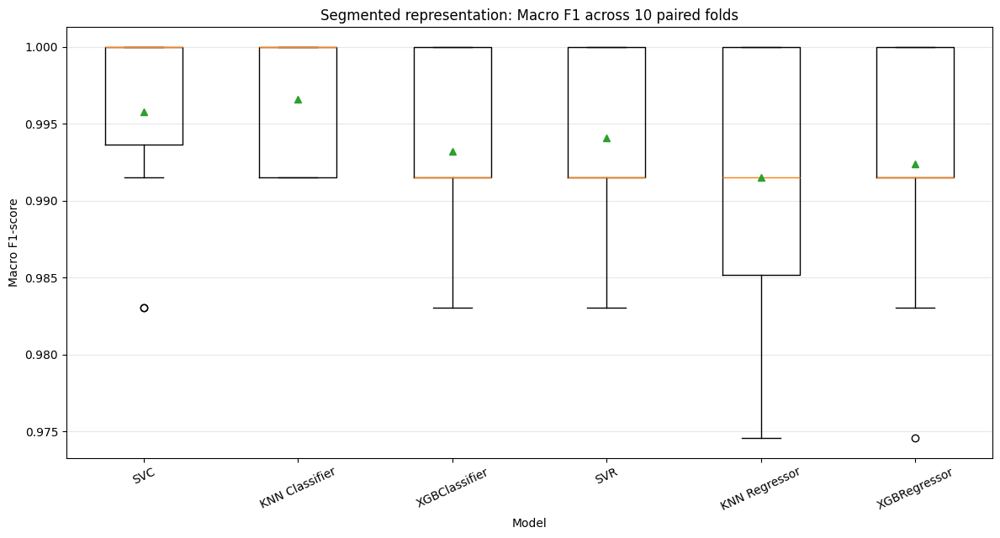

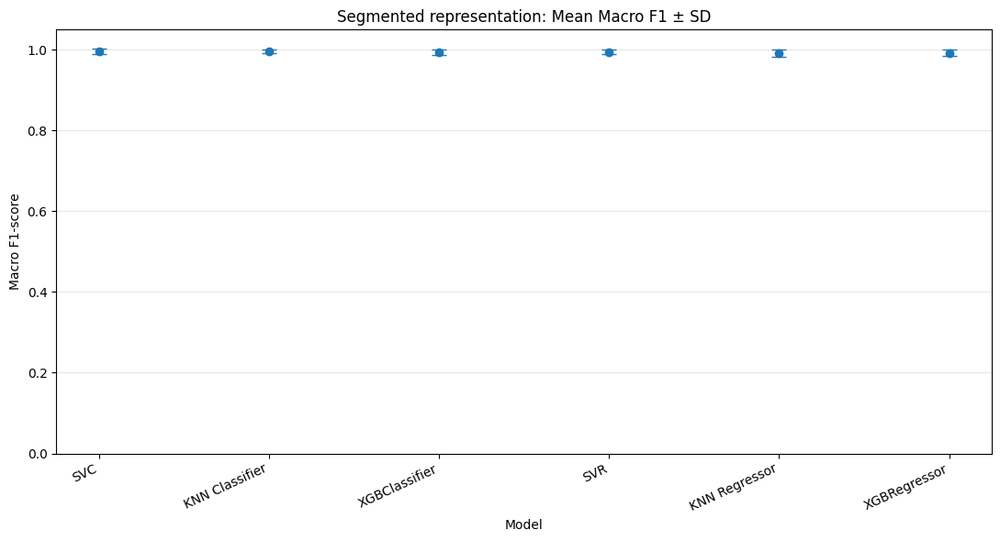

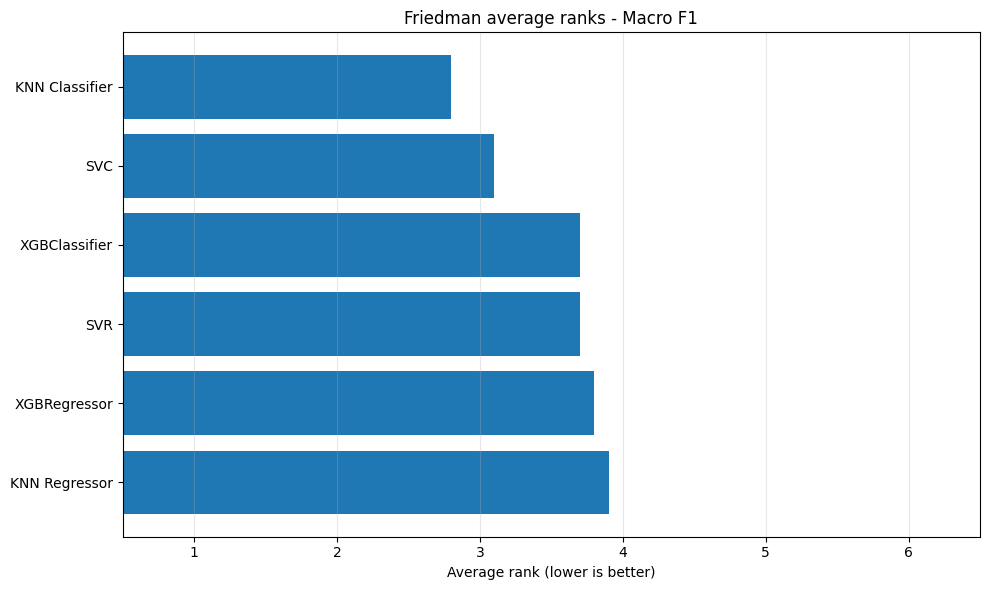

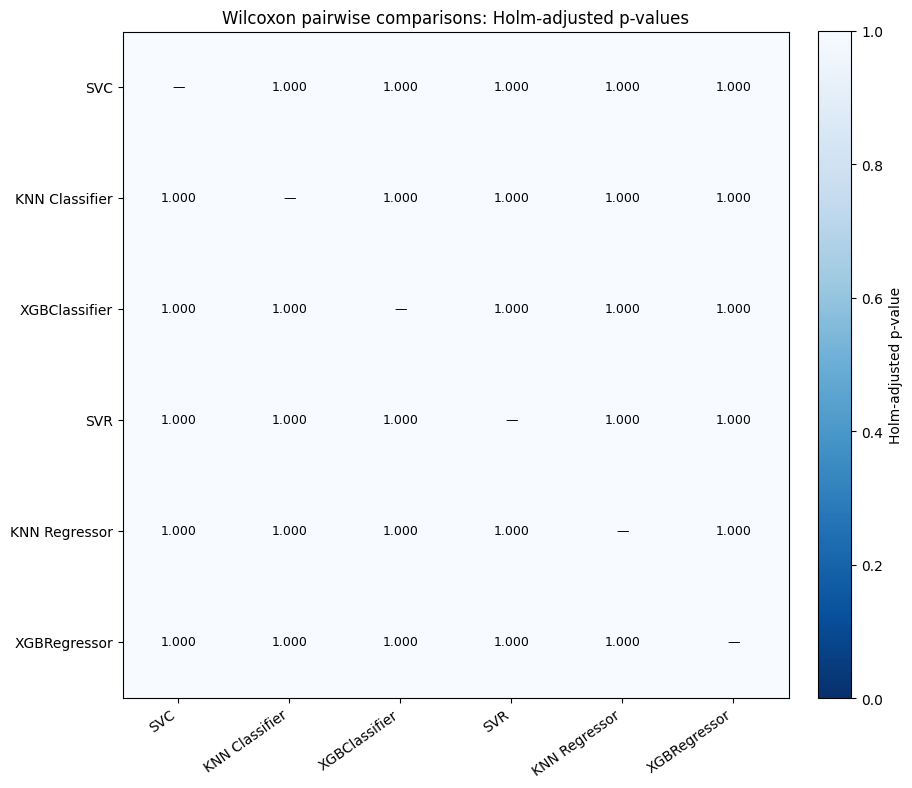


DESCRIPTIVE SUMMARY BY APPROACH


accuracy         f1_macro             mcc          \
                           mean     std     mean     std    mean     std   
approach                                                                   
Direct classification    0.9952  0.0062   0.9952  0.0062  0.9905  0.0123   
Regression + threshold   0.9927  0.0076   0.9927  0.0076  0.9854  0.0151   

                       roc_auc          
                          mean     std  
approach                                
Direct classification   0.9996  0.0016  
Regression + threshold  0.9992  0.0022


[OK] Paired statistical analysis completed.
[OK] Models compared: 6
[OK] Pairwise Wilcoxon comparisons: 15

Primary Friedman analysis:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/statistical_comparison_segmented/friedman_macro_f1.csv

Post-hoc Wilcoxon + Holm:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/statistical_comparison_segmented/wilcoxon_holm_macro_f1.csv

Average ranks:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/statistical_comparison_segmented/average_ranks_macro_f1.csv

Secondary Friedman tests:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/statistical_comparison_segmented/friedman_secondary_metrics.csv

Figures:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/cross_validation_10fold_hybrid/statistical_comparison_segmented/figures


In [ ]:
# ============================================================
# STATISTICAL COMPARISON OF SEGMENTED HYBRID MODELS
#
# 10 paired folds:
#   Direct classification:
#       1. SVC
#       2. KNN Classifier
#       3. XGBClassifier
#
#   Regression + fixed HPO threshold:
#       4. SVR
#       5. KNN Regressor
#       6. XGBRegressor
#
# Primary metric:
#   Macro F1-score
#
# Omnibus test:
#   Friedman
#
# Post-hoc:
#   Paired Wilcoxon signed-rank tests
#   Holm correction
#
# Additional outputs:
#   - Kendall's W
#   - Rank-biserial effect size for pairwise comparisons
#   - Average model ranks
#   - Publication-ready plots
# ============================================================

import os
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    friedmanchisquare,
    wilcoxon,
    rankdata,
)

from statsmodels.stats.multitest import (
    multipletests
)

from IPython.display import display


# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

ALPHA = 0.05

MODELS = [
    "svc",
    "knn_classifier",
    "xgb_classifier",
    "svr",
    "knn_regressor",
    "xgb_regressor",
]

MODEL_LABELS = {
    "svc":
        "SVC",

    "knn_classifier":
        "KNN Classifier",

    "xgb_classifier":
        "XGBClassifier",

    "svr":
        "SVR",

    "knn_regressor":
        "KNN Regressor",

    "xgb_regressor":
        "XGBRegressor",
}

MODEL_APPROACH = {
    "svc":
        "Direct classification",

    "knn_classifier":
        "Direct classification",

    "xgb_classifier":
        "Direct classification",

    "svr":
        "Regression + threshold",

    "knn_regressor":
        "Regression + threshold",

    "xgb_regressor":
        "Regression + threshold",
}


# ============================================================
# 2. PATHS
# ============================================================

ejecucion = (
    "/content/drive/MyDrive/"
    "Articulo_DiegoR/articulo"
)

cv_directory = os.path.join(
    ejecucion,
    "results",
    "cross_validation_10fold_hybrid"
)

all_folds_path = os.path.join(
    cv_directory,
    "all_fold_metrics.csv"
)

statistics_directory = os.path.join(
    cv_directory,
    "statistical_comparison_segmented"
)

figures_directory = os.path.join(
    statistics_directory,
    "figures"
)

os.makedirs(
    statistics_directory,
    exist_ok=True
)

os.makedirs(
    figures_directory,
    exist_ok=True
)


# ============================================================
# 3. LOAD FOLD RESULTS
# ============================================================

assert os.path.isfile(
    all_folds_path
), (
    f"Fold-level results not found:\n"
    f"{all_folds_path}\n"
    "Run the hybrid 10-fold CV stage first."
)

all_folds_df = pd.read_csv(
    all_folds_path
)

required_columns = {
    "branch",
    "model",
    "fold",
    "accuracy",
    "f1_macro",
    "mcc",
    "roc_auc",
}

missing_columns = (
    required_columns
    -
    set(
        all_folds_df.columns
    )
)

assert not missing_columns, (
    f"Missing required columns: "
    f"{missing_columns}"
)


segmented_df = all_folds_df[
    all_folds_df[
        "branch"
    ]
    ==
    "segmented"
].copy()


# 6 models x 10 folds = 60 paired observations.
assert len(
    segmented_df
) == (
    len(MODELS)
    *
    10
), (
    f"Expected 60 segmented fold rows, "
    f"found {len(segmented_df)}."
)


# ============================================================
# 4. VERIFY PAIRED DESIGN
# ============================================================

pairing_table = (
    segmented_df
    .pivot(
        index="fold",
        columns="model",
        values="f1_macro"
    )
    .sort_index()
    .reindex(
        columns=MODELS
    )
)

assert list(
    pairing_table.index
) == list(
    range(
        1,
        11
    )
)

assert list(
    pairing_table.columns
) == MODELS

assert not (
    pairing_table
    .isna()
    .any()
    .any()
)

print("=" * 80)
print("PAIRED 10-FOLD MACRO F1-SCORES")
print("SEGMENTED REPRESENTATION")
print("=" * 80)

pairing_display = (
    pairing_table
    .rename(
        columns=MODEL_LABELS
    )
)

display(
    pairing_display.round(4)
)


# ============================================================
# 5. DESCRIPTIVE SUMMARY
# ============================================================

descriptive_summary = (
    segmented_df
    .groupby(
        "model"
    )[
        [
            "accuracy",
            "f1_macro",
            "mcc",
            "roc_auc",
        ]
    ]
    .agg(
        [
            "mean",
            "std",
            "median",
        ]
    )
    .reindex(
        MODELS
    )
)

print(
    "\nDESCRIPTIVE SUMMARY"
)

display(
    descriptive_summary.round(4)
)


# Also create a flat publication-friendly table.
descriptive_flat = (
    segmented_df
    .groupby(
        "model"
    )
    .agg(
        accuracy_mean=(
            "accuracy",
            "mean"
        ),
        accuracy_sd=(
            "accuracy",
            "std"
        ),
        f1_macro_mean=(
            "f1_macro",
            "mean"
        ),
        f1_macro_sd=(
            "f1_macro",
            "std"
        ),
        mcc_mean=(
            "mcc",
            "mean"
        ),
        mcc_sd=(
            "mcc",
            "std"
        ),
        roc_auc_mean=(
            "roc_auc",
            "mean"
        ),
        roc_auc_sd=(
            "roc_auc",
            "std"
        ),
    )
    .reindex(
        MODELS
    )
    .reset_index()
)

descriptive_flat[
    "model_label"
] = descriptive_flat[
    "model"
].map(
    MODEL_LABELS
)

descriptive_flat[
    "approach"
] = descriptive_flat[
    "model"
].map(
    MODEL_APPROACH
)


# ============================================================
# 6. FRIEDMAN TEST
#
# H0:
# All six models have the same distribution of paired
# Macro F1-scores across the same 10 folds.
# ============================================================

friedman_result = friedmanchisquare(
    *[
        pairing_table[
            model
        ].to_numpy()
        for model in MODELS
    ]
)

friedman_statistic = float(
    friedman_result.statistic
)

friedman_pvalue = float(
    friedman_result.pvalue
)

print(
    "\n"
    + "=" * 80
)

print(
    "FRIEDMAN TEST - MACRO F1"
)

print(
    "=" * 80
)

print(
    f"Chi-square = "
    f"{friedman_statistic:.6f}"
)

print(
    f"p-value    = "
    f"{friedman_pvalue:.6f}"
)


# ============================================================
# 7. EFFECT SIZE: KENDALL'S W
#
# W = chi-square / [N * (k - 1)]
#
# N = number of paired blocks/folds
# k = number of models
# ============================================================

n_blocks = pairing_table.shape[0]
n_models = pairing_table.shape[1]

kendalls_w = (
    friedman_statistic
    /
    (
        n_blocks
        *
        (
            n_models - 1
        )
    )
)

print(
    f"Kendall's W = "
    f"{kendalls_w:.6f}"
)

if friedman_pvalue < ALPHA:
    print(
        "[OK] Friedman is significant at alpha=0.05. "
        "Post-hoc Wilcoxon tests can be interpreted."
    )
else:
    print(
        "[NOTE] Friedman is not significant at alpha=0.05. "
        "Pairwise Wilcoxon results will still be computed and saved, "
        "but should be treated as exploratory rather than confirmatory."
    )


# ============================================================
# 8. AVERAGE MODEL RANKS
#
# Rank 1 = best Macro-F1 in a fold.
# Ties receive average ranks.
# ============================================================

rank_matrix = np.vstack(
    [
        rankdata(
            -pairing_table.iloc[
                fold_index
            ].to_numpy(),
            method="average"
        )
        for fold_index in range(
            pairing_table.shape[0]
        )
    ]
)

average_ranks = (
    pd.DataFrame(
        rank_matrix,
        columns=MODELS,
        index=pairing_table.index
    )
    .mean(
        axis=0
    )
    .sort_values()
)

average_ranks_df = (
    average_ranks
    .rename(
        "average_rank"
    )
    .reset_index()
    .rename(
        columns={
            "index":
                "model"
        }
    )
)

average_ranks_df[
    "model_label"
] = average_ranks_df[
    "model"
].map(
    MODEL_LABELS
)

average_ranks_df[
    "approach"
] = average_ranks_df[
    "model"
].map(
    MODEL_APPROACH
)

print(
    "\nAVERAGE FRIEDMAN RANKS"
)

display(
    average_ranks_df[
        [
            "model_label",
            "approach",
            "average_rank",
        ]
    ].round(4)
)


# ============================================================
# 9. PAIRWISE EFFECT SIZE
#
# Rank-biserial correlation based on paired differences.
#
# Positive value:
#   model_a tends to outperform model_b.
#
# Negative value:
#   model_b tends to outperform model_a.
# ============================================================

def paired_rank_biserial(
    differences
):
    differences = np.asarray(
        differences,
        dtype=float
    )

    nonzero = differences[
        ~np.isclose(
            differences,
            0.0
        )
    ]

    if len(nonzero) == 0:
        return 0.0

    absolute_ranks = rankdata(
        np.abs(
            nonzero
        ),
        method="average"
    )

    positive_sum = absolute_ranks[
        nonzero > 0
    ].sum()

    negative_sum = absolute_ranks[
        nonzero < 0
    ].sum()

    denominator = (
        positive_sum
        +
        negative_sum
    )

    if denominator == 0:
        return 0.0

    return float(
        (
            positive_sum
            -
            negative_sum
        )
        /
        denominator
    )


# ============================================================
# 10. POST-HOC PAIRED WILCOXON
#
# 6 models -> 15 pairwise comparisons.
# ============================================================

pairwise_results = []

for model_a, model_b in itertools.combinations(
    MODELS,
    2
):
    values_a = pairing_table[
        model_a
    ].to_numpy()

    values_b = pairing_table[
        model_b
    ].to_numpy()

    differences = (
        values_a
        -
        values_b
    )

    if np.allclose(
        differences,
        0
    ):
        statistic = 0.0
        raw_p = 1.0

    else:
        test = wilcoxon(
            values_a,
            values_b,
            zero_method="zsplit",
            alternative="two-sided",
            method="auto"
        )

        statistic = float(
            test.statistic
        )

        raw_p = float(
            test.pvalue
        )

    pairwise_results.append(
        {
            "model_a":
                model_a,

            "model_b":
                model_b,

            "model_a_label":
                MODEL_LABELS[
                    model_a
                ],

            "model_b_label":
                MODEL_LABELS[
                    model_b
                ],

            "approach_a":
                MODEL_APPROACH[
                    model_a
                ],

            "approach_b":
                MODEL_APPROACH[
                    model_b
                ],

            "mean_a":
                float(
                    values_a.mean()
                ),

            "mean_b":
                float(
                    values_b.mean()
                ),

            "median_a":
                float(
                    np.median(
                        values_a
                    )
                ),

            "median_b":
                float(
                    np.median(
                        values_b
                    )
                ),

            "mean_difference":
                float(
                    differences.mean()
                ),

            "median_difference":
                float(
                    np.median(
                        differences
                    )
                ),

            "rank_biserial":
                paired_rank_biserial(
                    differences
                ),

            "wilcoxon_statistic":
                statistic,

            "p_raw":
                raw_p,
        }
    )

posthoc_df = pd.DataFrame(
    pairwise_results
)


# ============================================================
# 11. HOLM MULTIPLE-COMPARISON CORRECTION
# ============================================================

reject, p_adjusted, _, _ = multipletests(
    posthoc_df[
        "p_raw"
    ].to_numpy(),

    alpha=ALPHA,

    method="holm"
)

posthoc_df[
    "p_holm"
] = p_adjusted

posthoc_df[
    "significant_0.05"
] = reject

posthoc_df[
    "better_mean_model"
] = np.where(
    posthoc_df[
        "mean_difference"
    ] > 0,
    posthoc_df[
        "model_a_label"
    ],
    np.where(
        posthoc_df[
            "mean_difference"
        ] < 0,
        posthoc_df[
            "model_b_label"
        ],
        "Tie"
    )
)

print(
    "\n"
    + "=" * 80
)

print(
    "PAIRWISE WILCOXON + HOLM"
)

print(
    "=" * 80
)

display(
    posthoc_df[
        [
            "model_a_label",
            "model_b_label",
            "mean_a",
            "mean_b",
            "mean_difference",
            "rank_biserial",
            "wilcoxon_statistic",
            "p_raw",
            "p_holm",
            "significant_0.05",
            "better_mean_model",
        ]
    ].round(6)
)


# ============================================================
# 12. SAVE PRIMARY RESULTS
# ============================================================

friedman_df = pd.DataFrame(
    [
        {
            "metric":
                "Macro F1-score",

            "n_folds":
                n_blocks,

            "n_models":
                n_models,

            "friedman_chi_square":
                friedman_statistic,

            "p_value":
                friedman_pvalue,

            "kendalls_w":
                kendalls_w,
        }
    ]
)

friedman_path = os.path.join(
    statistics_directory,
    "friedman_macro_f1.csv"
)

posthoc_path = os.path.join(
    statistics_directory,
    "wilcoxon_holm_macro_f1.csv"
)

paired_scores_path = os.path.join(
    statistics_directory,
    "paired_macro_f1_scores.csv"
)

average_ranks_path = os.path.join(
    statistics_directory,
    "average_ranks_macro_f1.csv"
)

descriptive_path = os.path.join(
    statistics_directory,
    "descriptive_summary_segmented.csv"
)

friedman_df.to_csv(
    friedman_path,
    index=False
)

posthoc_df.to_csv(
    posthoc_path,
    index=False
)

pairing_table.to_csv(
    paired_scores_path
)

average_ranks_df.to_csv(
    average_ranks_path,
    index=False
)

descriptive_flat.to_csv(
    descriptive_path,
    index=False
)


# ============================================================
# 13. SECONDARY FRIEDMAN TESTS
#
# Exploratory only.
# Macro F1 remains the primary outcome.
# ============================================================

secondary_metrics = [
    "accuracy",
    "mcc",
    "roc_auc",
]

secondary_results = []

for metric in secondary_metrics:
    table = (
        segmented_df
        .pivot(
            index="fold",
            columns="model",
            values=metric
        )
        .sort_index()
        .reindex(
            columns=MODELS
        )
    )

    assert not (
        table
        .isna()
        .any()
        .any()
    )

    result = friedmanchisquare(
        *[
            table[
                model
            ].to_numpy()
            for model in MODELS
        ]
    )

    w = (
        result.statistic
        /
        (
            table.shape[0]
            *
            (
                table.shape[1]
                -
                1
            )
        )
    )

    secondary_results.append(
        {
            "metric":
                metric,

            "n_folds":
                table.shape[0],

            "n_models":
                table.shape[1],

            "friedman_chi_square":
                float(
                    result.statistic
                ),

            "p_value":
                float(
                    result.pvalue
                ),

            "kendalls_w":
                float(
                    w
                ),
        }
    )

secondary_df = pd.DataFrame(
    secondary_results
)

secondary_path = os.path.join(
    statistics_directory,
    "friedman_secondary_metrics.csv"
)

secondary_df.to_csv(
    secondary_path,
    index=False
)

print(
    "\nSECONDARY FRIEDMAN TESTS"
)

display(
    secondary_df.round(6)
)


# ============================================================
# 14. VISUALIZATION 1
# MACRO-F1 DISTRIBUTION ACROSS 10 FOLDS
# ============================================================

values_plot = [
    pairing_table[
        model
    ].to_numpy()
    for model in MODELS
]

labels_plot = [
    MODEL_LABELS[
        model
    ]
    for model in MODELS
]

fig, ax = plt.subplots(
    figsize=(12, 6.5)
)

ax.boxplot(
    values_plot,
    tick_labels=
        labels_plot,
    showmeans=True
)

ax.set_ylabel(
    "Macro F1-score"
)

ax.set_xlabel(
    "Model"
)

ax.set_title(
    "Segmented representation: Macro F1 across 10 paired folds"
)

ax.tick_params(
    axis="x",
    labelrotation=25
)

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

boxplot_path = os.path.join(
    figures_directory,
    "macro_f1_segmented_10fold_boxplot.png"
)

fig.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. VISUALIZATION 2
# MEAN MACRO-F1 ± STANDARD DEVIATION
# ============================================================

mean_f1 = (
    pairing_table
    .mean()
    .reindex(
        MODELS
    )
)

sd_f1 = (
    pairing_table
    .std(
        ddof=1
    )
    .reindex(
        MODELS
    )
)

x = np.arange(
    len(MODELS)
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.errorbar(
    x,
    mean_f1.values,
    yerr=sd_f1.values,
    fmt="o",
    capsize=6
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels_plot,
    rotation=25,
    ha="right"
)

ax.set_ylabel(
    "Macro F1-score"
)

ax.set_xlabel(
    "Model"
)

ax.set_title(
    "Segmented representation: Mean Macro F1 ± SD"
)

ax.set_ylim(
    0.0,
    1.05
)

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

mean_sd_path = os.path.join(
    figures_directory,
    "macro_f1_mean_sd_segmented.png"
)

fig.savefig(
    mean_sd_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. VISUALIZATION 3
# AVERAGE FRIEDMAN RANKS
#
# Lower rank = better.
# ============================================================

rank_plot_df = (
    average_ranks_df
    .sort_values(
        "average_rank",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

y_positions = np.arange(
    len(
        rank_plot_df
    )
)

ax.barh(
    y_positions,
    rank_plot_df[
        "average_rank"
    ].values
)

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    rank_plot_df[
        "model_label"
    ]
)

ax.invert_yaxis()

ax.set_xlabel(
    "Average rank (lower is better)"
)

ax.set_title(
    "Friedman average ranks - Macro F1"
)

ax.set_xlim(
    0.5,
    len(MODELS) + 0.5
)

ax.grid(
    axis="x",
    alpha=0.3
)

fig.tight_layout()

rank_plot_path = os.path.join(
    figures_directory,
    "friedman_average_ranks_macro_f1.png"
)

fig.savefig(
    rank_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. VISUALIZATION 4
# HOLM-ADJUSTED P-VALUE MATRIX
# ============================================================

p_matrix = pd.DataFrame(
    np.ones(
        (
            len(MODELS),
            len(MODELS)
        )
    ),
    index=MODELS,
    columns=MODELS,
    dtype=float
)

for _, row in posthoc_df.iterrows():
    model_a = row[
        "model_a"
    ]

    model_b = row[
        "model_b"
    ]

    p_value = row[
        "p_holm"
    ]

    p_matrix.loc[
        model_a,
        model_b
    ] = p_value

    p_matrix.loc[
        model_b,
        model_a
    ] = p_value

fig, ax = plt.subplots(
    figsize=(9, 8)
)

image = ax.imshow(
    p_matrix.to_numpy(),
    vmin=0.0,
    vmax=1.0,
    cmap="Blues_r"
)

ax.set_xticks(
    np.arange(
        len(MODELS)
    )
)

ax.set_yticks(
    np.arange(
        len(MODELS)
    )
)

ax.set_xticklabels(
    labels_plot,
    rotation=35,
    ha="right"
)

ax.set_yticklabels(
    labels_plot
)

ax.set_title(
    "Wilcoxon pairwise comparisons: Holm-adjusted p-values"
)

for row_index in range(
    len(MODELS)
):
    for column_index in range(
        len(MODELS)
    ):
        if row_index == column_index:
            label = "—"

        else:
            value = p_matrix.iloc[
                row_index,
                column_index
            ]

            if value < 0.001:
                label = "<0.001"

            else:
                label = (
                    f"{value:.3f}"
                )

        ax.text(
            column_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=9
        )

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

colorbar.set_label(
    "Holm-adjusted p-value"
)

fig.tight_layout()

p_matrix_path = os.path.join(
    figures_directory,
    "wilcoxon_holm_pvalue_matrix.png"
)

fig.savefig(
    p_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. OPTIONAL: DIRECT CLASSIFICATION vs REGRESSION FAMILY
#
# This is descriptive only.
# It is NOT a replacement for the six-model Friedman test.
# ============================================================

family_summary = (
    segmented_df
    .assign(
        approach=
            segmented_df[
                "model"
            ].map(
                MODEL_APPROACH
            )
    )
    .groupby(
        "approach"
    )[
        [
            "accuracy",
            "f1_macro",
            "mcc",
            "roc_auc",
        ]
    ]
    .agg(
        [
            "mean",
            "std",
        ]
    )
)

family_summary_path = os.path.join(
    statistics_directory,
    "descriptive_summary_by_approach.csv"
)

family_summary.to_csv(
    family_summary_path
)

print(
    "\nDESCRIPTIVE SUMMARY BY APPROACH"
)

display(
    family_summary.round(4)
)


# ============================================================
# 19. FINAL STATUS
# ============================================================

print(
    "\n[OK] Paired statistical analysis completed."
)

print(
    f"[OK] Models compared: "
    f"{len(MODELS)}"
)

print(
    f"[OK] Pairwise Wilcoxon comparisons: "
    f"{len(posthoc_df)}"
)

print(
    "\nPrimary Friedman analysis:"
)

print(
    friedman_path
)

print(
    "\nPost-hoc Wilcoxon + Holm:"
)

print(
    posthoc_path
)

print(
    "\nAverage ranks:"
)

print(
    average_ranks_path
)

print(
    "\nSecondary Friedman tests:"
)

print(
    secondary_path
)

print(
    "\nFigures:"
)

print(
    figures_directory
)


## 11. Test Final

FINAL UNCERTAINTY + REPRESENTATION-LEVEL GRAD-CAM AUDIT

SELECTED FINAL MODEL
Model     : KNN Classifier
Approach  : classification
CV F1     : 0.9966 ± 0.0044

[OK] Final model was selected from CV results, before reading its locked-test performance.

Locked-test predictions:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/final_test_segmented/predictions/segmented_knn_locked_test_predictions.csv

95% CONFIDENCE INTERVALS
Selected model: KNN Classifier


,metric,estimate,bootstrap_ci_lower,bootstrap_ci_upper,exact_ci_lower,exact_ci_upper
0,accuracy,1.0,1.0,1.0,0.9783,1.0
1,precision,1.0,1.0,1.0,0.9570,1.0
2,sensitivity,1.0,1.0,1.0,0.9570,1.0
3,specificity,1.0,1.0,1.0,0.9570,1.0
4,f1_monilia,1.0,1.0,1.0,NaN,NaN
5,f1_macro,1.0,1.0,1.0,NaN,NaN
6,mcc,1.0,1.0,1.0,NaN,NaN
7,roc_auc,1.0,1.0,1.0,NaN,NaN


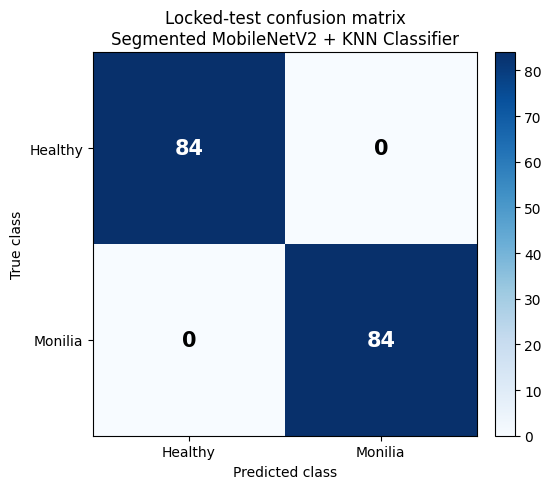

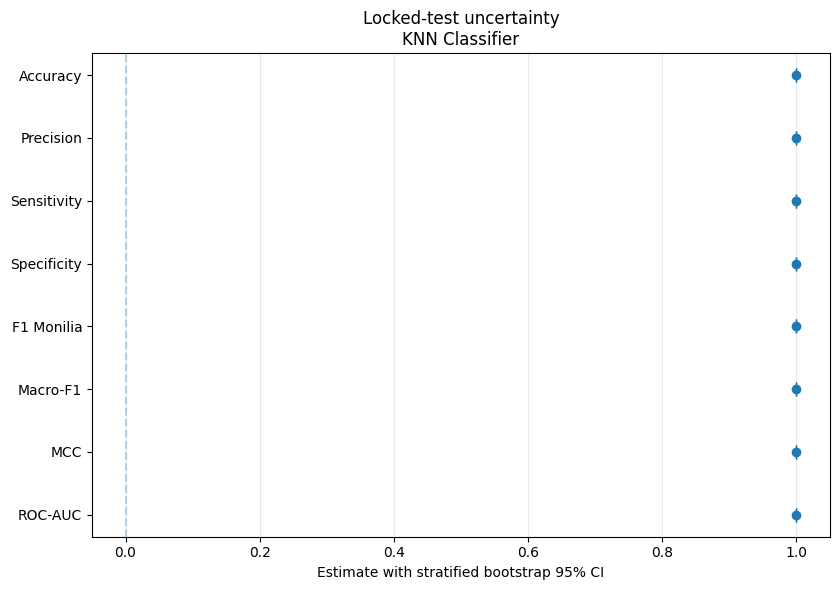


REPRESENTATION-LEVEL GRAD-CAM AUDIT
Selected downstream model: KNN Classifier
Grad-CAM model: /content/drive/MyDrive/Articulo_DiegoR/articulo/models/feature_extractors/mobilenetv2_segmented_final_finetuned.keras

NOTE: Grad-CAM below audits the shared MobileNetV2 representation, not the downstream model decision.
Backbone: mobilenetv2_1.00_224
Grad-CAM layer: out_relu
Conv output shape: (None, 7, 7, 1280)

GRAD-CAM REPRESENTATION ATTENTION SUMMARY


foreground_area_fraction                 attention_inside_cacao  \
                               mean  median     std                   mean   
class_name                                                                   
Healthy                      0.2277  0.2235  0.0363                 0.5407   
Monilia                      0.2269  0.2301  0.0305                 0.5258   

                           attention_enrichment                  
            median     std                 mean  median     std  
class_name                                                       
Healthy     0.5402  0.0646               2.3955  2.3998  0.2129  
Monilia     0.5244  0.0584               2.3288  2.3224  0.1531


Interpretation:
attention_inside_cacao = fraction of positive Grad-CAM activation located inside the segmented cacao.
attention_enrichment > 1 means Grad-CAM attention is more concentrated on cacao than expected from its relative image area.
These quantities audit the CNN representation and must not be described as a direct explanation of KNN Classifier.


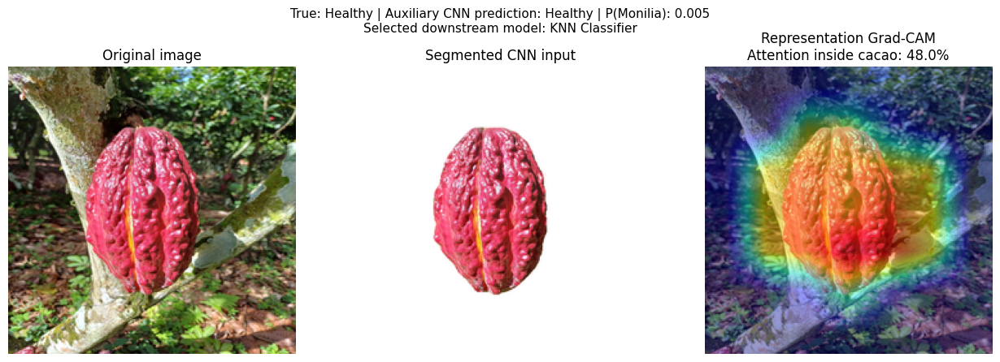

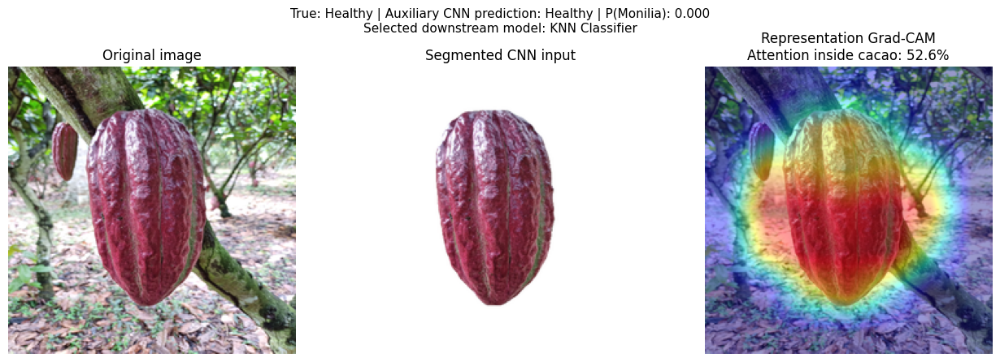

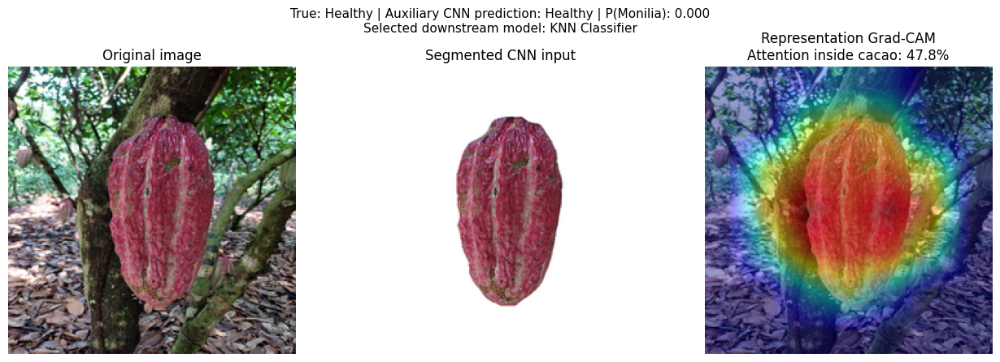

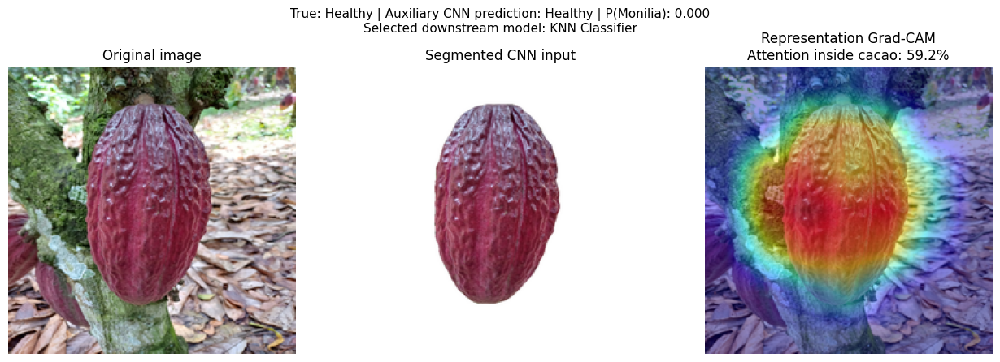

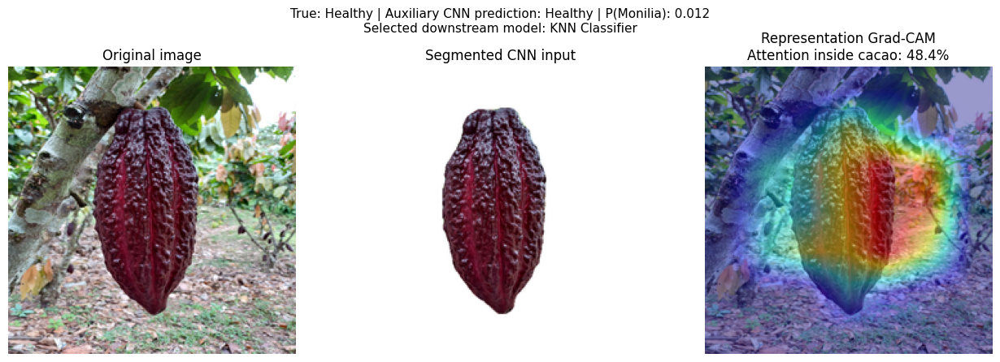

...

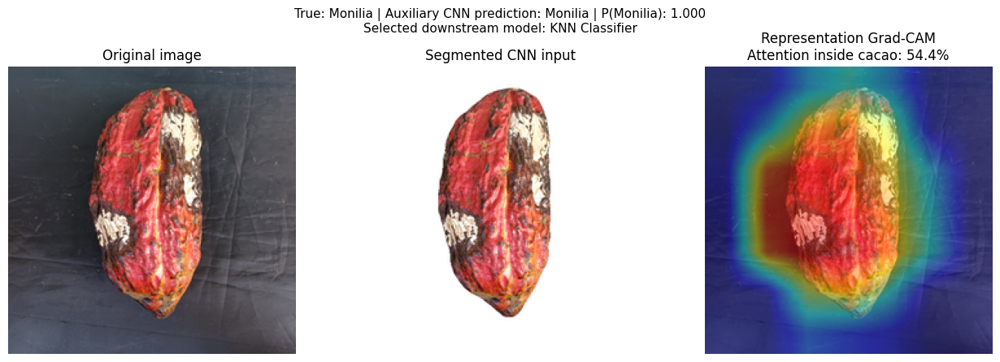

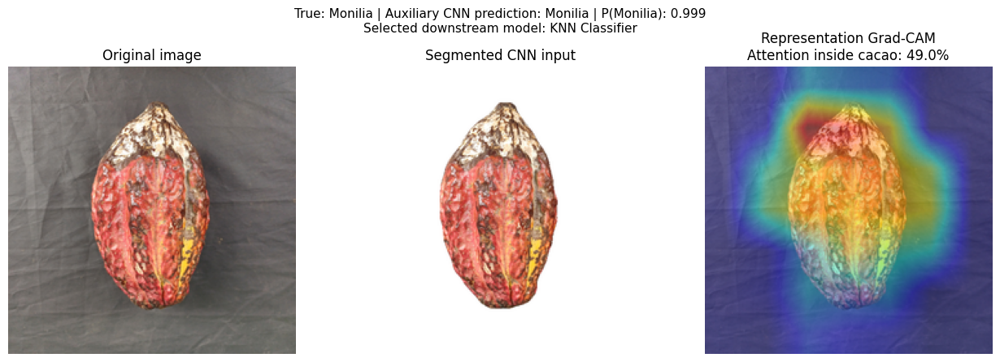

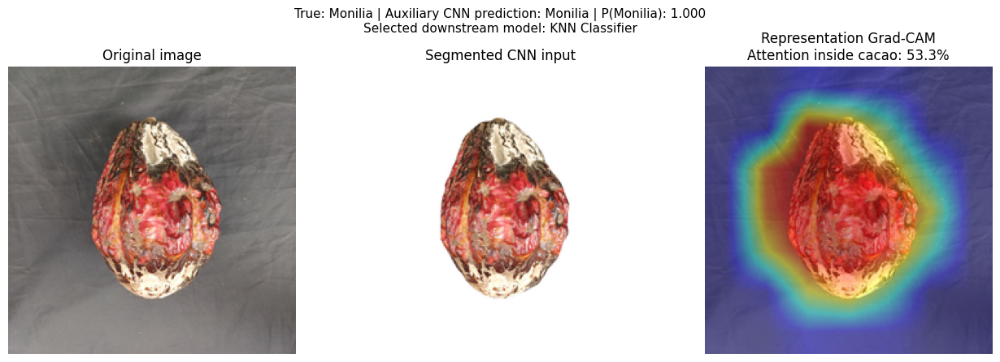

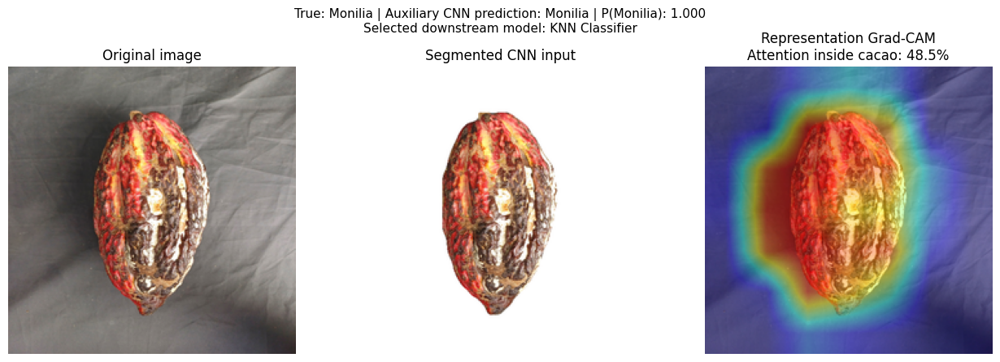

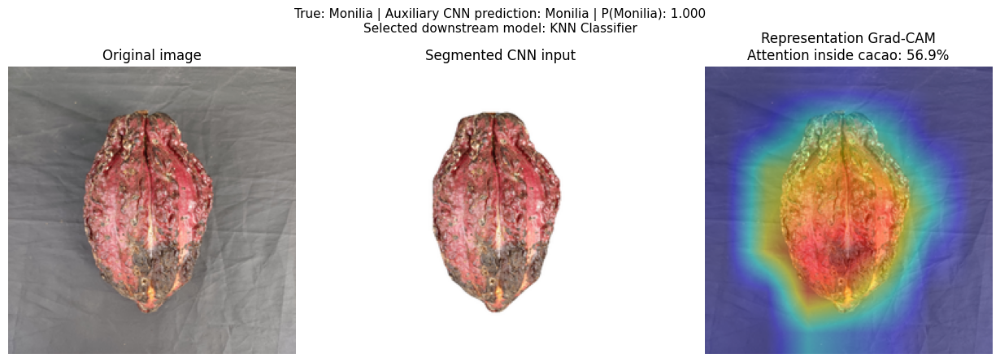


FINAL UNCERTAINTY + REPRESENTATION AUDIT COMPLETE

Selected final model:
KNN Classifier

Selection metadata:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/final_test_segmented/selected_model_from_cv.json

95% confidence intervals:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/final_test_segmented/uncertainty/segmented_knn_classifier_locked_test_95ci.csv

Uncertainty figures:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/final_test_segmented/uncertainty/figures

Grad-CAM quantitative audit:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/final_test_segmented/gradcam/gradcam_representation_attention_audit.csv

Grad-CAM examples:
/content/drive/MyDrive/Articulo_DiegoR/articulo/results/final_test_segmented/gradcam/examples

[OK] Locked-test uncertainty was computed only for the model selected from TRAIN-only cross-validation.
[OK] Grad-CAM was retained as a representation-level audit of the shared MobileNetV2 feature extractor.


In [ ]:
# ============================================================
# FINAL UNCERTAINTY + REPRESENTATION-LEVEL GRAD-CAM AUDIT
#
# AUTOMATICALLY ADAPTS TO THE MODEL SELECTED FROM 10-FOLD CV
#
# Candidate models:
#   Direct classification:
#       1. SVC
#       2. KNN Classifier
#       3. XGBClassifier
#
#   Regression + fixed HPO threshold:
#       4. SVR
#       5. KNN Regressor
#       6. XGBRegressor
#
# Part A:
#   - Select final model using TRAIN-only 10-fold CV results
#   - Load ONLY that model's locked-test predictions
#   - Stratified bootstrap 95% CI
#   - Exact Clopper-Pearson 95% CI
#   - Publication-ready uncertainty plots
#
# Part B:
#   - Representation-level Grad-CAM audit of the shared
#     fine-tuned segmented MobileNetV2 feature extractor
#   - Quantification of attention inside cacao foreground
#   - Publication-ready examples
#
# IMPORTANT:
# Grad-CAM audits the shared CNN representation.
# It does NOT directly explain the downstream SVC/KNN/XGBoost/
# SVR/KNN-Regressor/XGBRegressor decision rule.
# ============================================================

import os
import gc
import json

import numpy as np
import pandas as pd

import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

from PIL import Image, ImageOps
from IPython.display import display

from scipy.stats import beta

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
)

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

RANDOM_STATE = 42
BOOTSTRAP_ITERATIONS = 5000

IMG_SIZE = (
    224,
    224
)

CLASS_NAMES = {
    0: "Healthy",
    1: "Monilia"
}

TARGET_BRANCH = "segmented"

MODEL_LABELS = {
    "svc":
        "SVC",

    "knn_classifier":
        "KNN Classifier",

    "xgb_classifier":
        "XGBClassifier",

    "svr":
        "SVR",

    "knn_regressor":
        "KNN Regressor",

    "xgb_regressor":
        "XGBRegressor",
}

MODEL_APPROACH = {
    "svc":
        "Direct classification",

    "knn_classifier":
        "Direct classification",

    "xgb_classifier":
        "Direct classification",

    "svr":
        "Regression + threshold",

    "knn_regressor":
        "Regression + threshold",

    "xgb_regressor":
        "Regression + threshold",
}

rng = np.random.default_rng(
    RANDOM_STATE
)

print("=" * 80)
print("FINAL UNCERTAINTY + REPRESENTATION-LEVEL GRAD-CAM AUDIT")
print("=" * 80)


# ============================================================
# 2. PATHS
# ============================================================

ejecucion = (
    "/content/drive/MyDrive/"
    "Articulo_DiegoR/articulo"
)

features_directory = os.path.join(
    ejecucion,
    "features"
)

cv_directory = os.path.join(
    ejecucion,
    "results",
    "cross_validation_10fold_hybrid"
)

cv_summary_path = os.path.join(
    cv_directory,
    "cross_validation_summary.csv"
)

final_results_directory = os.path.join(
    ejecucion,
    "results",
    "final_test_segmented"
)

predictions_directory = os.path.join(
    final_results_directory,
    "predictions"
)

uncertainty_directory = os.path.join(
    final_results_directory,
    "uncertainty"
)

uncertainty_figures_directory = os.path.join(
    uncertainty_directory,
    "figures"
)

gradcam_directory = os.path.join(
    final_results_directory,
    "gradcam"
)

gradcam_examples_directory = os.path.join(
    gradcam_directory,
    "examples"
)

for directory in [
    uncertainty_directory,
    uncertainty_figures_directory,
    gradcam_directory,
    gradcam_examples_directory,
]:
    os.makedirs(
        directory,
        exist_ok=True
    )


# ============================================================
# 3. SELECT FINAL MODEL FROM CROSS-VALIDATION
#
# IMPORTANT:
# Selection is made before inspecting locked-test performance.
#
# Pre-specified selection rule:
#   1. Highest mean Macro-F1 across 10 folds
#   2. Highest mean MCC
#   3. Highest mean ROC-AUC
#   4. Deterministic model-name tie break
#
# This section reads TRAIN-only CV results.
# ============================================================

assert os.path.isfile(
    cv_summary_path
), (
    f"Cross-validation summary not found:\n"
    f"{cv_summary_path}"
)

cv_summary_df = pd.read_csv(
    cv_summary_path
)

required_cv_columns = {
    "branch",
    "approach",
    "model",
    "threshold",
    "f1_macro_mean",
    "mcc_mean",
    "roc_auc_mean",
}

missing_cv_columns = (
    required_cv_columns
    -
    set(
        cv_summary_df.columns
    )
)

assert not missing_cv_columns, (
    f"Missing CV columns: "
    f"{missing_cv_columns}"
)

candidate_df = (
    cv_summary_df[
        cv_summary_df[
            "branch"
        ]
        ==
        TARGET_BRANCH
    ]
    .copy()
)

assert len(
    candidate_df
) == 6, (
    f"Expected 6 models for branch "
    f"'{TARGET_BRANCH}', "
    f"found {len(candidate_df)}."
)

selected_row = (
    candidate_df
    .sort_values(
        by=[
            "f1_macro_mean",
            "mcc_mean",
            "roc_auc_mean",
            "model",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ],
        kind="mergesort"
    )
    .iloc[0]
)

SELECTED_MODEL = str(
    selected_row[
        "model"
    ]
)

SELECTED_APPROACH = str(
    selected_row[
        "approach"
    ]
)

SELECTED_THRESHOLD = (
    None
    if pd.isna(
        selected_row[
            "threshold"
        ]
    )
    else float(
        selected_row[
            "threshold"
        ]
    )
)

assert SELECTED_MODEL in MODEL_LABELS, (
    f"Unsupported selected model: "
    f"{SELECTED_MODEL}"
)

selection_record = {
    "selection_source":
        "10-fold cross-validation on training set",

    "branch":
        TARGET_BRANCH,

    "model":
        SELECTED_MODEL,

    "model_label":
        MODEL_LABELS[
            SELECTED_MODEL
        ],

    "approach":
        SELECTED_APPROACH,

    "decision_threshold":
        SELECTED_THRESHOLD,

    "selection_rule":
        (
            "Highest f1_macro_mean; "
            "tie breakers: mcc_mean, "
            "roc_auc_mean, model name"
        ),

    "cv_f1_macro_mean":
        float(
            selected_row[
                "f1_macro_mean"
            ]
        ),

    "cv_f1_macro_sd":
        float(
            selected_row[
                "f1_macro_sd"
            ]
        ),

    "cv_mcc_mean":
        float(
            selected_row[
                "mcc_mean"
            ]
        ),

    "cv_roc_auc_mean":
        float(
            selected_row[
                "roc_auc_mean"
            ]
        ),
}

selection_path = os.path.join(
    final_results_directory,
    "selected_model_from_cv.json"
)

with open(
    selection_path,
    "w"
) as f:
    json.dump(
        selection_record,
        f,
        indent=4
    )

print(
    "\nSELECTED FINAL MODEL"
)

print(
    "Model     :",
    MODEL_LABELS[
        SELECTED_MODEL
    ]
)

print(
    "Approach  :",
    SELECTED_APPROACH
)

print(
    "CV F1     :",
    f"{selected_row['f1_macro_mean']:.4f} "
    f"± {selected_row['f1_macro_sd']:.4f}"
)

if SELECTED_THRESHOLD is not None:
    print(
        "Threshold :",
        f"{SELECTED_THRESHOLD:.4f}"
    )

print(
    "\n[OK] Final model was selected from CV results, "
    "before reading its locked-test performance."
)


# ============================================================
# 4. LOCATE LOCKED-TEST PREDICTION FILE
#
# Preferred naming:
#   segmented_<model>_locked_test_predictions.csv
#
# Backward-compatible aliases are also checked.
# ============================================================

PREDICTION_ALIASES = {
    "svc": [
        "svc",
    ],

    "knn_classifier": [
        "knn_classifier",
        "knn",
    ],

    "xgb_classifier": [
        "xgb_classifier",
        "xgboost",
    ],

    "svr": [
        "svr",
    ],

    "knn_regressor": [
        "knn_regressor",
    ],

    "xgb_regressor": [
        "xgb_regressor",
    ],
}


def locate_prediction_file(
    branch_name,
    model_name
):
    candidate_paths = []

    for alias in PREDICTION_ALIASES[
        model_name
    ]:
        candidate_paths.append(
            os.path.join(
                predictions_directory,
                (
                    f"{branch_name}_"
                    f"{alias}_"
                    f"locked_test_predictions.csv"
                )
            )
        )

    candidate_paths.append(
        os.path.join(
            predictions_directory,
            "selected_model_locked_test_predictions.csv"
        )
    )

    for path in candidate_paths:
        if os.path.isfile(
            path
        ):
            return path

    raise FileNotFoundError(
        "No locked-test prediction file was found "
        "for the selected model.\nChecked:\n"
        +
        "\n".join(
            candidate_paths
        )
    )


prediction_path = locate_prediction_file(
    TARGET_BRANCH,
    SELECTED_MODEL
)

print(
    "\nLocked-test predictions:"
)

print(
    prediction_path
)


# ============================================================
# PART A
# UNCERTAINTY FOR THE SELECTED FINAL MODEL ONLY
# ============================================================


# ============================================================
# 5. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred,
    y_score
):
    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred,
            labels=[
                0,
                1
            ]
        )
        .ravel()
    )

    specificity = (
        tn / (
            tn + fp
        )
        if (
            tn + fp
        ) > 0
        else np.nan
    )

    return {
        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "sensitivity":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "specificity":
            specificity,

        "f1_monilia":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "f1_macro":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_score
            ),
    }


# ============================================================
# 6. STRATIFIED BOOTSTRAP
#
# Resampling is performed separately within each class.
# ============================================================

def stratified_bootstrap_ci(
    y_true,
    y_pred,
    y_score,
    n_iterations=BOOTSTRAP_ITERATIONS,
    random_state=RANDOM_STATE
):
    local_rng = np.random.default_rng(
        random_state
    )

    healthy_idx = np.flatnonzero(
        y_true == 0
    )

    monilia_idx = np.flatnonzero(
        y_true == 1
    )

    metric_names = [
        "accuracy",
        "precision",
        "sensitivity",
        "specificity",
        "f1_monilia",
        "f1_macro",
        "mcc",
        "roc_auc",
    ]

    bootstrap_values = {
        metric: []
        for metric in metric_names
    }

    for _ in range(
        n_iterations
    ):
        sampled_healthy = (
            local_rng.choice(
                healthy_idx,
                size=len(
                    healthy_idx
                ),
                replace=True
            )
        )

        sampled_monilia = (
            local_rng.choice(
                monilia_idx,
                size=len(
                    monilia_idx
                ),
                replace=True
            )
        )

        bootstrap_idx = np.concatenate(
            [
                sampled_healthy,
                sampled_monilia,
            ]
        )

        local_rng.shuffle(
            bootstrap_idx
        )

        y_true_b = y_true[
            bootstrap_idx
        ]

        y_pred_b = y_pred[
            bootstrap_idx
        ]

        y_score_b = y_score[
            bootstrap_idx
        ]

        metrics_b = calculate_metrics(
            y_true_b,
            y_pred_b,
            y_score_b
        )

        for metric in metric_names:
            bootstrap_values[
                metric
            ].append(
                metrics_b[
                    metric
                ]
            )

    ci = {}

    for metric in metric_names:
        values = np.asarray(
            bootstrap_values[
                metric
            ],
            dtype=float
        )

        ci[
            metric
        ] = {
            "lower":
                float(
                    np.percentile(
                        values,
                        2.5
                    )
                ),

            "upper":
                float(
                    np.percentile(
                        values,
                        97.5
                    )
                ),

            "bootstrap_mean":
                float(
                    np.mean(
                        values
                    )
                ),
        }

    return ci


# ============================================================
# 7. EXACT CLOPPER-PEARSON INTERVAL
# ============================================================

def clopper_pearson_interval(
    successes,
    total,
    alpha=0.05
):
    if total == 0:
        return (
            np.nan,
            np.nan
        )

    if successes == 0:
        lower = 0.0
    else:
        lower = beta.ppf(
            alpha / 2,
            successes,
            total - successes + 1
        )

    if successes == total:
        upper = 1.0
    else:
        upper = beta.ppf(
            1 - alpha / 2,
            successes + 1,
            total - successes
        )

    return (
        float(
            lower
        ),
        float(
            upper
        )
    )


# ============================================================
# 8. LOAD SELECTED MODEL TEST PREDICTIONS
# ============================================================

prediction_df = pd.read_csv(
    prediction_path
)

required_prediction_columns = {
    "y_true",
    "y_pred",
}

missing_prediction_columns = (
    required_prediction_columns
    -
    set(
        prediction_df.columns
    )
)

assert not missing_prediction_columns, (
    f"Missing prediction columns: "
    f"{missing_prediction_columns}"
)

score_column = None

for candidate_score_column in [
    "score_monilia",
    "score",
    "y_score",
]:
    if candidate_score_column in (
        prediction_df.columns
    ):
        score_column = (
            candidate_score_column
        )
        break

assert score_column is not None, (
    "No continuous score column found. "
    "Expected one of: "
    "score_monilia, score, y_score."
)

y_true = (
    prediction_df[
        "y_true"
    ]
    .astype(int)
    .to_numpy()
)

y_pred = (
    prediction_df[
        "y_pred"
    ]
    .astype(int)
    .to_numpy()
)

y_score = (
    prediction_df[
        score_column
    ]
    .astype(float)
    .to_numpy()
)

assert len(
    y_true
) == 168, (
    f"Expected 168 locked-test samples, "
    f"found {len(y_true)}."
)

assert set(
    np.unique(
        y_true
    )
).issubset(
    {
        0,
        1
    }
)

assert set(
    np.unique(
        y_pred
    )
).issubset(
    {
        0,
        1
    }
)


# ============================================================
# 9. COMPUTE UNCERTAINTY
# ============================================================

point_metrics = calculate_metrics(
    y_true,
    y_pred,
    y_score
)

bootstrap_ci = stratified_bootstrap_ci(
    y_true,
    y_pred,
    y_score
)

tn, fp, fn, tp = (
    confusion_matrix(
        y_true,
        y_pred,
        labels=[
            0,
            1
        ]
    )
    .ravel()
)

accuracy_exact = (
    clopper_pearson_interval(
        int(
            np.sum(
                y_true
                ==
                y_pred
            )
        ),
        len(
            y_true
        )
    )
)

sensitivity_exact = (
    clopper_pearson_interval(
        int(
            tp
        ),
        int(
            tp + fn
        )
    )
)

specificity_exact = (
    clopper_pearson_interval(
        int(
            tn
        ),
        int(
            tn + fp
        )
    )
)

precision_exact = (
    clopper_pearson_interval(
        int(
            tp
        ),
        int(
            tp + fp
        )
    )
)

exact_intervals = {
    "accuracy":
        accuracy_exact,

    "precision":
        precision_exact,

    "sensitivity":
        sensitivity_exact,

    "specificity":
        specificity_exact,
}

uncertainty_records = []

for metric_name, value in (
    point_metrics.items()
):
    record = {
        "branch":
            TARGET_BRANCH,

        "model":
            SELECTED_MODEL,

        "model_label":
            MODEL_LABELS[
                SELECTED_MODEL
            ],

        "approach":
            SELECTED_APPROACH,

        "decision_threshold":
            SELECTED_THRESHOLD,

        "metric":
            metric_name,

        "estimate":
            float(
                value
            ),

        "bootstrap_ci_lower":
            bootstrap_ci[
                metric_name
            ][
                "lower"
            ],

        "bootstrap_ci_upper":
            bootstrap_ci[
                metric_name
            ][
                "upper"
            ],

        "bootstrap_mean":
            bootstrap_ci[
                metric_name
            ][
                "bootstrap_mean"
            ],

        "bootstrap_iterations":
            BOOTSTRAP_ITERATIONS,

        "exact_ci_lower":
            np.nan,

        "exact_ci_upper":
            np.nan,
    }

    if metric_name in (
        exact_intervals
    ):
        record[
            "exact_ci_lower"
        ] = (
            exact_intervals[
                metric_name
            ][0]
        )

        record[
            "exact_ci_upper"
        ] = (
            exact_intervals[
                metric_name
            ][1]
        )

    uncertainty_records.append(
        record
    )

uncertainty_df = pd.DataFrame(
    uncertainty_records
)

uncertainty_path = os.path.join(
    uncertainty_directory,
    (
        f"{TARGET_BRANCH}_"
        f"{SELECTED_MODEL}_"
        f"locked_test_95ci.csv"
    )
)

uncertainty_df.to_csv(
    uncertainty_path,
    index=False
)

print(
    "\n"
    + "=" * 80
)

print(
    "95% CONFIDENCE INTERVALS"
)

print(
    f"Selected model: "
    f"{MODEL_LABELS[SELECTED_MODEL]}"
)

print(
    "=" * 80
)

display(
    uncertainty_df[
        [
            "metric",
            "estimate",
            "bootstrap_ci_lower",
            "bootstrap_ci_upper",
            "exact_ci_lower",
            "exact_ci_upper",
        ]
    ].round(4)
)


# ============================================================
# 10. VISUALIZATION - TEST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)

fig, ax = plt.subplots(
    figsize=(5.8, 5.0)
)

image = ax.imshow(
    cm,
    cmap="Blues"
)

max_value = cm.max()

for row_index in range(2):
    for column_index in range(2):
        value = cm[
            row_index,
            column_index
        ]

        text_color = (
            "white"
            if value > max_value / 2
            else "black"
        )

        ax.text(
            column_index,
            row_index,
            str(value),
            ha="center",
            va="center",
            fontsize=15,
            fontweight="bold",
            color=text_color
        )

ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)

ax.set_xticklabels(
    [
        "Healthy",
        "Monilia",
    ]
)

ax.set_yticklabels(
    [
        "Healthy",
        "Monilia",
    ]
)

ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

title = (
    "Locked-test confusion matrix\n"
    f"Segmented MobileNetV2 + "
    f"{MODEL_LABELS[SELECTED_MODEL]}"
)

if SELECTED_THRESHOLD is not None:
    title += (
        f"\nThreshold = "
        f"{SELECTED_THRESHOLD:.2f}"
    )

ax.set_title(
    title
)

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

fig.tight_layout()

test_cm_path = os.path.join(
    uncertainty_figures_directory,
    (
        f"locked_test_confusion_"
        f"{SELECTED_MODEL}.png"
    )
)

fig.savefig(
    test_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. VISUALIZATION - BOOTSTRAP 95% CI FOREST PLOT
# ============================================================

forest_df = uncertainty_df[
    uncertainty_df[
        "metric"
    ].isin(
        [
            "accuracy",
            "precision",
            "sensitivity",
            "specificity",
            "f1_monilia",
            "f1_macro",
            "mcc",
            "roc_auc",
        ]
    )
].copy()

metric_labels = {
    "accuracy":
        "Accuracy",

    "precision":
        "Precision",

    "sensitivity":
        "Sensitivity",

    "specificity":
        "Specificity",

    "f1_monilia":
        "F1 Monilia",

    "f1_macro":
        "Macro-F1",

    "mcc":
        "MCC",

    "roc_auc":
        "ROC-AUC",
}

forest_df[
    "metric_label"
] = forest_df[
    "metric"
].map(
    metric_labels
)

forest_df = forest_df.iloc[
    ::-1
].reset_index(
    drop=True
)

y_positions = np.arange(
    len(
        forest_df
    )
)

estimates = forest_df[
    "estimate"
].to_numpy()

lower = forest_df[
    "bootstrap_ci_lower"
].to_numpy()

upper = forest_df[
    "bootstrap_ci_upper"
].to_numpy()

xerr = np.vstack(
    [
        estimates - lower,
        upper - estimates,
    ]
)

fig, ax = plt.subplots(
    figsize=(8.5, 6)
)

ax.errorbar(
    estimates,
    y_positions,
    xerr=xerr,
    fmt="o",
    capsize=5
)

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    forest_df[
        "metric_label"
    ]
)

ax.set_xlabel(
    "Estimate with stratified bootstrap 95% CI"
)

ax.set_title(
    (
        "Locked-test uncertainty\n"
        f"{MODEL_LABELS[SELECTED_MODEL]}"
    )
)

ax.axvline(
    0.0,
    linestyle="--",
    alpha=0.3
)

ax.grid(
    axis="x",
    alpha=0.25
)

fig.tight_layout()

forest_path = os.path.join(
    uncertainty_figures_directory,
    (
        f"bootstrap_95ci_"
        f"{SELECTED_MODEL}.png"
    )
)

fig.savefig(
    forest_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PART B
# REPRESENTATION-LEVEL GRAD-CAM AUDIT
#
# IMPORTANT:
# The following analysis explains the shared fine-tuned
# segmented MobileNetV2 representation, NOT the downstream
# winner's final decision rule.
# ============================================================


# ============================================================
# 12. LOAD FINAL SEGMENTED CNN
# ============================================================

cnn_model_path = os.path.join(
    ejecucion,
    "models",
    "feature_extractors",
    "mobilenetv2_segmented_final_finetuned.keras"
)

assert os.path.isfile(
    cnn_model_path
)

tf.keras.backend.clear_session()
gc.collect()

cnn_model = tf.keras.models.load_model(
    cnn_model_path,
    compile=False
)

print(
    "\n"
    + "=" * 80
)

print(
    "REPRESENTATION-LEVEL GRAD-CAM AUDIT"
)

print(
    "=" * 80
)

print(
    "Selected downstream model:",
    MODEL_LABELS[
        SELECTED_MODEL
    ]
)

print(
    "Grad-CAM model:",
    cnn_model_path
)

print(
    "\nNOTE: Grad-CAM below audits the shared "
    "MobileNetV2 representation, not the "
    "downstream model decision."
)


# ============================================================
# 13. LOCATE MOBILENETV2 BACKBONE
# ============================================================

backbone = None

for layer in cnn_model.layers:
    if (
        isinstance(
            layer,
            tf.keras.Model
        )
        and
        "mobilenet" in
        layer.name.lower()
    ):
        backbone = layer
        break

assert backbone is not None, (
    "MobileNetV2 backbone could not be located."
)

print(
    "Backbone:",
    backbone.name
)


# ============================================================
# 14. LAST CONVOLUTIONAL LAYER
# ============================================================

LAST_CONV_LAYER = (
    "out_relu"
)

last_conv_layer = (
    backbone.get_layer(
        LAST_CONV_LAYER
    )
)

conv_model = tf.keras.Model(
    inputs=
        backbone.input,

    outputs=
        last_conv_layer.output
)

print(
    "Grad-CAM layer:",
    LAST_CONV_LAYER
)

print(
    "Conv output shape:",
    conv_model.output_shape
)


# ============================================================
# 15. CNN HEAD LAYERS
# ============================================================

deep_features_layer = (
    cnn_model.get_layer(
        "deep_features"
    )
)

classification_dense = (
    cnn_model.get_layer(
        "classification_dense"
    )
)

classification_dropout = (
    cnn_model.get_layer(
        "classification_dropout"
    )
)

classification_output = (
    cnn_model.get_layer(
        "classification_output"
    )
)


# ============================================================
# 16. IMAGE LOADING
# ============================================================

def load_rgb_image(
    image_path
):
    with Image.open(
        image_path
    ) as image:
        image = (
            ImageOps
            .exif_transpose(
                image
            )
        )

        image = image.convert(
            "RGB"
        )

        image = image.resize(
            IMG_SIZE,
            Image.Resampling.LANCZOS
        )

        image_array = np.asarray(
            image,
            dtype=np.float32
        )

    return image_array


# ============================================================
# 17. GRAD-CAM FUNCTION
#
# This targets the auxiliary CNN's own predicted class.
# It is used to audit spatial representation quality.
# ============================================================

def make_gradcam(
    segmented_image_path
):
    image_rgb = load_rgb_image(
        segmented_image_path
    )

    preprocessed = preprocess_input(
        image_rgb.copy()
    )

    input_tensor = tf.convert_to_tensor(
        preprocessed[
            np.newaxis,
            ...
        ],
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(
            input_tensor,
            training=False
        )

        tape.watch(
            conv_outputs
        )

        pooled_features = tf.reduce_mean(
            conv_outputs,
            axis=(
                1,
                2
            )
        )

        deep_features = (
            deep_features_layer(
                pooled_features
            )
        )

        x = classification_dense(
            deep_features
        )

        x = classification_dropout(
            x,
            training=False
        )

        logits = (
            tf.matmul(
                x,
                classification_output.kernel
            )
            +
            classification_output.bias
        )

        probability = tf.sigmoid(
            logits
        )[0, 0]

        predicted_class = tf.cast(
            probability >= 0.5,
            tf.int32
        )

        target_score = tf.cond(
            predicted_class == 1,

            lambda:
                logits[
                    0,
                    0
                ],

            lambda:
                -logits[
                    0,
                    0
                ]
        )

    gradients = tape.gradient(
        target_score,
        conv_outputs
    )

    channel_weights = tf.reduce_mean(
        gradients,
        axis=(
            1,
            2
        )
    )[0]

    conv_outputs = (
        conv_outputs[
            0
        ]
    )

    heatmap = tf.reduce_sum(
        conv_outputs
        *
        channel_weights,
        axis=-1
    )

    heatmap = tf.nn.relu(
        heatmap
    )

    heatmap_max = tf.reduce_max(
        heatmap
    )

    if float(
        heatmap_max
    ) > 0:
        heatmap = (
            heatmap
            /
            heatmap_max
        )

    heatmap = heatmap.numpy()

    return (
        image_rgb.astype(
            np.uint8
        ),
        heatmap,
        int(
            predicted_class.numpy()
        ),
        float(
            probability.numpy()
        )
    )


# ============================================================
# 18. LOAD TEST MANIFEST
# ============================================================

feature_manifest_path = os.path.join(
    features_directory,
    "feature_manifest.csv"
)

feature_manifest = pd.read_csv(
    feature_manifest_path
)

test_manifest = (
    feature_manifest[
        feature_manifest[
            "split_norm"
        ].astype(str)
        ==
        "test"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

assert len(
    test_manifest
) == 168


# ============================================================
# 19. GRAD-CAM AUDIT FOR ALL 168 TEST IMAGES
# ============================================================

gradcam_records = []

for idx, row in test_manifest.iterrows():
    segmented_path = str(
        row[
            "segmented_path"
        ]
    )

    (
        segmented_rgb,
        heatmap,
        auxiliary_prediction,
        auxiliary_probability
    ) = make_gradcam(
        segmented_path
    )

    heatmap_resized = cv2.resize(
        heatmap,
        IMG_SIZE,
        interpolation=
            cv2.INTER_LINEAR
    )

    cacao_mask = np.any(
        segmented_rgb < 250,
        axis=-1
    )

    foreground_fraction = float(
        np.mean(
            cacao_mask
        )
    )

    total_attention = float(
        np.sum(
            heatmap_resized
        )
    )

    if total_attention > 0:
        attention_inside = float(
            np.sum(
                heatmap_resized[
                    cacao_mask
                ]
            )
            /
            total_attention
        )
    else:
        attention_inside = np.nan

    if (
        foreground_fraction > 0
        and
        np.isfinite(
            attention_inside
        )
    ):
        attention_enrichment = (
            attention_inside
            /
            foreground_fraction
        )
    else:
        attention_enrichment = np.nan

    gradcam_records.append(
        {
            "filename":
                row[
                    "filename"
                ],

            "class_name":
                row[
                    "class_name"
                ],

            "label":
                int(
                    row[
                        "label"
                    ]
                ),

            "selected_downstream_model":
                SELECTED_MODEL,

            "selected_downstream_model_label":
                MODEL_LABELS[
                    SELECTED_MODEL
                ],

            "auxiliary_cnn_prediction":
                auxiliary_prediction,

            "auxiliary_cnn_probability_monilia":
                auxiliary_probability,

            "foreground_area_fraction":
                foreground_fraction,

            "attention_inside_cacao":
                attention_inside,

            "attention_enrichment":
                attention_enrichment,
        }
    )

gradcam_audit_df = pd.DataFrame(
    gradcam_records
)

gradcam_audit_path = os.path.join(
    gradcam_directory,
    "gradcam_representation_attention_audit.csv"
)

gradcam_audit_df.to_csv(
    gradcam_audit_path,
    index=False
)


# ============================================================
# 20. GRAD-CAM QUANTITATIVE SUMMARY
# ============================================================

gradcam_summary = (
    gradcam_audit_df
    .groupby(
        "class_name"
    )[
        [
            "foreground_area_fraction",
            "attention_inside_cacao",
            "attention_enrichment",
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std",
        ]
    )
)

print(
    "\n"
    + "=" * 80
)

print(
    "GRAD-CAM REPRESENTATION ATTENTION SUMMARY"
)

print(
    "=" * 80
)

display(
    gradcam_summary.round(4)
)

print(
    "\nInterpretation:"
)

print(
    "attention_inside_cacao = fraction of positive Grad-CAM "
    "activation located inside the segmented cacao."
)

print(
    "attention_enrichment > 1 means Grad-CAM attention is "
    "more concentrated on cacao than expected from its "
    "relative image area."
)

print(
    "These quantities audit the CNN representation and "
    "must not be described as a direct explanation of "
    f"{MODEL_LABELS[SELECTED_MODEL]}."
)


# ============================================================
# 21. SELECT BALANCED EXAMPLES
#
# 6 Healthy + 6 Monilia
# ============================================================

example_indices = []

for class_label in [
    0,
    1
]:
    class_indices = test_manifest.index[
        test_manifest[
            "label"
        ].astype(int)
        ==
        class_label
    ].to_numpy()

    selected = rng.choice(
        class_indices,
        size=6,
        replace=False
    )

    example_indices.extend(
        selected.tolist()
    )


# ============================================================
# 22. GRAD-CAM VISUALIZATION
#
# Three panels:
#   Original image
#   Segmented CNN input
#   Grad-CAM over original image
# ============================================================

for idx in example_indices:
    row = test_manifest.loc[
        idx
    ]

    original_path = str(
        row[
            "original_path"
        ]
    )

    segmented_path = str(
        row[
            "segmented_path"
        ]
    )

    original_rgb = load_rgb_image(
        original_path
    ).astype(
        np.uint8
    )

    (
        segmented_rgb,
        heatmap,
        predicted_class,
        probability
    ) = make_gradcam(
        segmented_path
    )

    heatmap_resized = cv2.resize(
        heatmap,
        IMG_SIZE,
        interpolation=
            cv2.INTER_LINEAR
    )

    heatmap_uint8 = np.uint8(
        255
        *
        heatmap_resized
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        original_rgb,
        0.60,
        heatmap_color,
        0.40,
        0
    )

    audit_row = gradcam_audit_df[
        gradcam_audit_df[
            "filename"
        ]
        ==
        row[
            "filename"
        ]
    ].iloc[0]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(
            13,
            4.5
        )
    )

    axes[
        0
    ].imshow(
        original_rgb
    )

    axes[
        0
    ].set_title(
        "Original image"
    )

    axes[
        0
    ].axis(
        "off"
    )

    axes[
        1
    ].imshow(
        segmented_rgb
    )

    axes[
        1
    ].set_title(
        "Segmented CNN input"
    )

    axes[
        1
    ].axis(
        "off"
    )

    axes[
        2
    ].imshow(
        overlay
    )

    axes[
        2
    ].set_title(
        (
            "Representation Grad-CAM\n"
            f"Attention inside cacao: "
            f"{audit_row['attention_inside_cacao']:.1%}"
        )
    )

    axes[
        2
    ].axis(
        "off"
    )

    fig.suptitle(
        (
            f"True: "
            f"{row['class_name']} | "
            f"Auxiliary CNN prediction: "
            f"{CLASS_NAMES[predicted_class]} | "
            f"P(Monilia): "
            f"{probability:.3f}\n"
            f"Selected downstream model: "
            f"{MODEL_LABELS[SELECTED_MODEL]}"
        ),
        fontsize=11
    )

    plt.tight_layout()

    output_path = os.path.join(
        gradcam_examples_directory,
        (
            f"gradcam_"
            f"{os.path.splitext(str(row['filename']))[0]}"
            f".png"
        )
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 23. FINAL OUTPUT
# ============================================================

print(
    "\n"
    + "=" * 80
)

print(
    "FINAL UNCERTAINTY + REPRESENTATION AUDIT COMPLETE"
)

print(
    "=" * 80
)

print(
    "\nSelected final model:"
)

print(
    MODEL_LABELS[
        SELECTED_MODEL
    ]
)

print(
    "\nSelection metadata:"
)

print(
    selection_path
)

print(
    "\n95% confidence intervals:"
)

print(
    uncertainty_path
)

print(
    "\nUncertainty figures:"
)

print(
    uncertainty_figures_directory
)

print(
    "\nGrad-CAM quantitative audit:"
)

print(
    gradcam_audit_path
)

print(
    "\nGrad-CAM examples:"
)

print(
    gradcam_examples_directory
)

print(
    "\n[OK] Locked-test uncertainty was computed only for "
    "the model selected from TRAIN-only cross-validation."
)

print(
    "[OK] Grad-CAM was retained as a representation-level "
    "audit of the shared MobileNetV2 feature extractor."
)


# **Resumen**

El estudio desarrolló y evaluó un enfoque híbrido para diferenciar frutos de cacao sanos y afectados por moniliasis mediante segmentación de imágenes, aprendizaje profundo y algoritmos de clasificación directa y regresión con umbralización. El conjunto inicial estuvo conformado por 2,184 imágenes, a partir de las cuales se seleccionaron 842 correspondientes a frutos sanos y 842 con moniliasis, obteniéndose un conjunto balanceado de 1,684 imágenes. Estas se distribuyeron de manera independiente en cuatro subconjuntos: 168 imágenes para el ajuste fino de los extractores profundos, 1,180 para el entrenamiento y la validación cruzada, 168 para la optimización de hiperparámetros y selección de umbrales, y 168 para una prueba final independiente mantenida bloqueada durante todo el proceso de selección. Debido a que las fotografías originales presentaban diferencias en sus condiciones de captura y heterogeneidad en el fondo, se analizaron tanto imágenes originales como segmentadas; sin embargo, la representación segmentada se consideró la principal para la comparación final, con el propósito de reducir la influencia de información externa al fruto.

La segmentación se realizó mediante un modelo YOLO previamente entrenado, conservando la región correspondiente al cacao y sustituyendo el fondo por un entorno uniforme. Posteriormente, se empleó una arquitectura MobileNetV2 preentrenada en ImageNet y ajustada al problema Healthy–Monilia, utilizándose finalmente como extractor de representaciones profundas de 1,280 características. Sobre estas características se estudiaron dos estrategias: clasificación directa mediante SVC, KNN Classifier y XGBClassifier, y regresión con posterior umbralización mediante SVR, KNN Regressor y XGBRegressor. De esta manera, la comparación comprendió seis modelos para cada representación de entrada. Los hiperparámetros y, en el caso de los regresores, los umbrales de decisión fueron seleccionados utilizando exclusivamente el conjunto HPO. Para la representación segmentada se obtuvo un SVC lineal con C = 0.1; un KNN Classifier con k = 3 vecinos, distancia euclidiana y ponderación uniforme; y un SVR lineal con C = 1.0, ε = 0.05 y un umbral de 0.43. El KNN Regressor utilizó k = 3 vecinos, distancia Manhattan, ponderación uniforme y un umbral de 0.33, mientras que XGBRegressor empleó un umbral de 0.49. Los umbrales seleccionados permanecieron fijos durante las etapas posteriores de evaluación.

La estabilidad de los modelos se examinó mediante validación cruzada estratificada de 10 folds sobre las 1,180 imágenes de entrenamiento, utilizando exactamente las mismas particiones para todos los algoritmos. En la representación segmentada, KNN Classifier alcanzó el mayor F1-macro medio, con 0.9966 ± 0.0044, seguido de SVC con 0.9958 ± 0.0072, SVR con 0.9941 ± 0.0057, XGBClassifier con 0.9932 ± 0.0067, XGBRegressor con 0.9924 ± 0.0084 y KNN Regressor con 0.9915 ± 0.0089. Los valores medios de MCC fueron 0.9933, 0.9915, 0.9882, 0.9866, 0.9849 y 0.9832, respectivamente. Asimismo, todos los modelos presentaron áreas bajo la curva ROC elevadas, comprendidas entre 0.9982 y 0.9999. De forma descriptiva, los modelos de clasificación directa alcanzaron un F1-macro promedio global de 0.9952, frente a 0.9927 para los modelos de regresión con umbralización, aunque esta diferencia fue pequeña.

La comparación estadística de los seis modelos mediante la prueba de Friedman no identificó diferencias significativas en el F1-macro de los diez folds (χ² = 4.4344, p = 0.4887), con un tamaño de efecto pequeño según Kendall (W = 0.0887). Los rangos promedio situaron a KNN Classifier en primer lugar con 2.8, seguido de SVC con 3.1, XGBClassifier y SVR con 3.7, XGBRegressor con 3.8 y KNN Regressor con 3.9. Las quince comparaciones pareadas mediante Wilcoxon con corrección de Holm tampoco mostraron diferencias estadísticamente significativas entre los modelos. Del mismo modo, los análisis secundarios basados en accuracy, MCC y ROC-AUC no evidenciaron diferencias significativas. Por tanto, aunque la clasificación directa presentó valores medios ligeramente superiores, los resultados no permiten afirmar una superioridad estadística de este enfoque frente a la regresión con umbralización.

Una vez completada la optimización y la validación cruzada, la selección del modelo final se realizó exclusivamente con los resultados obtenidos sobre los datos de desarrollo, antes de consultar el conjunto de prueba bloqueado. De acuerdo con el criterio preestablecido de mayor F1-macro medio, seguido de MCC y ROC-AUC como criterios de desempate, KNN Classifier fue seleccionado como modelo final, con un F1-macro de 0.9966 ± 0.0044 en validación cruzada. Posteriormente, el modelo se evaluó una única vez sobre las 168 imágenes del conjunto de prueba independiente, integrado por 84 frutos sanos y 84 con moniliasis. Se obtuvieron 168 clasificaciones correctas de 168 posibles, alcanzándose valores de 1.000 para accuracy, precisión, sensibilidad, especificidad, F1-macro, MCC y ROC-AUC. Estos resultados deben interpretarse considerando el tamaño del conjunto de prueba y no como evidencia de rendimiento poblacional perfecto.

Para cuantificar la incertidumbre del rendimiento final se realizaron 5,000 iteraciones de bootstrap estratificado y se calcularon adicionalmente intervalos exactos de Clopper–Pearson para las métricas basadas en proporciones. Debido a que no se registraron errores de clasificación, los intervalos bootstrap fueron 1.000–1.000. En contraste, el intervalo exacto del 95 % para accuracy fue 0.9783–1.0000, mientras que los correspondientes a precisión, sensibilidad y especificidad fueron 0.9570–1.0000. Estos intervalos muestran que, aun cuando el desempeño observado en la muestra de prueba fue perfecto, existe incertidumbre asociada al tamaño muestral, por lo que el valor puntual de 1.000 no debe extrapolarse directamente a nuevas poblaciones o condiciones de adquisición.

Finalmente, se realizó una auditoría de la representación profunda mediante Grad-CAM sobre la MobileNetV2 ajustada que sirvió como base para la extracción de características. Este análisis debe interpretarse como una evaluación de la representación espacial aprendida por la red convolucional y no como una explicación directa de las decisiones del KNN Classifier seleccionado posteriormente. En las imágenes sanas, el fruto ocupó en promedio el 22.77 % del área de la imagen y concentró aproximadamente el 54.07 % de la activación positiva, con un enriquecimiento medio de atención de 2.40. En las imágenes con moniliasis, el fruto representó aproximadamente el 22.69 % del área, concentró el 52.58 % de la activación y presentó un enriquecimiento medio de 2.33. Estos resultados indican que la representación generada por MobileNetV2 concentra más del doble de atención sobre la región del cacao de lo que se esperaría únicamente por su proporción espacial. La inspección visual de los mapas Grad-CAM confirmó que las activaciones principales se localizaron predominantemente sobre el fruto, sin depender de artefactos del fondo.


# Descarga del modelo ganador

In [ ]:
# ============================================================
# BUILD DEPLOYMENT PACKAGE FROM THE AUTOMATIC CV WINNER
#
# The package contains everything needed for inference:
#
# Image
#   ↓
# YOLO cacao segmentation
#   ↓
# Segmented image
#   ↓
# MobileNetV2 1280-D feature extractor
#   ↓
# Final downstream winner
#   ↓
# Healthy / Monilia
#
# Works with:
#   SVC
#   KNN Classifier
#   XGBClassifier
#   SVR
#   KNN Regressor
#   XGBRegressor
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import json
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import joblib

import sklearn
import tensorflow as tf
import xgboost

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import (
    SVC,
    SVR
)

from sklearn.neighbors import (
    KNeighborsClassifier,
    KNeighborsRegressor
)

from xgboost import (
    XGBClassifier,
    XGBRegressor
)


# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

RANDOM_STATE = 42

TARGET_BRANCH = "segmented"

CLASS_NAMES = {
    0: "Healthy",
    1: "Monilia"
}

IMG_SIZE = [
    224,
    224
]

FEATURE_DIMENSION = 1280


# ============================================================
# 2. PROJECT PATHS
# ============================================================

ejecucion = (
    "/content/drive/MyDrive/"
    "Articulo_DiegoR/articulo"
)

features_directory = os.path.join(
    ejecucion,
    "features"
)

hpo_directory = os.path.join(
    ejecucion,
    "results",
    "hybrid_hpo"
)

cv_directory = os.path.join(
    ejecucion,
    "results",
    "cross_validation_10fold_hybrid"
)

cv_summary_path = os.path.join(
    cv_directory,
    "cross_validation_summary.csv"
)


# ------------------------------------------------------------
# YOLO segmenter
# ------------------------------------------------------------

yolo_source_path = os.path.join(
    ejecucion,
    "Segmentador_Cacao_YOLO26n_best.pt"
)


# ------------------------------------------------------------
# MobileNetV2 segmented feature extractor
# ------------------------------------------------------------

extractor_source_path = os.path.join(
    ejecucion,
    "models",
    "feature_extractors",
    "mobilenetv2_segmented_final_extractor.keras"
)


# ============================================================
# 3. OUTPUT PACKAGE
# ============================================================

package_root = os.path.join(
    ejecucion,
    "deployment",
    "CacaoMonilia_System"
)

models_output = os.path.join(
    package_root,
    "models"
)

config_output = os.path.join(
    package_root,
    "config"
)

os.makedirs(
    models_output,
    exist_ok=True
)

os.makedirs(
    config_output,
    exist_ok=True
)


# ============================================================
# 4. VERIFY REQUIRED FILES
# ============================================================

required_files = [
    cv_summary_path,
    yolo_source_path,
    extractor_source_path,

    os.path.join(
        features_directory,
        "X_segmented_train.npy"
    ),

    os.path.join(
        features_directory,
        "X_segmented_hpo.npy"
    ),

    os.path.join(
        features_directory,
        "y_train.npy"
    ),

    os.path.join(
        features_directory,
        "y_hpo.npy"
    ),
]

for path in required_files:

    assert os.path.isfile(path), (
        f"Required file not found:\n{path}"
    )

print(
    "[OK] Required source files found."
)


# ============================================================
# 5. AUTOMATICALLY SELECT WINNER FROM TRAIN-ONLY CV
#
# Primary:
#   highest mean Macro-F1
#
# Tie breakers:
#   MCC
#   ROC-AUC
# ============================================================

cv_df = pd.read_csv(
    cv_summary_path
)

segmented_cv = (
    cv_df[
        cv_df["branch"]
        ==
        TARGET_BRANCH
    ]
    .copy()
)


winner_row = (
    segmented_cv
    .sort_values(
        by=[
            "f1_macro_mean",
            "mcc_mean",
            "roc_auc_mean",
            "model"
        ],
        ascending=[
            False,
            False,
            False,
            True
        ],
        kind="mergesort"
    )
    .iloc[0]
)


winner_name = str(
    winner_row["model"]
)

winner_approach = str(
    winner_row["approach"]
)


winner_threshold = (

    None

    if pd.isna(
        winner_row["threshold"]
    )

    else float(
        winner_row["threshold"]
    )
)


print(
    "\n"
    + "=" * 80
)

print(
    "AUTOMATIC WINNER"
)

print(
    "=" * 80
)

print(
    "Model:",
    winner_name
)

print(
    "Approach:",
    winner_approach
)

print(
    "CV Macro-F1:",
    winner_row["f1_macro_mean"]
)

print(
    "CV MCC:",
    winner_row["mcc_mean"]
)

print(
    "CV ROC-AUC:",
    winner_row["roc_auc_mean"]
)

if winner_threshold is not None:

    print(
        "Threshold:",
        winner_threshold
    )


# ============================================================
# 6. LOAD WINNER HPO CONFIGURATION
# ============================================================

winner_hpo_path = os.path.join(
    hpo_directory,
    (
        f"best_"
        f"{TARGET_BRANCH}_"
        f"{winner_name}.json"
    )
)


assert os.path.isfile(
    winner_hpo_path
), (
    f"Winner HPO configuration not found:\n"
    f"{winner_hpo_path}"
)


with open(
    winner_hpo_path,
    "r"
) as file:

    winner_hpo = json.load(
        file
    )


best_params = winner_hpo[
    "best_params"
]


# Prefer the threshold stored in HPO metadata.
if (
    winner_hpo.get(
        "decision_threshold"
    )
    is not None
):

    winner_threshold = float(
        winner_hpo[
            "decision_threshold"
        ]
    )


print(
    "\nBest parameters:"
)

print(
    best_params
)


# ============================================================
# 7. GENERIC MODEL BUILDER
# ============================================================

def build_model(
    model_name,
    params
):

    if model_name == "svc":

        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "model",
                    SVC(
                        **params
                    )
                )
            ]
        )


    elif model_name == "knn_classifier":

        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "model",
                    KNeighborsClassifier(
                        **params,
                        n_jobs=-1
                    )
                )
            ]
        )


    elif model_name == "xgb_classifier":

        return XGBClassifier(

            **params,

            objective=
                "binary:logistic",

            eval_metric=
                "logloss",

            tree_method=
                "hist",

            random_state=
                RANDOM_STATE,

            n_jobs=-1,

            verbosity=0
        )


    elif model_name == "svr":

        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "model",
                    SVR(
                        **params
                    )
                )
            ]
        )


    elif model_name == "knn_regressor":

        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "model",
                    KNeighborsRegressor(
                        **params,
                        n_jobs=-1
                    )
                )
            ]
        )


    elif model_name == "xgb_regressor":

        return XGBRegressor(

            **params,

            objective=
                "reg:squarederror",

            eval_metric=
                "rmse",

            tree_method=
                "hist",

            random_state=
                RANDOM_STATE,

            n_jobs=-1,

            verbosity=0
        )


    else:

        raise ValueError(
            f"Unsupported winner: "
            f"{model_name}"
        )


# ============================================================
# 8. LOAD TRAIN + HPO FEATURES
#
# Final production model:
#   1180 train
#   +
#   168 HPO
#   =
#   1348 development images
#
# Locked test is NOT included in final fitting.
# ============================================================

X_train = np.load(
    os.path.join(
        features_directory,
        "X_segmented_train.npy"
    )
)

X_hpo = np.load(
    os.path.join(
        features_directory,
        "X_segmented_hpo.npy"
    )
)

y_train = np.load(
    os.path.join(
        features_directory,
        "y_train.npy"
    )
)

y_hpo = np.load(
    os.path.join(
        features_directory,
        "y_hpo.npy"
    )
)


X_development = np.concatenate(
    [
        X_train,
        X_hpo
    ],
    axis=0
)


y_development = np.concatenate(
    [
        y_train,
        y_hpo
    ],
    axis=0
)


assert X_development.shape == (
    1348,
    1280
)

assert y_development.shape == (
    1348,
)


print(
    "\nDevelopment matrix:",
    X_development.shape
)


# ============================================================
# 9. TRAIN FINAL PRODUCTION WINNER
# ============================================================

final_model = build_model(
    winner_name,
    best_params
)


final_model.fit(
    X_development,
    y_development
)


print(
    "\n[OK] Final winner fitted "
    "using TRAIN + HPO."
)


# ============================================================
# 10. SAVE DOWNSTREAM MODEL
# ============================================================

downstream_model_path = os.path.join(
    models_output,
    "final_downstream_model.joblib"
)


joblib.dump(
    final_model,
    downstream_model_path
)


print(
    "[OK] Downstream model saved:"
)

print(
    downstream_model_path
)


# ============================================================
# 11. COPY YOLO + MOBILENETV2
# ============================================================

yolo_output_path = os.path.join(
    models_output,
    "cacao_yolo_segmenter.pt"
)


extractor_output_path = os.path.join(
    models_output,
    "mobilenetv2_feature_extractor.keras"
)


shutil.copy2(
    yolo_source_path,
    yolo_output_path
)


shutil.copy2(
    extractor_source_path,
    extractor_output_path
)


print(
    "[OK] YOLO model copied."
)

print(
    "[OK] MobileNetV2 extractor copied."
)


# ============================================================
# 12. SAVE MODEL METADATA
# ============================================================

metadata = {

    "system_name":
        "Cacao Monilia Classification System",

    "task":
        "Binary image classification",

    "classes":
        CLASS_NAMES,

    "positive_class":
        "Monilia",

    "pipeline": [
        "YOLO segmentation",
        "MobileNetV2 deep feature extraction",
        winner_name
    ],

    "selected_branch":
        TARGET_BRANCH,

    "winner_model":
        winner_name,

    "winner_approach":
        winner_approach,

    "best_params":
        best_params,

    "decision_threshold":
        winner_threshold,

    "feature_extractor":
        "MobileNetV2",

    "feature_dimension":
        FEATURE_DIMENSION,

    "image_size":
        IMG_SIZE,

    "mobilenet_preprocessing":
        "tensorflow.keras.applications.mobilenet_v2.preprocess_input",

    "segmentation": {

        "model":
            "YOLO",

        "imgsz":
            640,

        "confidence_sequence": [
            0.25,
            0.15,
            0.10,
            0.05
        ],

        "mask_threshold":
            0.5,

        "background":
            "white"
    },

    "training": {

        "train_samples":
            1180,

        "hpo_samples":
            168,

        "final_fit_samples":
            1348,

        "locked_test_used_for_training":
            False
    },

    "cv_selection": {

        "f1_macro_mean":
            float(
                winner_row[
                    "f1_macro_mean"
                ]
            ),

        "f1_macro_sd":
            float(
                winner_row[
                    "f1_macro_sd"
                ]
            ),

        "mcc_mean":
            float(
                winner_row[
                    "mcc_mean"
                ]
            ),

        "roc_auc_mean":
            float(
                winner_row[
                    "roc_auc_mean"
                ]
            )
    },

    "versions": {

        "python":
            sys.version,

        "tensorflow":
            tf.__version__,

        "scikit_learn":
            sklearn.__version__,

        "xgboost":
            xgboost.__version__
    }
}


metadata_path = os.path.join(
    config_output,
    "model_metadata.json"
)


with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metadata,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "[OK] Metadata saved."
)


# ============================================================
# 13. CREATE INFERENCE.PY
# ============================================================

inference_code = r'''
import os
import json

import cv2
import joblib
import numpy as np
import tensorflow as tf

from PIL import (
    Image,
    ImageOps
)

from ultralytics import YOLO

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input
)


BASE_DIR = os.path.dirname(
    os.path.abspath(
        __file__
    )
)


MODEL_DIR = os.path.join(
    BASE_DIR,
    "models"
)


CONFIG_DIR = os.path.join(
    BASE_DIR,
    "config"
)


with open(
    os.path.join(
        CONFIG_DIR,
        "model_metadata.json"
    ),
    "r",
    encoding="utf-8"
) as file:

    METADATA = json.load(
        file
    )


YOLO_MODEL = YOLO(
    os.path.join(
        MODEL_DIR,
        "cacao_yolo_segmenter.pt"
    )
)


FEATURE_EXTRACTOR = (
    tf.keras.models.load_model(
        os.path.join(
            MODEL_DIR,
            "mobilenetv2_feature_extractor.keras"
        ),
        compile=False
    )
)


DOWNSTREAM_MODEL = joblib.load(
    os.path.join(
        MODEL_DIR,
        "final_downstream_model.joblib"
    )
)


CLASS_NAMES = {
    0: "Healthy",
    1: "Monilia"
}


IMG_SIZE = (
    224,
    224
)


# ============================================================
# IMAGE LOADING
# ============================================================

def load_rgb_image(
    image_path
):

    with Image.open(
        image_path
    ) as image:

        image = (
            ImageOps
            .exif_transpose(
                image
            )
        )

        image = image.convert(
            "RGB"
        )

        image_array = np.asarray(
            image
        )

    return image_array


# ============================================================
# YOLO SEGMENTATION
# ============================================================

def segment_cacao(
    image_rgb
):

    height, width = (
        image_rgb.shape[:2]
    )


    confidence_sequence = (
        METADATA[
            "segmentation"
        ][
            "confidence_sequence"
        ]
    )


    for confidence in (
        confidence_sequence
    ):

        results = YOLO_MODEL.predict(

            source=
                image_rgb,

            conf=
                float(
                    confidence
                ),

            imgsz=
                640,

            verbose=
                False
        )


        result = results[0]


        if (
            result.masks is None
            or
            len(
                result.masks.data
            ) == 0
        ):

            continue


        masks = (
            result.masks.data
            .detach()
            .cpu()
            .numpy()
        )


        combined_mask = np.zeros(
            (
                height,
                width
            ),
            dtype=np.uint8
        )


        for mask in masks:

            if mask.shape != (
                height,
                width
            ):

                mask = cv2.resize(

                    mask,

                    (
                        width,
                        height
                    ),

                    interpolation=
                        cv2.INTER_NEAREST
                )


            binary_mask = (
                mask >= 0.5
            ).astype(
                np.uint8
            )


            combined_mask = (
                np.maximum(
                    combined_mask,
                    binary_mask
                )
            )


        segmented = np.full_like(
            image_rgb,
            255
        )


        segmented[
            combined_mask == 1
        ] = image_rgb[
            combined_mask == 1
        ]


        segmented = np.asarray(

            Image.fromarray(
                segmented
            ).resize(
                IMG_SIZE,
                Image.Resampling.LANCZOS
            )
        )


        return (
            segmented,
            float(
                confidence
            )
        )


    raise RuntimeError(
        "No cacao fruit was detected "
        "by the segmentation model."
    )


# ============================================================
# DEEP FEATURE EXTRACTION
# ============================================================

def extract_features(
    segmented_rgb
):

    image = segmented_rgb.astype(
        np.float32
    )


    image = preprocess_input(
        image
    )


    batch = np.expand_dims(
        image,
        axis=0
    )


    features = FEATURE_EXTRACTOR(
        batch,
        training=False
    )


    features = np.asarray(
        features
    )


    assert features.shape == (
        1,
        1280
    )


    return features


# ============================================================
# FINAL PREDICTION
# ============================================================

def predict_image(
    image_path
):

    image_rgb = load_rgb_image(
        image_path
    )


    segmented_rgb, confidence = (
        segment_cacao(
            image_rgb
        )
    )


    features = extract_features(
        segmented_rgb
    )


    approach = METADATA[
        "winner_approach"
    ]


    # --------------------------------------------------------
    # Direct classification
    # --------------------------------------------------------

    if approach == "classification":

        predicted_class = int(

            DOWNSTREAM_MODEL.predict(
                features
            )[0]
        )


        if hasattr(
            DOWNSTREAM_MODEL,
            "predict_proba"
        ):

            probabilities = (
                DOWNSTREAM_MODEL
                .predict_proba(
                    features
                )
            )


            score = float(
                probabilities[
                    0,
                    1
                ]
            )


            score_type = (
                "class_probability_like"
            )


        elif hasattr(
            DOWNSTREAM_MODEL,
            "decision_function"
        ):

            score = float(

                DOWNSTREAM_MODEL
                .decision_function(
                    features
                )[0]
            )


            score_type = (
                "decision_function"
            )


        else:

            score = None

            score_type = None


    # --------------------------------------------------------
    # Regression + threshold
    # --------------------------------------------------------

    elif approach == (
        "regression_threshold"
    ):

        score = float(

            DOWNSTREAM_MODEL.predict(
                features
            )[0]
        )


        threshold = float(
            METADATA[
                "decision_threshold"
            ]
        )


        predicted_class = int(
            score >= threshold
        )


        score_type = (
            "raw_regression_output"
        )


    else:

        raise ValueError(
            f"Unknown approach: "
            f"{approach}"
        )


    return {

        "predicted_class":
            predicted_class,

        "predicted_label":
            CLASS_NAMES[
                predicted_class
            ],

        "score":
            score,

        "score_type":
            score_type,

        "segmentation_confidence":
            confidence,

        "winner_model":
            METADATA[
                "winner_model"
            ]
    }


# ============================================================
# COMMAND-LINE USAGE
#
# python inference.py image.jpg
# ============================================================

if __name__ == "__main__":

    import sys


    if len(
        sys.argv
    ) != 2:

        print(
            "Usage:"
        )

        print(
            "python inference.py "
            "path_to_image.jpg"
        )

        sys.exit(
            1
        )


    image_path = sys.argv[1]


    result = predict_image(
        image_path
    )


    print(
        json.dumps(
            result,
            indent=4,
            ensure_ascii=False
        )
    )
'''


inference_path = os.path.join(
    package_root,
    "inference.py"
)


with open(
    inference_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        inference_code
    )


print(
    "[OK] inference.py created."
)


# ============================================================
# 14. REQUIREMENTS.TXT
# ============================================================

requirements = """
numpy
pandas
Pillow
opencv-python
tensorflow
scikit-learn
joblib
xgboost
ultralytics
"""


requirements_path = os.path.join(
    package_root,
    "requirements.txt"
)


with open(
    requirements_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        requirements.strip()
        +
        "\n"
    )


# ============================================================
# 15. README
# ============================================================

readme = f"""
CACAO MONILIA SYSTEM
====================

Selected model:
{winner_name}

Approach:
{winner_approach}

Pipeline:
Image
 -> YOLO segmentation
 -> MobileNetV2 feature extraction
 -> {winner_name}
 -> Healthy / Monilia

Input:
RGB image containing a cacao fruit.

Classes:
0 = Healthy
1 = Monilia

Image size used by feature extractor:
224 x 224

Deep feature dimension:
1280

Installation:
pip install -r requirements.txt

Inference:
python inference.py image.jpg

Python usage:

from inference import predict_image

result = predict_image("image.jpg")

print(result)

IMPORTANT:
The regression output, when a regressor is selected,
must not be interpreted automatically as a probability.

The downstream model was trained on TRAIN + HPO only.
The locked test was not incorporated into model training.
"""


readme_path = os.path.join(
    package_root,
    "README.txt"
)


with open(
    readme_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        readme
    )


# ============================================================
# 16. PACKAGE VERIFICATION SCRIPT
# ============================================================

verify_code = r'''
import os
import json
import joblib
import tensorflow as tf

BASE = os.path.dirname(
    os.path.abspath(
        __file__
    )
)

required = [
    "models/cacao_yolo_segmenter.pt",
    "models/mobilenetv2_feature_extractor.keras",
    "models/final_downstream_model.joblib",
    "config/model_metadata.json",
    "inference.py",
    "requirements.txt",
    "README.txt"
]

for relative_path in required:

    absolute_path = os.path.join(
        BASE,
        relative_path
    )

    assert os.path.isfile(
        absolute_path
    ), (
        f"Missing: "
        f"{relative_path}"
    )

print(
    "[OK] All required files exist."
)


extractor = (
    tf.keras.models.load_model(

        os.path.join(
            BASE,
            "models",
            "mobilenetv2_feature_extractor.keras"
        ),

        compile=False
    )
)


assert extractor.output_shape[
    -1
] == 1280


model = joblib.load(

    os.path.join(
        BASE,
        "models",
        "final_downstream_model.joblib"
    )
)


with open(

    os.path.join(
        BASE,
        "config",
        "model_metadata.json"
    ),

    "r",
    encoding="utf-8"

) as file:

    metadata = json.load(
        file
    )


print(
    "[OK] MobileNetV2 extractor loaded."
)

print(
    "[OK] Downstream model loaded."
)

print(
    "Winner:",
    metadata[
        "winner_model"
    ]
)

print(
    "\n[OK] Deployment package is valid."
)
'''


verify_path = os.path.join(
    package_root,
    "verify_package.py"
)


with open(
    verify_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        verify_code
    )


# ============================================================
# 17. VERIFY PACKAGE CONTENT
# ============================================================

expected_package_files = [

    os.path.join(
        models_output,
        "cacao_yolo_segmenter.pt"
    ),

    os.path.join(
        models_output,
        "mobilenetv2_feature_extractor.keras"
    ),

    downstream_model_path,

    metadata_path,

    inference_path,

    requirements_path,

    readme_path,

    verify_path
]


for path in expected_package_files:

    assert os.path.isfile(
        path
    ), (
        f"Missing deployment file:\n"
        f"{path}"
    )


print(
    "\n"
    + "=" * 80
)

print(
    "DEPLOYMENT PACKAGE READY"
)

print(
    "=" * 80
)


for root, dirs, files in os.walk(
    package_root
):

    level = (
        root
        .replace(
            package_root,
            ""
        )
        .count(
            os.sep
        )
    )


    indent = (
        "    "
        *
        level
    )


    print(
        f"{indent}"
        f"{os.path.basename(root)}/"
    )


    subindent = (
        "    "
        *
        (
            level + 1
        )
    )


    for filename in files:

        print(
            f"{subindent}"
            f"{filename}"
        )


# ============================================================
# 18. CREATE ZIP ALWAYS
# ============================================================

archive_base = os.path.join(
    ejecucion,
    "deployment",
    "CacaoMonilia_System"
)


zip_path = shutil.make_archive(

    archive_base,

    "zip",

    root_dir=
        os.path.dirname(
            package_root
        ),

    base_dir=
        os.path.basename(
            package_root
        )
)


print(
    "\n[OK] ZIP created:"
)

print(
    zip_path
)


# ============================================================
# 19. CREATE RAR IF 'rar' EXECUTABLE IS AVAILABLE
# ============================================================

rar_executable = shutil.which(
    "rar"
)


if rar_executable is not None:

    rar_path = (
        archive_base
        +
        ".rar"
    )


    if os.path.isfile(
        rar_path
    ):

        os.remove(
            rar_path
        )


    subprocess.run(

        [
            rar_executable,

            "a",

            "-r",

            rar_path,

            package_root
        ],

        check=True
    )


    print(
        "\n[OK] RAR created:"
    )

    print(
        rar_path
    )


else:

    print(
        "\n[NOTE] The 'rar' executable "
        "is not installed in this Colab runtime."
    )

    print(
        "The complete package was created "
        "as ZIP instead."
    )

    print(
        "Nothing is missing from the ZIP; "
        "RAR and ZIP are only container formats."
    )


print(
    "\n"
    + "=" * 80
)

print(
    "DONE"
)

print(
    "=" * 80
)

print(
    "Winner:",
    winner_name
)

print(
    "Package folder:",
    package_root
)

print(
    "ZIP:",
    zip_path
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] Required source files found.

AUTOMATIC WINNER
Model: knn_classifier
Approach: classification
CV Macro-F1: 0.9966099260216909
CV MCC: 0.99327683210007
CV ROC-AUC: 0.9991238149956908

Best parameters:
{'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}

Development matrix: (1348, 1280)

[OK] Final winner fitted using TRAIN + HPO.
[OK] Downstream model saved:
/content/drive/MyDrive/Articulo_DiegoR/articulo/deployment/CacaoMonilia_System/models/final_downstream_model.joblib
[OK] YOLO model copied.
[OK] MobileNetV2 extractor copied.
[OK] Metadata saved.
[OK] inference.py created.

DEPLOYMENT PACKAGE READY
CacaoMonilia_System/
    inference.py
    requirements.txt
    README.txt
    verify_package.py
    models/
        final_downstream_model.joblib
        cacao_yolo_segmenter.pt
        mobilenetv2_feature_extractor.keras
    config/
        model_metadata.jso